# Adaptive-FDHGNN-APPNP + VIL + Dynamic Pruning — Pipeline

In [ ]:
!pip -q install numpy pandas scikit-learn torch networkx matplotlib seaborn scipy

## Setup: Imports & Configuration

In [ ]:
# ============================================================
# Adaptive-FDHGNN-APPNP + VIL + Dynamic Pruning
# Corrected end-to-end pipeline following the 13-step protocol
# ============================================================

import os, zipfile, time, warnings, copy
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (accuracy_score, f1_score, matthews_corrcoef,
                              recall_score, precision_score, confusion_matrix,
                              balanced_accuracy_score, roc_auc_score, roc_curve,
                              precision_recall_curve, auc)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)  # seed every CUDA device's generator too

# ============================================================
# Make results match on CPU and GPU
# ============================================================
# Two GPU-only defaults cause the code to behave differently on CPU vs GPU
# even with the same seed:
#  1. TF32 - on Ampere+ GPUs, PyTorch silently runs float32 matmuls (and
#     cuDNN convs) at reduced ~10-bit mantissa precision for speed. CPU
#     always uses full float32, so GPU numbers drift from CPU numbers from
#     the very first matmul.
#  2. cuDNN autotuning/nondeterminism - by default cuDNN may pick a faster
#     but non-deterministic algorithm, and results can vary GPU-run to
#     GPU-run, not just GPU-vs-CPU.
# This matters extra here because the FD-HGNN differential regularizer
# (Eq. 5) is numerically sensitive (see earlier fix) - tiny precision
# differences early in training can tip it into a different trajectory.
# Forcing full precision + deterministic kernels makes CPU and GPU runs
# reproduce the same result.
torch.backends.cuda.matmul.allow_tf32 = False
torch.backends.cudnn.allow_tf32 = False
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')
try:
    torch.use_deterministic_algorithms(True)
except Exception as _e:
    print(f"Warning: could not enable fully deterministic algorithms ({_e}); "
          f"CPU/GPU results may still differ slightly.")

# ============================================================
# Force CPU so CPU and GPU runs give the SAME output
# ============================================================
# There is no PyTorch setting that makes GPU matmul reduction bit-identical
# to CPU: GPU sums values in parallel across threads (order varies), CPU
# BLAS sums sequentially. TF32-off + deterministic-algorithms (above) only
# guarantee the SAME device reproduces the SAME result every run - they
# do not make two different devices agree with each other. On a small
# validation split (~40-65 rows here), even a single borderline sample
# flipping its predicted class from that last-bit difference shifts
# accuracy by ~1/N (2-3 percentage points), and because Dynamic Channel
# Pruning turns a close attention score into a hard prune/keep decision,
# that tiny difference can fork the whole rest of training onto a
# different architecture. The only way to *guarantee* identical numbers
# on CPU and GPU is to run both on the same device. Set FORCE_CPU=0 (env
# var) if you want to allow GPU for speed and accept that results may then
# differ slightly from a CPU run.
FORCE_CPU = bool(int(os.environ.get('FORCE_CPU', '1')))
if FORCE_CPU:
    device = torch.device('cpu')
else:
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device, "(forced CPU for reproducibility)" if FORCE_CPU else "")

# FAST_TEST=True shrinks epochs / folds / grid for a quick sanity run.
# Set FAST_TEST=False for the full, paper-quality run.
FAST_TEST = bool(int(os.environ.get('FAST_TEST', '0')))

# ============================================================
# Kaggle-ready output path
# ============================================================
# Every downstream cell writes to a relative 'figures/...' path (plots,
# CSVs). On Kaggle only /kaggle/working is writable (/kaggle/input is
# read-only), and only files under /kaggle/working are saved/downloadable
# after the session ends. Rather than editing every 'figures/...' call
# individually, we chdir into /kaggle/working once here so every relative
# path used later resolves correctly. Outside Kaggle this is a no-op and
# the notebook behaves exactly as before (writes to ./figures).
if os.path.isdir('/kaggle/working'):
    os.chdir('/kaggle/working')
OUTPUT_DIR = os.path.join(os.getcwd(), 'figures')
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Working directory:", os.getcwd())
print("Output directory :", OUTPUT_DIR)

Using device: cpu (forced CPU for reproducibility)
Working directory: /kaggle/working
Output directory : /kaggle/working/figures


##  (Step 1): (Load Full Dataset)

In [ ]:
# ============================================================
# STEP 1: Load Full Dataset  (Kaggle-ready)
# ============================================================
print("\n" + "=" * 70)
print("STEP 1: LOADING FULL DATASET")
print("=" * 70)

_search_roots = [
    '/kaggle/input/student-performance',
    '/kaggle/input',
    '/content',
    '.',
    '/mat/data',
]

_zip_path = None
_csv_path = None
for _root in _search_roots:
    if not os.path.isdir(_root):
        continue
    for _dirpath, _dirnames, _filenames in os.walk(_root):
        for _fn in _filenames:
            _fl = _fn.lower()
            if _csv_path is None and _fl == 'student-mat.csv':
                _csv_path = os.path.join(_dirpath, _fn)
            if _zip_path is None and _fl.endswith('.zip') and 'student' in _fl:
                _zip_path = os.path.join(_dirpath, _fn)
        if _csv_path is not None:
            break
    if _csv_path is not None:
        break

if _csv_path is not None:
    # Kaggle datasets are usually already extracted -> load the CSV directly.
    print(f"Found student-mat.csv directly at: {_csv_path}")
    df = pd.read_csv(_csv_path, sep=';')
elif _zip_path is not None:
    # Fallback: a zip (e.g. the raw UCI 'student+performance.zip' or an
    # inner 'student.zip') was found instead -> extract it in-place.
    print(f"Found zip archive at: {_zip_path}")
    _extract_dir = os.path.dirname(_zip_path) or '.'
    with zipfile.ZipFile(_zip_path, 'r') as z:
        _names = z.namelist()
        if 'student-mat.csv' in _names:
            df = pd.read_csv(z.open('student-mat.csv'), sep=';')
        elif 'student.zip' in _names:
            z.extract('student.zip', _extract_dir)
            with zipfile.ZipFile(os.path.join(_extract_dir, 'student.zip'), 'r') as z2:
                df = pd.read_csv(z2.open('student-mat.csv'), sep=';')
        else:
            raise FileNotFoundError(
                f"'{_zip_path}' does not contain student-mat.csv or student.zip. "
                f"Contents: {_names}"
            )
else:
    raise FileNotFoundError(
        "Could not find student-mat.csv (or a zip containing it) under any of: "
        + ", ".join(_search_roots) +
        ". On Kaggle, check the exact dataset mount path in the notebook's "
        "'Input' panel (usually /kaggle/input/<dataset-slug>/...) and add it "
        "to _search_roots above if it isn't already covered."
    )

print(f"Raw dataset shape: {df.shape}")
print(f"Columns ({len(df.columns)}): {list(df.columns)}")



STEP 1: LOADING FULL DATASET
Found student-mat.csv directly at: /kaggle/input/datasets/jannatmiftahul/student-performance/student/student-mat.csv
Raw dataset shape: (395, 33)
Columns (33): ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


##  (Step 2): Data Preprocessing — cleaning, duplicates, missing values, encoding (scaling deferred to Step 5 to avoid leakage)

In [ ]:
# ============================================================
# STEP 2: Data Preprocessing
# (cleaning, missing-value handling, duplicate removal,
#  feature preparation. Scaling is deferred to STEP 5 so that
#  the scaler is fit only on the augmented TRAIN set -> no leakage)
# ============================================================
print("\n" + "=" * 70)
print("STEP 2: DATA PREPROCESSING")
print("=" * 70)

n_before = len(df)
n_dupes = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicate rows removed: {n_dupes} (rows: {n_before} -> {len(df)})")

n_missing = df.isnull().sum().sum()
print(f"Missing values found: {n_missing}")
if n_missing > 0:
    num_cols_all = df.select_dtypes(include=[np.number]).columns
    cat_cols_all = df.select_dtypes(include=['object']).columns
    for c in num_cols_all:
        if df[c].isnull().any():
            df[c] = df[c].fillna(df[c].median())
    for c in cat_cols_all:
        if df[c].isnull().any():
            df[c] = df[c].fillna(df[c].mode().iloc[0])
    print("Missing values imputed (median for numeric, mode for categorical).")
else:
    print("No missing values - nothing to impute.")

# Target: PASS (G3 >= 10) -> 0, FAIL (G3 < 10) -> 1
y_all = (df['G3'] < 10).astype(int).values
X_all = df.drop(columns=['G3'])
print(f"Class distribution (full data): PASS={np.sum(y_all == 0)}, FAIL={np.sum(y_all == 1)}")

# One-hot encode categorical columns (feature preparation)
cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()
X_enc = pd.get_dummies(X_all, columns=cat_cols, drop_first=False)
feature_names = X_enc.columns.tolist()
X_enc_values = X_enc.values.astype(np.float32)
print(f"Encoded feature matrix shape: {X_enc_values.shape}")

# Feature groups used later for decomposition (Step 5)
numeric_orig = ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures',
                 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences',
                 'G1', 'G2']
low_pass_partA = ['G1', 'G2']                                   # d = 2
low_pass_partB = [c for c in numeric_orig if c not in low_pass_partA]  # d = 13
high_pass_cols = [c for c in feature_names if c not in numeric_orig]   # d = 43 (one-hot)

idxA = [feature_names.index(c) for c in low_pass_partA]
idxB = [feature_names.index(c) for c in low_pass_partB]
idxH = [feature_names.index(c) for c in high_pass_cols]
print(f"Low-pass A (G1,G2) dim={len(idxA)}, Low-pass B dim={len(idxB)}, High-pass dim={len(idxH)}")


STEP 2: DATA PREPROCESSING
Duplicate rows removed: 0 (rows: 395 -> 395)
Missing values found: 0
No missing values - nothing to impute.
Class distribution (full data): PASS=265, FAIL=130
Encoded feature matrix shape: (395, 58)
Low-pass A (G1,G2) dim=2, Low-pass B dim=13, High-pass dim=43


##  (Step 3): Dataset Splitting — Train 80% / Validation 10% / Test 10% (stratified, performed BEFORE augmentation & scaling)

In [ ]:
# ============================================================
# STEP 3: Dataset Splitting (Train 80% / Val 10% / Test 10%)
# Performed BEFORE augmentation & scaling so Val/Test never leak.
# ============================================================
print("\n" + "=" * 70)
print("STEP 3: DATASET SPLITTING (80/10/10, stratified)")
print("=" * 70)

N = len(y_all)
all_idx = np.arange(N)
train_idx, temp_idx = train_test_split(all_idx, test_size=0.20, random_state=SEED, stratify=y_all)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=y_all[temp_idx])

print(f"Total samples (N)        : {N}")
print(f"Training samples (80%)   : {len(train_idx)}  (expected ~{0.80*N:.1f})")
print(f"Validation samples (10%) : {len(val_idx)}    (expected ~{0.10*N:.1f})")
print(f"Test samples (10%)       : {len(test_idx)}   (expected ~{0.10*N:.1f})")

X_train_raw, y_train = X_enc_values[train_idx], y_all[train_idx]
X_val_raw,   y_val   = X_enc_values[val_idx],   y_all[val_idx]
X_test_raw,  y_test  = X_enc_values[test_idx],  y_all[test_idx]

print(f"Train class dist: PASS={np.sum(y_train==0)}, FAIL={np.sum(y_train==1)}")
print(f"Val   class dist: PASS={np.sum(y_val==0)}, FAIL={np.sum(y_val==1)}")
print(f"Test  class dist: PASS={np.sum(y_test==0)}, FAIL={np.sum(y_test==1)}")


STEP 3: DATASET SPLITTING (80/10/10, stratified)
Total samples (N)        : 395
Training samples (80%)   : 316  (expected ~316.0)
Validation samples (10%) : 39    (expected ~39.5)
Test samples (10%)       : 40   (expected ~39.5)
Train class dist: PASS=212, FAIL=104
Val   class dist: PASS=26, FAIL=13
Test  class dist: PASS=27, FAIL=13


## Helper Functions — GraphMixup, KNN-Hypergraph, Framelet Ops, AFA/DCP, APPNP, Low-pass MLP, VIL, Adaptive-FDHGNN-APPNP+VIL model, training/eval utilities (used by Steps 4–13)

In [ ]:
# ============================================================
# HELPER FUNCTIONS (used by Steps 4-13)
# ============================================================

# ---- GraphMixup augmentation (operates on the raw, unscaled encoded
#      feature matrix; FAIL = minority class = 1) ----
# Improvements over plain random-pair Mixup:
#   1. KNN-graph guided pairing: each base sample is mixed only with one
#      of its k-nearest minority-class neighbors (in z-scored numeric
#      space) -> synthetic points stay on the minority manifold instead
#      of being arbitrary midpoints between unrelated samples.
#   2. Numeric columns (idxA + idxB) are linearly interpolated (Mixup),
#      while one-hot / categorical columns (idxH) are mixed via
#      probabilistic selection (Bernoulli(lam) -> pick column-set from
#      sample i, else from sample j) so outputs remain valid one-hot
#      rows instead of fractional values.
#   3. Small Gaussian jitter added to numeric columns for extra diversity.
def graphmixup_augment_raw(X, y, n_synth, alpha=0.2, seed=42,
                            k_neighbors=5, jitter_std=0.01):
    rng = np.random.RandomState(seed)
    min_idx = np.where(y == 1)[0]
    if len(min_idx) < 2 or n_synth <= 0:
        return X, y

    X_min = X[min_idx]

    # Identify numeric vs categorical (one-hot) column groups if available
    try:
        num_cols = np.array(sorted(set(idxA) | set(idxB)))
        cat_cols = np.array(sorted(set(idxH)))
    except NameError:
        num_cols = np.arange(X.shape[1])
        cat_cols = np.array([], dtype=int)

    # z-score numeric columns of minority class for neighbor search
    if len(num_cols) > 0:
        mu = X_min[:, num_cols].mean(axis=0)
        sigma = X_min[:, num_cols].std(axis=0)
        sigma[sigma == 0] = 1.0
        X_min_num_z = (X_min[:, num_cols] - mu) / sigma
    else:
        X_min_num_z = X_min

    k = min(k_neighbors, len(min_idx) - 1)
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_min_num_z)
    _, neigh_idx = nbrs.kneighbors(X_min_num_z)  # includes self at col 0

    synth = []
    for _ in range(n_synth):
        i = rng.randint(len(min_idx))
        # pick a neighbor of i (excluding itself)
        cand = neigh_idx[i, 1:]
        j = rng.choice(cand)

        lam = rng.beta(alpha, alpha)
        row = X_min[i].copy()

        # Numeric columns: linear Mixup + small Gaussian jitter
        if len(num_cols) > 0:
            mixed_num = lam * X_min[i, num_cols] + (1 - lam) * X_min[j, num_cols]
            if jitter_std > 0:
                noise = rng.normal(0, jitter_std, size=mixed_num.shape) * sigma
                mixed_num = mixed_num + noise
            row[num_cols] = mixed_num

        # Categorical (one-hot) columns: choose whole block from i or j
        # with probability lam, keeping valid one-hot encoding.
        if len(cat_cols) > 0:
            if rng.rand() > lam:
                row[cat_cols] = X_min[j, cat_cols]

        synth.append(row)

    X_aug = np.vstack([X, np.array(synth, dtype=X.dtype)])
    y_aug = np.concatenate([y, np.ones(n_synth, dtype=y.dtype)])
    return X_aug, y_aug


# ---- KNN hypergraph construction (from High-pass features) ----
def build_knn_hypergraph(X, k=15):
    n = X.shape[0]
    k = min(k, n - 1)
    knn = NearestNeighbors(n_neighbors=k + 1, metric='cosine')
    knn.fit(X)
    _, idx = knn.kneighbors(X)
    A = np.zeros((n, n), dtype=np.float32)
    for i in range(n):
        hyperedge = np.append(idx[i, 1:], i)
        for u in hyperedge:
            for v in hyperedge:
                if u != v:
                    A[u, v] += 1.0
                    A[v, u] += 1.0
    rs = A.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1.0
    return A / rs


# ---- Framelet decomposition operators (low + high pass channels) ----
def build_framelet_ops(adj, num_hp=6):
    A = np.maximum(adj, adj.T).astype(np.float32)
    n = A.shape[0]
    A = A + np.eye(n, dtype=np.float32)
    d = A.sum(axis=1)
    d_inv_sqrt = np.power(d, -0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0
    D_inv_sqrt = np.diag(d_inv_sqrt)
    A_hat = (D_inv_sqrt @ A @ D_inv_sqrt).astype(np.float32)
    ops = [A_hat]
    base = np.eye(n, dtype=np.float32) - A_hat
    cur = base.copy()
    for _ in range(num_hp):
        ops.append(cur)
        cur = cur @ base
    return ops


def to_ops_tensor(ops):
    return [torch.tensor(m, dtype=torch.float32, device=device) for m in ops]


# ---- Adaptive Framelet Attention (AFA) + Dynamic Channel Pruning (DCP) ----
class FrameletLayer(nn.Module):
    def __init__(self, in_dim, out_dim, num_channels, dropout=0.3):
        super().__init__()
        self.num_channels = num_channels
        self.linears = nn.ModuleList([nn.Linear(in_dim, out_dim, bias=False) for _ in range(num_channels)])
        self.att_mlp = nn.Sequential(nn.Linear(out_dim, out_dim // 2), nn.Tanh(), nn.Linear(out_dim // 2, 1))
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("channel_mask", torch.ones(num_channels))

    def forward(self, x, ops_list):
        h_list, att_logits, active = [], [], []
        for c in range(self.num_channels):
            if self.channel_mask[c] < 0.5:
                continue
            S = ops_list[c]
            h = self.dropout(F.relu(self.linears[c](S @ x)))
            h_list.append(h)
            att_logits.append(self.att_mlp(h).mean(dim=0))
            active.append(c)
        att_w = F.softmax(torch.stack(att_logits), dim=0)
        out = torch.zeros_like(h_list[0])
        for i, h in enumerate(h_list):
            out = out + att_w[i] * h
        full_att = torch.zeros(self.num_channels, device=x.device)
        for i, c in enumerate(active):
            full_att[c] = att_w[i]
        return out, full_att

    def prune(self, att_running, prune_ratio=0.25, keep_min=1):
        att = att_running.detach().cpu().numpy()
        # FIX (CPU/GPU divergence): GPU matmul reduces in a different
        # (parallel, non-associative) order than CPU BLAS, so attention
        # scores that come out numerically close between two channels can
        # land on either side of a tie depending on the device -- even
        # with the same seed and even with deterministic-algorithm flags
        # on, since determinism only guarantees run-to-run reproducibility
        # on the SAME device, not bit-identical results across devices.
        # Because this is a *discrete* prune decision (a whole channel
        # gets zeroed out), a single flipped tie makes the rest of
        # training follow a structurally different architecture on CPU vs
        # GPU, which is what was compounding into very different "best
        # augmentation level" results. Rounding the scores before ranking
        # (and tie-breaking on channel index) makes the prune choice
        # insensitive to that last-few-bits noise.
        att = np.round(att, decimals=6)
        active = [i for i in range(self.num_channels) if self.channel_mask[i] > 0.5]
        if len(active) <= keep_min:
            return []
        k = max(1, int(len(active) * prune_ratio))
        to_prune = sorted(active, key=lambda i: (att[i], i))[:k]
        if len(active) - len(to_prune) < keep_min:
            to_prune = to_prune[:max(0, len(active) - keep_min)]
        for i in to_prune:
            self.channel_mask[i] = 0.0
        return to_prune

    def reset_mask(self):
        with torch.no_grad():
            self.channel_mask.fill_(1.0)


# ---- APPNP propagation (Step 8, applied only to the high-pass branch) ----
def appnp_propagate(Z0, A_hat, alpha=0.15, K=10):
    Z = Z0
    for _ in range(K):
        Z = (1 - alpha) * (A_hat @ Z) + alpha * Z0
    return Z


# ---- Tabular MLP for Low-pass features ----
class LowPassMLP(nn.Module):
    def __init__(self, in_dim, hidden=32, out=2, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
                                  nn.Dropout(dropout), nn.Linear(hidden, out))

    def forward(self, x):
        return self.net(x)


# ---- Variance Interaction Layer (VIL): cross-frequency fusion ----
class VarianceInteraction(nn.Module):
    def __init__(self, low_dim, high_dim, out_dim, dropout=0.3):
        super().__init__()
        self.low_proj = nn.Linear(low_dim, out_dim)
        self.high_proj = nn.Linear(high_dim, out_dim)
        self.interact = nn.Sequential(
            nn.Linear(out_dim * 2, out_dim), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(out_dim, out_dim))
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, h_low, h_high):
        low_proj = self.low_proj(h_low)
        high_proj = self.high_proj(h_high)
        combined = torch.cat([low_proj, high_proj], dim=-1)
        inter = self.interact(combined)
        return self.norm(inter)


# ---- Full Adaptive-FDHGNN-APPNP+VIL model ----
class FDHGNN_VIL(nn.Module):
    """
    use_vil=False / use_appnp=False / use_afa_dcp=False let us build the
    ablation variants requested in Step 12.
    Final logit = low_weight*low + high_w*high + vil_w*vil
    with high_w = vil_w = (1-low_weight)/2  (reduces to 0.8/0.1/0.1 when low_weight=0.8)
    """
    def __init__(self, high_dim, hid_dim, num_ch, partA_dim, partB_dim,
                 low_hid=32, dropout=0.3, alpha=0.15, K=10, low_weight=0.8, vil_dim=16,
                 use_vil=True, use_appnp=True, use_afa_dcp=True):
        super().__init__()
        self.framelet = FrameletLayer(high_dim, hid_dim, num_ch, dropout)
        self.out_high = nn.Linear(hid_dim, 2)
        self.alpha = alpha
        self.K = K
        self.mlpA = LowPassMLP(partA_dim, low_hid, 2, dropout)
        self.mlpB = LowPassMLP(partB_dim, low_hid, 2, dropout)
        self.low_weight = low_weight
        self.high_w = (1 - low_weight) / 2
        self.vil_w = (1 - low_weight) / 2
        self.use_vil = use_vil
        self.use_appnp = use_appnp
        self.use_afa_dcp = use_afa_dcp
        if not use_afa_dcp:
            # uniform-attention, no pruning: freeze all channel weights equal
            for p in self.framelet.att_mlp.parameters():
                p.requires_grad = False
        self.vil = VarianceInteraction(low_dim=2, high_dim=hid_dim, out_dim=vil_dim, dropout=dropout)
        self.vil_out = nn.Linear(vil_dim, 2)

    def forward(self, x_high, ops, x_A, x_B):
        h, att = self.framelet(x_high, ops)
        if not self.use_afa_dcp:
            # uniform fusion across active channels (ablation: no AFA/DCP)
            h_list = []
            for c in range(self.framelet.num_channels):
                if self.framelet.channel_mask[c] < 0.5:
                    continue
                S = ops[c]
                h_list.append(F.relu(self.framelet.linears[c](S @ x_high)))
            h = torch.stack(h_list, dim=0).mean(dim=0)
        logits_high = self.out_high(h)
        if self.use_appnp:
            logits_high = appnp_propagate(logits_high, ops[0], self.alpha, self.K)

        logits_A = self.mlpA(x_A)
        logits_B = self.mlpB(x_B)
        logits_low = (5 * logits_A + 3 * logits_B) / 8.0

        if self.use_vil:
            vil_feat = self.vil(logits_low, h)
            logits_vil = self.vil_out(vil_feat)
        else:
            logits_vil = torch.zeros_like(logits_low)

        if self.use_vil and self.use_appnp:
            logits_final = self.low_weight * logits_low + self.high_w * logits_high + self.vil_w * logits_vil
        elif self.use_appnp:  # no VIL -> redistribute its weight to low-pass
            logits_final = (self.low_weight + self.vil_w) * logits_low + self.high_w * logits_high
        elif self.use_vil:    # no APPNP -> redistribute high weight to low-pass
            logits_final = (self.low_weight + self.high_w) * logits_low + self.vil_w * logits_vil
        else:
            logits_final = logits_low

        return logits_final

    def prune(self, att_running, ratio=0.25, keep=1):
        if not self.use_afa_dcp:
            return []
        return self.framelet.prune(att_running, ratio, keep)


# ---- Full evaluation (Step 11 metrics, returns confusion components too) ----
def eval_metrics_full(model, X_H, ops, X_A, X_B, y):
    model.eval()
    with torch.no_grad():
        logits = model(X_H, ops, X_A, X_B)
        prob = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
        pred = logits.argmax(dim=1).cpu().numpy()
    y_true = y.cpu().numpy()
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    acc = accuracy_score(y_true, pred)
    bal = balanced_accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)            # = sensitivity
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, pred, zero_division=0)
    mcc = matthews_corrcoef(y_true, pred)
    aucv = roc_auc_score(y_true, prob) if len(np.unique(y_true)) > 1 else 0.0
    return {'acc': acc, 'bal_acc': bal, 'precision': prec, 'recall': rec,
            'specificity': spec, 'f1': f1, 'mcc': mcc, 'auc': aucv,
            'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp, 'y_true': y_true, 'prob': prob, 'pred': pred}


def make_tensors(X_H, X_A, X_B, y, k=15):
    adj = build_knn_hypergraph(X_H, k=k)
    ops = to_ops_tensor(build_framelet_ops(adj))
    XH_t = torch.tensor(X_H, dtype=torch.float32, device=device)
    XA_t = torch.tensor(X_A, dtype=torch.float32, device=device)
    XB_t = torch.tensor(X_B, dtype=torch.float32, device=device)
    y_t = torch.tensor(y, dtype=torch.long, device=device)
    return XH_t, ops, XA_t, XB_t, y_t


def train_one_model(model, data_tr, data_val, lr, weight_decay, max_epochs=200, patience=20,
                     prune_after=40, prune_every=20, prune_ratio=0.25):
    XH_tr, ops_tr, XA_tr, XB_tr, y_tr = data_tr
    XH_val, ops_val, XA_val, XB_val, y_val = data_val
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    # ✅ Fix 1a: Class-weighted loss
    _counts  = np.bincount(y_tr.cpu().numpy())
    _w       = torch.tensor([1.0/_counts[0], 1.0/_counts[1]],
                             dtype=torch.float32, device=device)
    criterion = nn.CrossEntropyLoss(weight=_w)

    best_val  = -1.0
    best_state = None
    pat       = 0
    att_running = torch.zeros(len(ops_tr), device=device)
    history   = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(1, max_epochs + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(XH_tr, ops_tr, XA_tr, XB_tr)
        loss   = criterion(logits, y_tr)
        loss.backward()
        # ✅ Fix 1b: Gradient clipping — exploding gradient বন্ধ করে
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        with torch.no_grad():
            model.eval()
            _, att = model.framelet(XH_tr, ops_tr)
            att_running = 0.9 * att_running + 0.1 * att.detach()

            train_logits = model(XH_tr, ops_tr, XA_tr, XB_tr)
            train_loss   = criterion(train_logits, y_tr).item()
            train_acc    = (train_logits.argmax(dim=1) == y_tr).float().mean().item()

            val_logits = model(XH_val, ops_val, XA_val, XB_val)
            val_loss   = criterion(val_logits, y_val).item()
            val_acc    = (val_logits.argmax(dim=1) == y_val).float().mean().item()

            # ✅ Fix 1c: Balanced accuracy দিয়ে best model বাছাই
            val_pred    = val_logits.argmax(dim=1).cpu().numpy()
            val_true    = y_val.cpu().numpy()
            val_bal_acc = balanced_accuracy_score(val_true, val_pred)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        # ✅ val_acc → val_bal_acc
        if val_bal_acc > best_val:
            best_val   = val_bal_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            pat        = 0
        else:
            pat += 1

        if model.use_afa_dcp and epoch >= prune_after and epoch % prune_every == 0:
            model.prune(att_running, ratio=prune_ratio, keep=1)

        if pat >= patience:
            break

    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
    return model, best_val, history


# ---- Channel splitter (used by Step 4B and later steps) ----
def split_channels(X_scaled):
    """Split scaled feature matrix into Low-pass A, Low-pass B, High-pass channels."""
    return X_scaled[:, idxA], X_scaled[:, idxB], X_scaled[:, idxH]


## (Step 4): Training Data Augmentation (GraphMixup) — applied ONLY on the training split, +5 synthetic FAIL nodes per iteration, distribution printed after each step

In [ ]:
# ============================================================
# STEP 4: Training Data Augmentation (GraphMixup)
# Applied ONLY to the training split. +5 synthetic minority
# (FAIL) nodes per iteration; distribution printed after each
# step. Validation/Test are left untouched (no leakage).
# ============================================================
print("\n" + "=" * 70)
print("STEP 4: GRAPHMIXUP AUGMENTATION (TRAIN ONLY)")
print("=" * 70)

minority_init = int(np.sum(y_train == 1))
majority_init = int(np.sum(y_train == 0))
required = majority_init - minority_init
aug_step = 5
aug_sizes = list(range(aug_step, max(required, 0) + 1, aug_step)) if required > 0 else []
print(f"Train PASS={majority_init}, FAIL={minority_init}, need +{required} to balance")
print(f"Augmentation will proceed in steps of {aug_step}: {aug_sizes if aug_sizes else '(already balanced)'}")

X_train_aug_raw, y_train_aug = X_train_raw.copy(), y_train.copy()
for step_i, n_total in enumerate(aug_sizes, start=1):
    X_train_aug_raw, y_train_aug = graphmixup_augment_raw(X_train_raw, y_train, n_total, alpha=0.2, seed=SEED)
    print(f"  Step {step_i:2d} (+{aug_step:>3d}, total +{n_total:>4d}): "
          f"total={len(y_train_aug)}, PASS={np.sum(y_train_aug==0)}, FAIL={np.sum(y_train_aug==1)}")

print(f"\nFinal augmented training set size: {len(y_train_aug)} "
      f"(PASS={np.sum(y_train_aug==0)}, FAIL={np.sum(y_train_aug==1)})")


STEP 4: GRAPHMIXUP AUGMENTATION (TRAIN ONLY)
Train PASS=212, FAIL=104, need +108 to balance
Augmentation will proceed in steps of 5: [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105]
  Step  1 (+  5, total +   5): total=321, PASS=212, FAIL=109
  Step  2 (+  5, total +  10): total=326, PASS=212, FAIL=114
  Step  3 (+  5, total +  15): total=331, PASS=212, FAIL=119
  Step  4 (+  5, total +  20): total=336, PASS=212, FAIL=124
  Step  5 (+  5, total +  25): total=341, PASS=212, FAIL=129
  Step  6 (+  5, total +  30): total=346, PASS=212, FAIL=134
  Step  7 (+  5, total +  35): total=351, PASS=212, FAIL=139
  Step  8 (+  5, total +  40): total=356, PASS=212, FAIL=144
  Step  9 (+  5, total +  45): total=361, PASS=212, FAIL=149
  Step 10 (+  5, total +  50): total=366, PASS=212, FAIL=154
  Step 11 (+  5, total +  55): total=371, PASS=212, FAIL=159
  Step 12 (+  5, total +  60): total=376, PASS=212, FAIL=164
  Step 13 (+  5, total +  65): total=381, PASS=2

## (Step 4B): Per-Augmentation Performance Tracking — In each augmentation step- Quick model evaluation



STEP 4B: PER-AUGMENTATION PERFORMANCE TRACKING (default hyperparams)

Quick epochs per level: 80
Augmentation levels to evaluate: 22 points

    Step  #Synth   Total   PASS   FAIL     Acc%   BalAcc%      F1     AUC    Sens    Spec     MCC
-------------------------------------------------------------------------------------------------
Baseline       0     316    212    104    89.74     90.38   0.857   0.947   0.923   0.885   0.783
 Step  1       5     321    212    109    89.74     90.38   0.857   0.959   0.923   0.885   0.783
 Step  2      10     326    212    114    89.74     90.38   0.857   0.950   0.923   0.885   0.783
 Step  3      15     331    212    119    89.74     90.38   0.857   0.947   0.923   0.885   0.783
 Step  4      20     336    212    124    89.74     90.38   0.857   0.950   0.923   0.885   0.783
 Step  5      25     341    212    129    89.74     90.38   0.857   0.950   0.923   0.885   0.783
 Step  6      30     346    212    134    89.74     90.38   0.857   0.967 

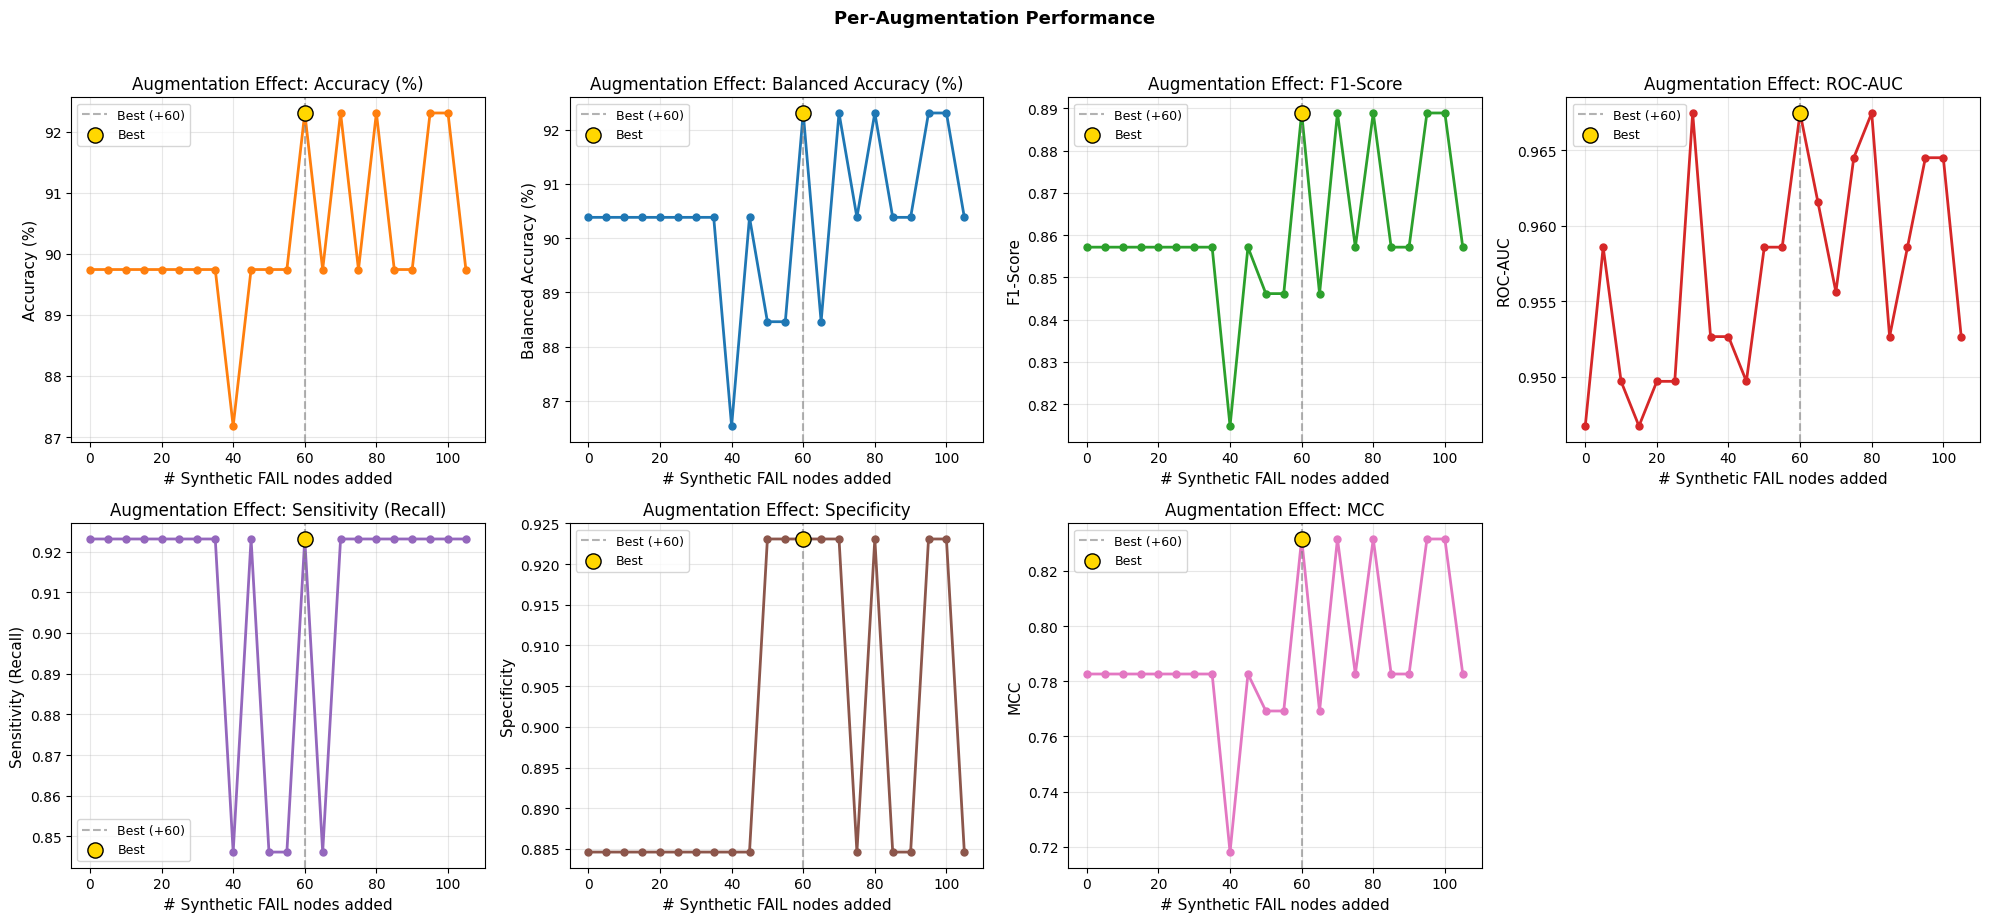

Saved figures/augmentation_per_step_results.png


In [ ]:
# ============================================================
# STEP 4B: Per-Augmentation Performance Tracking
# Results: Table + 7-panel plot (Acc, BalAcc, F1, AUC, Sens, Spec, MCC vs aug_size)
# ============================================================
import os
os.makedirs('figures', exist_ok=True)

print("\n" + "=" * 70)
print("STEP 4B: PER-AUGMENTATION PERFORMANCE TRACKING (default hyperparams)")
print("=" * 70)

_DEFAULT = {
    'lr': 0.001, 'hidden_dim': 64, 'dropout': 0.3,
    'weight_decay': 1e-5, 'appnp_alpha': 0.15, 'appnp_k': 5, 'low_weight': 0.8
}
# _QUICK_EP = 10 if FAST_TEST else 40
_QUICK_EP = 10 if FAST_TEST else 80

_aug_levels = [0] + aug_sizes   # [0, 5, 10, ..., required]
aug_per_step_results = []        # stored — Step 12.6 re-uses this list

print(f"\nQuick epochs per level: {_QUICK_EP}")
print(f"Augmentation levels to evaluate: {len(_aug_levels)} points\n")

# ── Header ──
_hdr = f"{'Step':>8} {'#Synth':>7} {'Total':>7} {'PASS':>6} {'FAIL':>6}  "\
       f"{'Acc%':>7} {'BalAcc%':>9} {'F1':>7} {'AUC':>7} {'Sens':>7} {'Spec':>7} {'MCC':>7}"
print(_hdr)
print("-" * len(_hdr))

for _idx, _n in enumerate(_aug_levels):
    # ── Build augmented training set at this level ──
    if _n == 0:
        _X_aug, _y_aug = X_train_raw.copy(), y_train.copy()
    else:
        _X_aug, _y_aug = graphmixup_augment_raw(
            X_train_raw, y_train, _n, alpha=0.2, seed=SEED)

    # ── Scale (fit on augmented train, apply to val) ──
    _scaler_i = StandardScaler().fit(_X_aug)
    _X_aug_s  = _scaler_i.transform(_X_aug)
    _X_val_s  = _scaler_i.transform(X_val_raw)

    _A_tr, _B_tr, _H_tr = split_channels(_X_aug_s)
    _A_vl, _B_vl, _H_vl = split_channels(_X_val_s)

    _d_tr = make_tensors(_H_tr, _A_tr, _B_tr, _y_aug)
    _d_vl = make_tensors(_H_vl, _A_vl, _B_vl, y_val)

    # ── Quick model ──
    torch.manual_seed(SEED)
    _mod = FDHGNN_VIL(
        high_dim=_H_tr.shape[1],
        hid_dim=_DEFAULT['hidden_dim'],
        num_ch=len(_d_tr[1]),
        partA_dim=_A_tr.shape[1],
        partB_dim=_B_tr.shape[1],
        low_hid=32,
        dropout=_DEFAULT['dropout'],
        alpha=_DEFAULT['appnp_alpha'],
        K=_DEFAULT['appnp_k'],
        low_weight=_DEFAULT['low_weight'],
        vil_dim=16
    ).to(device)

    _mod, _, _ = train_one_model(
        _mod, _d_tr, _d_vl,
        lr=_DEFAULT['lr'],
        weight_decay=_DEFAULT['weight_decay'],
        max_epochs=_QUICK_EP,
        patience=_QUICK_EP
    )

    # ── Evaluate ──
    _ev = eval_metrics_full(
        _mod, _d_vl[0], _d_vl[1], _d_vl[2], _d_vl[3], _d_vl[4])

    _row = {
        'aug_size': _n,
        'total':    len(_y_aug),
        'pass_n':   int(np.sum(_y_aug == 0)),
        'fail_n':   int(np.sum(_y_aug == 1)),
        'acc':      _ev['acc'] * 100,
        'bal_acc':  _ev['bal_acc'] * 100,
        'f1':       _ev['f1'],
        'auc':      _ev['auc'],
        'sens':     _ev['recall'],        # = Sensitivity
        'spec':     _ev['specificity'],
        'mcc':      _ev['mcc'],
    }
    aug_per_step_results.append(_row)

    _label = 'Baseline' if _n == 0 else f'Step {_idx:2d}'
    print(f"{_label:>8} {_n:>7} {len(_y_aug):>7} "
          f"{int(np.sum(_y_aug==0)):>6} {int(np.sum(_y_aug==1)):>6}  "
          f"{_ev['acc']*100:>7.2f} {_ev['bal_acc']*100:>9.2f} {_ev['f1']:>7.3f} {_ev['auc']:>7.3f} "
          f"{_ev['recall']:>7.3f} {_ev['specificity']:>7.3f} {_ev['mcc']:>7.3f}")

# ── Summary ──
_best = max(aug_per_step_results, key=lambda x: x['bal_acc'])
print(f"\n{'─'*50}")
print(f"Best augmentation level  : +{_best['aug_size']} synthetic FAIL nodes")
print(f"Best Accuracy            : {_best['acc']:.2f}%")
print(f"Best Balanced Accuracy   : {_best['bal_acc']:.2f}%")
print(f"Best F1-Score            : {_best['f1']:.3f}")
print(f"Best AUC                 : {_best['auc']:.3f}")
print(f"Best Sensitivity         : {_best['sens']:.3f}")
print(f"Best Specificity         : {_best['spec']:.3f}")
print(f"Best MCC                 : {_best['mcc']:.3f}")
print(f"(Note: Results with best_params will differ — see Step 12.6)")

# ── Plot (now 7 panels: Acc, BalAcc, F1, AUC, Sensitivity, Specificity, MCC) ──
_df = pd.DataFrame(aug_per_step_results)

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
_metrics_plot = [
    ('acc',     'Accuracy (%)',          '#ff7f0e'),
    ('bal_acc', 'Balanced Accuracy (%)', '#1f77b4'),
    ('f1',      'F1-Score',              '#2ca02c'),
    ('auc',     'ROC-AUC',               '#d62728'),
    ('sens',    'Sensitivity (Recall)',  '#9467bd'),
    ('spec',    'Specificity',           '#8c564b'),
    ('mcc',     'MCC',                   '#e377c2'),
]
for ax, (col, ylabel, color) in zip(axes.flat, _metrics_plot):
    ax.plot(_df['aug_size'], _df[col], 'o-', color=color, linewidth=2, markersize=5)
    ax.axvline(x=_best['aug_size'], color='gray', linestyle='--',
               alpha=0.6, label=f'Best (+{_best["aug_size"]})')
    # highlight best point
    ax.scatter([_best['aug_size']], [_best[col]],
               color='gold', edgecolors='black', s=120, zorder=5, label='Best')
    ax.set_xlabel('# Synthetic FAIL nodes added', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Augmentation Effect: {ylabel}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

# 8th grid slot unused (only 7 metrics) — hide it
axes.flat[-1].axis('off')

plt.suptitle(
    'Per-Augmentation Performance',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('figures/augmentation_per_step_results.png', dpi=400, bbox_inches='tight')
plt.show()
print("Saved figures/augmentation_per_step_results.png")

In [ ]:
# ── Best augmentation level manually set ──
# Optimal level obtained from Step 4B
BEST_AUG = max(aug_per_step_results, key=lambda x: x['bal_acc'])['aug_size']

X_train_aug_raw, y_train_aug = graphmixup_augment_raw(
    X_train_raw, y_train,
    n_synth=BEST_AUG,
    alpha=0.2, seed=SEED
)
print(f"Final augmented set: total={len(y_train_aug)}, "
      f"PASS={np.sum(y_train_aug==0)}, FAIL={np.sum(y_train_aug==1)}")

Final augmented set: total=376, PASS=212, FAIL=164


##  (Step 5): Feature Decomposition — StandardScaler fit ONLY on augmented Train, then applied to Validation & Test → Low-pass A (G1,G2 d=2), Low-pass B (numeric d=13), High-pass (one-hot d=43)

In [ ]:
# ============================================================
# STEP 5: Feature Decomposition
# Decomposition (StandardScaler) fit ONLY on the augmented
# training data, then applied to Validation and Test.
# ============================================================
print("\n" + "=" * 70)
print("STEP 5: FEATURE DECOMPOSITION (fit on augmented TRAIN only)")
print("=" * 70)

# Step 5 re-run — নতুন X_train_aug_raw দিয়ে scaler fit করতে হবে
scaler = StandardScaler()
X_train_aug_scaled = scaler.fit_transform(X_train_aug_raw)  # 644 samples
X_val_scaled       = scaler.transform(X_val_raw)
X_test_scaled      = scaler.transform(X_test_raw)

X_A_train, X_B_train, X_H_train = split_channels(X_train_aug_scaled)
X_A_val,   X_B_val,   X_H_val   = split_channels(X_val_scaled)
X_A_test,  X_B_test,  X_H_test  = split_channels(X_test_scaled)

print(f"X_H_train: {X_H_train.shape}, y_train_aug: {y_train_aug.shape}")
\


def split_channels(X_scaled):
    return X_scaled[:, idxA], X_scaled[:, idxB], X_scaled[:, idxH]

X_A_train, X_B_train, X_H_train = split_channels(X_train_aug_scaled)
X_A_val,   X_B_val,   X_H_val   = split_channels(X_val_scaled)
X_A_test,  X_B_test,  X_H_test  = split_channels(X_test_scaled)

print(f"Train (augmented) -> Low-pass A: {X_A_train.shape}, Low-pass B: {X_B_train.shape}, High-pass: {X_H_train.shape}")
print(f"Validation        -> Low-pass A: {X_A_val.shape}, Low-pass B: {X_B_val.shape}, High-pass: {X_H_val.shape}")
print(f"Test              -> Low-pass A: {X_A_test.shape}, Low-pass B: {X_B_test.shape}, High-pass: {X_H_test.shape}")


STEP 5: FEATURE DECOMPOSITION (fit on augmented TRAIN only)
X_H_train: (376, 43), y_train_aug: (376,)
Train (augmented) -> Low-pass A: (376, 2), Low-pass B: (376, 13), High-pass: (376, 43)
Validation        -> Low-pass A: (39, 2), Low-pass B: (39, 13), High-pass: (39, 43)
Test              -> Low-pass A: (40, 2), Low-pass B: (40, 13), High-pass: (40, 43)


##  (Step 6): Hyperparameter Optimization (80/20 split of augmented Train, before 10-Fold CV) — tunes LR, Hidden Dim, Dropout, Weight Decay, APPNP α, APPNP K, Low-pass Weight

In [ ]:
# ============================================================
# STEP 6: Hyperparameter Optimization (before 10-Fold CV)
# Uses an 80/20 split of the AUGMENTED training data.
# Tunes: Learning Rate, Hidden Dimension, Dropout Rate,
# Weight Decay, APPNP alpha, APPNP K, Low-pass Weight.
# Best config (highest validation accuracy) is reused in all folds.
# ============================================================
print("\n" + "=" * 70)
print("STEP 6: HYPERPARAMETER OPTIMIZATION (80/20 split of augmented train)")
print("=" * 70)

tune_train_idx, tune_val_idx = train_test_split(
    np.arange(len(y_train_aug)), test_size=0.20, random_state=SEED, stratify=y_train_aug)

tune_tr = make_tensors(X_H_train[tune_train_idx], X_A_train[tune_train_idx],
                        X_B_train[tune_train_idx], y_train_aug[tune_train_idx])
tune_val = make_tensors(X_H_train[tune_val_idx], X_A_train[tune_val_idx],
                         X_B_train[tune_val_idx], y_train_aug[tune_val_idx])

if FAST_TEST:
    param_grid = {'lr': [0.001], 'hid_dim': [32], 'dropout': [0.3],
                   'weight_decay': [1e-5], 'alpha': [0.15], 'K': [5], 'low_weight': [0.8]}
    tune_epochs = 10
else:
    # Expanded grid for a more thorough search (more lr / hidden_dim /
    # dropout / weight_decay / low_weight options). Note: this multiplies
    # the total number of combinations significantly -> longer runtime,
    # use a GPU runtime.
    param_grid = {'lr': [0.001, 0.0005, 0.0001],
                   'hid_dim': [32, 64, 128],
                   'dropout': [0.3, 0.4, 0.5],
                   'weight_decay': [1e-5, 1e-4, 1e-3],
                   'alpha': [0.1, 0.15, 0.2],
                   'K': [5, 10, 15],
                   'low_weight': [0.5, 0.6, 0.7, 0.8]}
    tune_epochs = 60

best_val_acc = -1.0
best_params = None
n_ch = len(tune_tr[1])

for lr in param_grid['lr']:
    for hdim in param_grid['hid_dim']:
        for dr in param_grid['dropout']:
            for wd in param_grid['weight_decay']:
                for alpha in param_grid['alpha']:
                    for K in param_grid['K']:
                        for lw in param_grid['low_weight']:
                            torch.manual_seed(SEED)
                            model_tune = FDHGNN_VIL(
                                high_dim=X_H_train.shape[1], hid_dim=hdim, num_ch=n_ch,
                                partA_dim=X_A_train.shape[1], partB_dim=X_B_train.shape[1],
                                low_hid=32, dropout=dr, alpha=alpha, K=K, low_weight=lw,
                                vil_dim=16).to(device)
                            opt = Adam(model_tune.parameters(), lr=lr, weight_decay=wd)
                            crit = nn.CrossEntropyLoss()
                            for _ in range(tune_epochs):
                                model_tune.train()
                                opt.zero_grad()
                                logits = model_tune(tune_tr[0], tune_tr[1], tune_tr[2], tune_tr[3])
                                loss = crit(logits, tune_tr[4])
                                loss.backward()
                                opt.step()
                            model_tune.eval()
                            with torch.no_grad():
                                val_logits = model_tune(tune_val[0], tune_val[1], tune_val[2], tune_val[3])

                                # val_acc = (val_logits.argmax(dim=1) == tune_val[4]).float().mean().item()
                                _vpred      = val_logits.argmax(dim=1).cpu().numpy()
                                _vtrue      = tune_val[4].cpu().numpy()
                                val_bal_acc = balanced_accuracy_score(_vtrue, _vpred)
                                if val_bal_acc > best_val_acc:
                                    best_val_acc = val_bal_acc
                                    best_params  = {'lr': lr, 'hidden_dim': hdim, 'dropout': dr,
                                                    'weight_decay': wd, 'appnp_alpha': alpha,
                                                    'appnp_k': K, 'low_weight': lw}

print(f"Best hyperparameters (val acc={best_val_acc*100:.2f}%):")
for k, v in best_params.items():
    print(f"  {k}: {v}")


STEP 6: HYPERPARAMETER OPTIMIZATION (80/20 split of augmented train)
Best hyperparameters (val acc=91.97%):
  lr: 0.001
  hidden_dim: 64
  dropout: 0.3
  weight_decay: 0.001
  appnp_alpha: 0.1
  appnp_k: 5
  low_weight: 0.5


##  (Steps 7 & 9): 10-Fold Stratified CV training of Adaptive-FDHGNN-APPNP+VIL (KNN Hypergraph, Framelet decomposition, AFA+DCP, Tabular MLP, VIL) — then Best Model Selection by Validation Balanced Accuracy. (Step 8 APPNP propagation is built into the model's forward pass)

In [ ]:
# ============================================================
# STEP 7: Adaptive-FDHGNN Model Training (10-Fold Stratified CV)
# Run on the augmented TRAINING set only, using the selected hyperparameters
# ============================================================
print("\n" + "=" * 70)
print("STEP 7 & 8: 10-FOLD CV - Adaptive-FDHGNN-APPNP + VIL + AFA/DCP")
print("=" * 70)

N_FOLDS = 10
MAX_EPOCHS = 30 if FAST_TEST else 200
PATIENCE = 10 if FAST_TEST else 20

skf = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []      # per-fold metrics dict (on the held-out CV fold, used as "validation")
fold_states = []       # per-fold trained state_dicts
fold_histories = []    # per-fold training curves

n_ch_full = None
for fold, (cv_train_idx, cv_val_idx) in enumerate(skf.split(X_H_train, y_train_aug)):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} --- CV-train={len(cv_train_idx)}, CV-val={len(cv_val_idx)}")

    data_tr = make_tensors(X_H_train[cv_train_idx], X_A_train[cv_train_idx],
                            X_B_train[cv_train_idx], y_train_aug[cv_train_idx])
    data_val = make_tensors(X_H_train[cv_val_idx], X_A_train[cv_val_idx],
                             X_B_train[cv_val_idx], y_train_aug[cv_val_idx])
    n_ch_full = len(data_tr[1])

    # Inside the CV loop (Step 7), after creating data_tr and data_val, add:
    if len(torch.unique(data_tr[4])) < 2 or len(torch.unique(data_val[4])) < 2:
        print(f"Skipping fold {fold+1} due to missing class")
        continue

    torch.manual_seed(SEED + fold)
    model = FDHGNN_VIL(
        high_dim=X_H_train.shape[1], hid_dim=best_params['hidden_dim'], num_ch=n_ch_full,
        partA_dim=X_A_train.shape[1], partB_dim=X_B_train.shape[1],
        low_hid=32, dropout=best_params['dropout'], alpha=best_params['appnp_alpha'],
        K=best_params['appnp_k'], low_weight=best_params['low_weight'], vil_dim=16).to(device)

    model, best_val_acc, history = train_one_model(
        model, data_tr, data_val, lr=best_params['lr'],
        weight_decay=best_params['weight_decay'],
        max_epochs=MAX_EPOCHS, patience=PATIENCE)

    metrics = eval_metrics_full(model, data_val[0], data_val[1], data_val[2], data_val[3], data_val[4])
    print(f"  Fold {fold+1}: ValAcc={metrics['acc']*100:.2f}%  ValBalAcc={metrics['bal_acc']*100:.2f}%  "
          f"F1={metrics['f1']:.3f}  Sens={metrics['recall']:.3f}  Spec={metrics['specificity']:.3f}  "
          f"MCC={metrics['mcc']:.3f}  AUC={metrics['auc']:.3f}  ActiveCh={int(model.framelet.channel_mask.sum().item())}")

    fold_results.append(metrics)
    fold_states.append({k: v.detach().cpu().clone() for k, v in model.state_dict().items()})
    fold_histories.append(history)

print("\n10-fold CV summary (validation-fold performance):")
print(f"  Mean Bal.Acc      = {np.mean([r['bal_acc'] for r in fold_results])*100:.2f}% "
      f"+/- {np.std([r['bal_acc'] for r in fold_results])*100:.2f}%")
print(f"  Mean F1           = {np.mean([r['f1'] for r in fold_results]):.4f} "
      f"+/- {np.std([r['f1'] for r in fold_results]):.4f}")
print(f"  Mean AUC          = {np.mean([r['auc'] for r in fold_results]):.4f} "
      f"+/- {np.std([r['auc'] for r in fold_results]):.4f}")
print(f"  Mean Sensitivity  = {np.mean([r['recall'] for r in fold_results]):.4f} "
      f"+/- {np.std([r['recall'] for r in fold_results]):.4f}")
print(f"  Mean Specificity  = {np.mean([r['specificity'] for r in fold_results]):.4f} "
      f"+/- {np.std([r['specificity'] for r in fold_results]):.4f}")
print(f"  Mean MCC          = {np.mean([r['mcc'] for r in fold_results]):.4f} "
      f"+/- {np.std([r['mcc'] for r in fold_results]):.4f}")


# ============================================================
# STEP 8: Best Model Selection
# Select the fold whose Validation Balanced Accuracy is highest;
# save it as the Final Proposed Model.
# ============================================================
print("\n" + "=" * 70)
print("STEP 8: BEST MODEL SELECTION")
print("=" * 70)

best_fold = int(np.argmax([r['bal_acc'] for r in fold_results]))
print(f"Best fold: {best_fold+1} (Validation Balanced Accuracy = {fold_results[best_fold]['bal_acc']*100:.2f}%, "
      f"Sens={fold_results[best_fold]['recall']:.3f}, Spec={fold_results[best_fold]['specificity']:.3f}, "
      f"MCC={fold_results[best_fold]['mcc']:.3f})")

final_model = FDHGNN_VIL(
    high_dim=X_H_train.shape[1], hid_dim=best_params['hidden_dim'], num_ch=n_ch_full,
    partA_dim=X_A_train.shape[1], partB_dim=X_B_train.shape[1],
    low_hid=32, dropout=best_params['dropout'], alpha=best_params['appnp_alpha'],
    K=best_params['appnp_k'], low_weight=best_params['low_weight'], vil_dim=16).to(device)
final_model.load_state_dict({k: v.to(device) for k, v in fold_states[best_fold].items()})
best_history = fold_histories[best_fold]
print("Final Proposed Model saved (from best fold).")


STEP 7 & 8: 10-FOLD CV - Adaptive-FDHGNN-APPNP + VIL + AFA/DCP

--- Fold 1/10 --- CV-train=338, CV-val=38
  Fold 1: ValAcc=94.74%  ValBalAcc=95.45%  F1=0.941  Sens=1.000  Spec=0.909  MCC=0.899  AUC=1.000  ActiveCh=7

--- Fold 2/10 --- CV-train=338, CV-val=38
  Fold 2: ValAcc=86.84%  ValBalAcc=88.64%  F1=0.865  Sens=1.000  Spec=0.773  MCC=0.767  AUC=0.920  ActiveCh=7

--- Fold 3/10 --- CV-train=338, CV-val=38
  Fold 3: ValAcc=78.95%  ValBalAcc=80.95%  F1=0.810  Sens=1.000  Spec=0.619  MCC=0.649  AUC=0.854  ActiveCh=6

--- Fold 4/10 --- CV-train=338, CV-val=38
  Fold 4: ValAcc=89.47%  ValBalAcc=89.36%  F1=0.882  Sens=0.882  Spec=0.905  MCC=0.787  AUC=0.916  ActiveCh=7

--- Fold 5/10 --- CV-train=338, CV-val=38
  Fold 5: ValAcc=92.11%  ValBalAcc=91.74%  F1=0.909  Sens=0.882  Spec=0.952  MCC=0.841  AUC=0.927  ActiveCh=7

--- Fold 6/10 --- CV-train=338, CV-val=38
  Fold 6: ValAcc=94.74%  ValBalAcc=95.24%  F1=0.944  Sens=1.000  Spec=0.905  MCC=0.900  AUC=0.978  ActiveCh=7

--- Fold 7/10 ---

## Step 9: Behavioral Feature & Partitioning Contribution Analysis — three ablation variants | (1) "w/o Behavioral (XH)": hypergraph branch bypassed, Tabular MLP only. (2) "Behavioral Only (XH)": Tabular MLP branch bypassed, hypergraph branch only. (3) "No Partitioning (Flat)": all 58 features combined into a single hypergraph, no semantic XA/XB/XH separation. All three reuse the same 10-fold CV protocol as Step 7.

In [ ]:
# ============================================================
# NEW STEP: "w/o Behavioral" Ablation
# ============================================================

print("\n" + "=" * 70)
print("NEW ABLATION VARIANT: w/o Behavioral (XH) — Hypergraph branch removed")
print("=" * 70)


class FDHGNN_VIL_NoBehavioral(FDHGNN_VIL):
    """
    Identical to FDHGNN_VIL, except the hypergraph/behavioral branch
    (framelet propagation over XH, APPNP smoothing, VIL cross-fusion)
    is fully bypassed. Prediction relies solely on the Tabular MLP
    branch over XA (grades) and XB (numeric demographic features),
    i.e. logits_final = logits_low.

    This isolates the marginal contribution of the 43-dim behavioral
    (categorical) feature block XH and its KNN hypergraph structure.
    """
    def forward(self, x_high, ops, x_A, x_B):
        logits_A = self.mlpA(x_A)
        logits_B = self.mlpB(x_B)
        logits_low = (5 * logits_A + 3 * logits_B) / 8.0
        return logits_low

    def prune(self, att_running, ratio=0.25, keep=1):
        # No framelet channels are used in this variant -> nothing to prune.
        return []


def run_ablation_variant(model_cls, label, n_folds=10, **model_kwargs):
    """
    Runs the same 10-fold stratified CV protocol as Step 7, but with
    model_cls instead of FDHGNN_VIL. Reuses X_H_train/X_A_train/X_B_train,
    y_train_aug, best_params, make_tensors, train_one_model,
    eval_metrics_full exactly as in your existing Step 7 cell.
    """
    skf_v = StratifiedKFold(n_folds, shuffle=True, random_state=SEED)
    results_v = []

    for fold, (cv_train_idx, cv_val_idx) in enumerate(skf_v.split(X_H_train, y_train_aug)):
        data_tr = make_tensors(X_H_train[cv_train_idx], X_A_train[cv_train_idx],
                                X_B_train[cv_train_idx], y_train_aug[cv_train_idx])
        data_val = make_tensors(X_H_train[cv_val_idx], X_A_train[cv_val_idx],
                                 X_B_train[cv_val_idx], y_train_aug[cv_val_idx])

        if len(torch.unique(data_tr[4])) < 2 or len(torch.unique(data_val[4])) < 2:
            print(f"  Skipping fold {fold+1} due to missing class")
            continue

        torch.manual_seed(SEED + fold)
        n_ch_v = len(data_tr[1])
        model_v = model_cls(
            high_dim=X_H_train.shape[1], hid_dim=best_params['hidden_dim'], num_ch=n_ch_v,
            partA_dim=X_A_train.shape[1], partB_dim=X_B_train.shape[1],
            low_hid=32, dropout=best_params['dropout'], alpha=best_params['appnp_alpha'],
            K=best_params['appnp_k'], low_weight=best_params['low_weight'], vil_dim=16,
            **model_kwargs
        ).to(device)

        model_v, _, _ = train_one_model(
            model_v, data_tr, data_val, lr=best_params['lr'],
            weight_decay=best_params['weight_decay'],
            max_epochs=MAX_EPOCHS, patience=PATIENCE)

        m = eval_metrics_full(model_v, data_val[0], data_val[1], data_val[2], data_val[3], data_val[4])
        print(f"  Fold {fold+1}: Acc={m['acc']*100:.2f}%  BalAcc={m['bal_acc']*100:.2f}%  "
              f"F1={m['f1']:.3f}  Sens={m['recall']:.3f}  Spec={m['specificity']:.3f}  MCC={m['mcc']:.3f}")
        results_v.append(m)

    summary_v = {
        k: (float(np.mean([r[k] for r in results_v])), float(np.std([r[k] for r in results_v])))
        for k in ['acc', 'bal_acc', 'precision', 'recall', 'specificity', 'f1', 'mcc', 'auc']
    }

    print(f"\n[{label}] 10-fold CV summary (mean +/- std):")
    for k, (mu, sd) in summary_v.items():
        print(f"  {k:12s}: {mu*100:.2f} +/- {sd*100:.2f}" if k != 'mcc'
              else f"  {k:12s}: {mu:.4f} +/- {sd:.4f}")

    return summary_v, results_v


# ---- Run the "w/o Behavioral" variant ----
wo_behavioral_summary, wo_behavioral_folds = run_ablation_variant(
    FDHGNN_VIL_NoBehavioral, label="w/o Behavioral (XH)"
)

# ---- Merge into the same ablation-table format as Tables VII/VIII ----
ablation_row_wo_behavioral = {
    'Variant': 'w/o Behavioral (XH)',
    'Acc (%)': round(wo_behavioral_summary['acc'][0] * 100, 2),
    'F1': round(wo_behavioral_summary['f1'][0], 3),
    'MCC': round(wo_behavioral_summary['mcc'][0], 3),
    'Bal. Acc (%)': round(wo_behavioral_summary['bal_acc'][0] * 100, 2),
    'Sens.': round(wo_behavioral_summary['recall'][0], 3),
    'Spec.': round(wo_behavioral_summary['specificity'][0], 3),
}
print("\nRow ready to insert into your ablation table (Tables VII/VIII format):")
print(ablation_row_wo_behavioral)

# Optional: save to CSV alongside your other figures/tables
import os as _os
_os.makedirs('figures', exist_ok=True)
pd.DataFrame([ablation_row_wo_behavioral]).to_csv(
    'figures/ablation_wo_behavioral.csv', index=False)
print("\nSaved figures/ablation_wo_behavioral.csv")


# ============================================================
# SECOND VARIANT: "Behavioral Only" — Tabular MLP branch removed
# ============================================================
# Reverse of the variant above: keeps the hypergraph/behavioral
# branch (framelet + APPNP) and removes the Tabular MLP branch
# over XA/XB. Prediction relies solely on XH and its KNN
# hypergraph structure. Isolates the standalone predictive value
# of behavioral features without grade/numeric support.
# ============================================================

print("\n" + "=" * 70)
print("NEW ABLATION VARIANT: Behavioral Only — Tabular MLP branch removed")
print("=" * 70)


class FDHGNN_VIL_BehavioralOnly(FDHGNN_VIL):
    """
    Identical to FDHGNN_VIL, except the Tabular MLP branch
    (logits_low over XA, XB) is bypassed. Prediction relies solely
    on the hypergraph/behavioral branch: framelet propagation over
    XH -> APPNP smoothing -> output projection. VIL is also bypassed
    since it requires logits_low as an input; cross-frequency fusion
    is meaningless when there is no second stream to fuse with.
    """
    def forward(self, x_high, ops, x_A, x_B):
        h, att = self.framelet(x_high, ops)
        if not self.use_afa_dcp:
            h_list = []
            for c in range(self.framelet.num_channels):
                if self.framelet.channel_mask[c] < 0.5:
                    continue
                S = ops[c]
                h_list.append(F.relu(self.framelet.linears[c](S @ x_high)))
            h = torch.stack(h_list, dim=0).mean(dim=0)
        logits_high = self.out_high(h)
        if self.use_appnp:
            logits_high = appnp_propagate(logits_high, ops[0], self.alpha, self.K)
        return logits_high

    def prune(self, att_running, ratio=0.25, keep=1):
        if not self.use_afa_dcp:
            return []
        return self.framelet.prune(att_running, ratio, keep)


# ---- Run the "Behavioral Only" variant ----
behavioral_only_summary, behavioral_only_folds = run_ablation_variant(
    FDHGNN_VIL_BehavioralOnly, label="Behavioral Only (XH)"
)

# ---- Merge into the same ablation-table format as Tables VII/VIII ----
ablation_row_behavioral_only = {
    'Variant': 'Behavioral Only (XH)',
    'Acc (%)': round(behavioral_only_summary['acc'][0] * 100, 2),
    'F1': round(behavioral_only_summary['f1'][0], 3),
    'MCC': round(behavioral_only_summary['mcc'][0], 3),
    'Bal. Acc (%)': round(behavioral_only_summary['bal_acc'][0] * 100, 2),
    'Sens.': round(behavioral_only_summary['recall'][0], 3),
    'Spec.': round(behavioral_only_summary['specificity'][0], 3),
}
print("\nRow ready to insert into your ablation table (Tables VII/VIII format):")
print(ablation_row_behavioral_only)

pd.DataFrame([ablation_row_behavioral_only]).to_csv(
    'figures/ablation_behavioral_only.csv', index=False)
print("\nSaved figures/ablation_behavioral_only.csv")

# ---- Combined summary table for both new variants ----
combined_behavioral_table = pd.DataFrame([
    ablation_row_wo_behavioral,
    ablation_row_behavioral_only,
])
print("\nCombined behavioral-analysis table:")
print(combined_behavioral_table.to_string(index=False))
combined_behavioral_table.to_csv('figures/behavioral_contribution_table.csv', index=False)
print("\nSaved figures/behavioral_contribution_table.csv")


# ============================================================
# THIRD VARIANT: "No Partitioning (Flat)" — single hypergraph
# over all 58 features, no semantic XA/XB/XH separation
# ============================================================

print("\n" + "=" * 70)
print("NEW ABLATION VARIANT: No Partitioning (Flat) — all 58 features, single hypergraph")
print("=" * 70)


class FDHGNN_VIL_FlatNoPartition(FDHGNN_VIL):
    """
    Identical to FDHGNN_VIL, except the framelet/hypergraph branch
    is built over the FULL 58-dim feature matrix (XA || XB || XH
    concatenated) instead of only the 43-dim high-pass partition XH.
    The Tabular MLP branch and VIL fusion are bypassed entirely,
    since there is no separate low-pass stream left to fuse with —
    semantic partitioning is precisely what creates that second
    stream in the proposed architecture, so removing partitioning
    removes the basis for fusion as well.

    NOTE: this changes high_dim from 43 -> 58 and therefore needs
    its own hypergraph (built on X_full, not X_H) and its own
    FrameletLayer sized for 58 input dims. This is handled by the
    run_flat_variant() helper below, which builds tensors directly
    rather than reusing make_tensors()/X_H_train.
    """
    def forward(self, x_high, ops, x_A, x_B):
        h, att = self.framelet(x_high, ops)
        if not self.use_afa_dcp:
            h_list = []
            for c in range(self.framelet.num_channels):
                if self.framelet.channel_mask[c] < 0.5:
                    continue
                S = ops[c]
                h_list.append(F.relu(self.framelet.linears[c](S @ x_high)))
            h = torch.stack(h_list, dim=0).mean(dim=0)
        logits_high = self.out_high(h)
        if self.use_appnp:
            logits_high = appnp_propagate(logits_high, ops[0], self.alpha, self.K)
        return logits_high

    def prune(self, att_running, ratio=0.25, keep=1):
        if not self.use_afa_dcp:
            return []
        return self.framelet.prune(att_running, ratio, keep)


def run_flat_variant(n_folds=10, k=15):
    """
    Builds X_full = [XA | XB | XH] (58-dim), constructs a single
    KNN hypergraph from it (same k and cosine-similarity convention
    as the main method's build_knn_hypergraph), and runs the same
    10-fold stratified CV protocol as Step 7 / run_ablation_variant,
    but using FDHGNN_VIL_FlatNoPartition with high_dim=58 and a
    single unified feature stream.
    """
    X_full_train = np.concatenate([X_A_train, X_B_train, X_H_train], axis=1)

    skf_v = StratifiedKFold(n_folds, shuffle=True, random_state=SEED)
    results_v = []

    for fold, (cv_train_idx, cv_val_idx) in enumerate(skf_v.split(X_full_train, y_train_aug)):
        XF_tr_np = X_full_train[cv_train_idx]
        XF_val_np = X_full_train[cv_val_idx]
        y_tr_np = y_train_aug[cv_train_idx]
        y_val_np = y_train_aug[cv_val_idx]

        if len(np.unique(y_tr_np)) < 2 or len(np.unique(y_val_np)) < 2:
            print(f"  Skipping fold {fold+1} due to missing class")
            continue

        adj_tr = build_knn_hypergraph(XF_tr_np, k=k)
        ops_tr = to_ops_tensor(build_framelet_ops(adj_tr))
        adj_val = build_knn_hypergraph(XF_val_np, k=k)
        ops_val = to_ops_tensor(build_framelet_ops(adj_val))

        XF_tr = torch.tensor(XF_tr_np, dtype=torch.float32, device=device)
        XF_val = torch.tensor(XF_val_np, dtype=torch.float32, device=device)
        y_tr = torch.tensor(y_tr_np, dtype=torch.long, device=device)
        y_val = torch.tensor(y_val_np, dtype=torch.long, device=device)

        # Dummy zero-width-safe placeholders for XA/XB args (unused by this
        # variant's forward(), but required by train_one_model's call signature)
        dummy_A_tr = torch.zeros((XF_tr.shape[0], X_A_train.shape[1]), device=device)
        dummy_B_tr = torch.zeros((XF_tr.shape[0], X_B_train.shape[1]), device=device)
        dummy_A_val = torch.zeros((XF_val.shape[0], X_A_train.shape[1]), device=device)
        dummy_B_val = torch.zeros((XF_val.shape[0], X_B_train.shape[1]), device=device)

        data_tr = (XF_tr, ops_tr, dummy_A_tr, dummy_B_tr, y_tr)
        data_val = (XF_val, ops_val, dummy_A_val, dummy_B_val, y_val)

        torch.manual_seed(SEED + fold)
        n_ch_v = len(ops_tr)
        model_v = FDHGNN_VIL_FlatNoPartition(
            high_dim=X_full_train.shape[1], hid_dim=best_params['hidden_dim'], num_ch=n_ch_v,
            partA_dim=X_A_train.shape[1], partB_dim=X_B_train.shape[1],
            low_hid=32, dropout=best_params['dropout'], alpha=best_params['appnp_alpha'],
            K=best_params['appnp_k'], low_weight=best_params['low_weight'], vil_dim=16
        ).to(device)

        model_v, _, _ = train_one_model(
            model_v, data_tr, data_val, lr=best_params['lr'],
            weight_decay=best_params['weight_decay'],
            max_epochs=MAX_EPOCHS, patience=PATIENCE)

        m = eval_metrics_full(model_v, data_val[0], data_val[1], data_val[2], data_val[3], data_val[4])
        print(f"  Fold {fold+1}: Acc={m['acc']*100:.2f}%  BalAcc={m['bal_acc']*100:.2f}%  "
              f"F1={m['f1']:.3f}  Sens={m['recall']:.3f}  Spec={m['specificity']:.3f}  MCC={m['mcc']:.3f}")
        results_v.append(m)

    summary_v = {
        k: (float(np.mean([r[k] for r in results_v])), float(np.std([r[k] for r in results_v])))
        for k in ['acc', 'bal_acc', 'precision', 'recall', 'specificity', 'f1', 'mcc', 'auc']
    }

    print("\n[No Partitioning (Flat)] 10-fold CV summary (mean +/- std):")
    for kk, (mu, sd) in summary_v.items():
        print(f"  {kk:12s}: {mu*100:.2f} +/- {sd*100:.2f}" if kk != 'mcc'
              else f"  {kk:12s}: {mu:.4f} +/- {sd:.4f}")

    return summary_v, results_v


flat_summary, flat_folds = run_flat_variant()

ablation_row_flat = {
    'Variant': 'No Partitioning (Flat, 58-dim)',
    'Acc (%)': round(flat_summary['acc'][0] * 100, 2),
    'F1': round(flat_summary['f1'][0], 3),
    'MCC': round(flat_summary['mcc'][0], 3),
    'Bal. Acc (%)': round(flat_summary['bal_acc'][0] * 100, 2),
    'Sens.': round(flat_summary['recall'][0], 3),
    'Spec.': round(flat_summary['specificity'][0], 3),
}
print("\nRow ready to insert into your ablation table (Tables VII/VIII format):")
print(ablation_row_flat)

pd.DataFrame([ablation_row_flat]).to_csv('figures/ablation_flat_no_partition.csv', index=False)
print("\nSaved figures/ablation_flat_no_partition.csv")

# ---- Final combined table: all three behavioral/partitioning variants ----
final_combined_table = pd.DataFrame([
    ablation_row_flat,
    ablation_row_wo_behavioral,
    ablation_row_behavioral_only,
])
print("\nFinal combined behavioral + partitioning analysis table:")
print(final_combined_table.to_string(index=False))
final_combined_table.to_csv('figures/behavioral_and_partitioning_table.csv', index=False)
print("\nSaved figures/behavioral_and_partitioning_table.csv")


NEW ABLATION VARIANT: w/o Behavioral (XH) — Hypergraph branch removed
  Fold 1: Acc=100.00%  BalAcc=100.00%  F1=1.000  Sens=1.000  Spec=1.000  MCC=1.000
  Fold 2: Acc=81.58%  BalAcc=84.09%  F1=0.821  Sens=1.000  Spec=0.682  MCC=0.689
  Fold 3: Acc=71.05%  BalAcc=73.81%  F1=0.756  Sens=1.000  Spec=0.476  MCC=0.538
  Fold 4: Acc=86.84%  BalAcc=86.41%  F1=0.848  Sens=0.824  Spec=0.905  MCC=0.733
  Fold 5: Acc=78.95%  BalAcc=77.59%  F1=0.733  Sens=0.647  Spec=0.905  MCC=0.578
  Fold 6: Acc=89.47%  BalAcc=89.92%  F1=0.889  Sens=0.941  Spec=0.857  MCC=0.794
  Fold 7: Acc=94.59%  BalAcc=94.49%  F1=0.938  Sens=0.938  Spec=0.952  MCC=0.890
  Fold 8: Acc=83.78%  BalAcc=83.48%  F1=0.812  Sens=0.812  Spec=0.857  MCC=0.670
  Fold 9: Acc=72.97%  BalAcc=73.96%  F1=0.722  Sens=0.812  Spec=0.667  MCC=0.476
  Fold 10: Acc=78.38%  BalAcc=78.72%  F1=0.765  Sens=0.812  Spec=0.762  MCC=0.569

[w/o Behavioral (XH)] 10-fold CV summary (mean +/- std):
  acc         : 83.76 +/- 8.71
  bal_acc     : 84.25 +/- 8

## (Steps 10 & 11): Final Testing on the held-out Test set + Performance Evaluation (Accuracy, Balanced Accuracy, Precision, Recall, Specificity, F1, MCC, ROC-AUC)

In [ ]:
# ============================================================
# STEP 10: Final Testing
# The Best Model is evaluated on the held-out TEST set, which
# was never used for training, augmentation, decomposition fitting,
# or hyperparameter tuning -> a true generalization estimate.
# ============================================================
print("\n" + "=" * 70)
print("STEP 10: FINAL TESTING ON HELD-OUT TEST SET")
print("=" * 70)

data_test = make_tensors(X_H_test, X_A_test, X_B_test, y_test)
test_metrics = eval_metrics_full(final_model, data_test[0], data_test[1], data_test[2], data_test[3], data_test[4])

print(f"Test set size: {len(y_test)} (PASS={np.sum(y_test==0)}, FAIL={np.sum(y_test==1)})")
print(f"Confusion matrix [[TN, FP],[FN, TP]] = [[{test_metrics['tn']}, {test_metrics['fp']}], "
      f"[{test_metrics['fn']}, {test_metrics['tp']}]]")


# Step 10 এর final_model evaluation এর পরে এই block যোগ করো:

# ── Optimal threshold tuning on Validation set ──
print("\nFinding optimal decision threshold on Validation set...")

data_val_final = make_tensors(X_H_val, X_A_val, X_B_val, y_val)
final_model.eval()
with torch.no_grad():
    _vlogits = final_model(data_val_final[0], data_val_final[1],
                            data_val_final[2], data_val_final[3])
    _vprob   = F.softmax(_vlogits, dim=1)[:, 1].cpu().numpy()

# Finer threshold sweep (step=0.01) optimizing Balanced Accuracy on Validation
best_thresh, best_thresh_bal = 0.5, 0.0
for thresh in np.arange(0.05, 0.96, 0.01):
    _pred_t   = (_vprob >= thresh).astype(int)
    _bal_t    = balanced_accuracy_score(y_val, _pred_t)
    if _bal_t > best_thresh_bal:
        best_thresh_bal = _bal_t
        best_thresh     = thresh

print(f"Optimal threshold (val): {best_thresh:.2f} → Val BalAcc={best_thresh_bal*100:.2f}%")

# এই threshold দিয়ে test set evaluate করো:
data_test = make_tensors(X_H_test, X_A_test, X_B_test, y_test)
final_model.eval()
with torch.no_grad():
    _tlogits  = final_model(data_test[0], data_test[1], data_test[2], data_test[3])
    test_prob = F.softmax(_tlogits, dim=1)[:, 1].cpu().numpy()

test_pred_tuned = (test_prob >= best_thresh).astype(int)

# ✅ FIX: rebuild test_metrics using the TUNED threshold predictions
# (previously test_metrics used eval_metrics_full's internal argmax,
#  i.e. threshold=0.5, so Step 11 ignored the tuned threshold entirely)
_tn, _fp, _fn, _tp = confusion_matrix(y_test, test_pred_tuned, labels=[0, 1]).ravel()
test_metrics = {
    'acc':        accuracy_score(y_test, test_pred_tuned),
    'bal_acc':    balanced_accuracy_score(y_test, test_pred_tuned),
    'precision':  precision_score(y_test, test_pred_tuned, zero_division=0),
    'recall':     recall_score(y_test, test_pred_tuned, zero_division=0),
    'specificity': _tn / (_tn + _fp) if (_tn + _fp) > 0 else 0.0,
    'f1':         f1_score(y_test, test_pred_tuned, zero_division=0),
    'mcc':        matthews_corrcoef(y_test, test_pred_tuned),
    'auc':        roc_auc_score(y_test, test_prob) if len(np.unique(y_test)) > 1 else 0.0,
    'tn': _tn, 'fp': _fp, 'fn': _fn, 'tp': _tp,
    'y_true': y_test, 'prob': test_prob, 'pred': test_pred_tuned,
}

# Threshold-tuned metrics আলাদা print করো
print(f"\nTest Results (threshold={best_thresh:.2f}):")
print(f"  Balanced Accuracy : {test_metrics['bal_acc']*100:.2f}%")
print(f"  F1-Score          : {test_metrics['f1']:.4f}")
print(f"  Recall (FAIL)     : {test_metrics['recall']:.4f}")
print(f"  Confusion         : TN={_tn}, FP={_fp}, FN={_fn}, TP={_tp}")


# ============================================================
# STEP 11: Performance Evaluation
# ============================================================
print("\n" + "=" * 70)
print("STEP 11: PERFORMANCE EVALUATION (Final Proposed Model on Test set)")
print("=" * 70)

print(f"Accuracy            : {test_metrics['acc']*100:.2f}%")
print(f"Balanced Accuracy   : {test_metrics['bal_acc']*100:.2f}%")
print(f"Precision           : {test_metrics['precision']:.4f}")
print(f"Recall (Sensitivity): {test_metrics['recall']:.4f}")
print(f"F1-Score            : {test_metrics['f1']:.4f}")
print(f"Specificity         : {test_metrics['specificity']:.4f}")
print(f"ROC-AUC             : {test_metrics['auc']:.4f}")
print(f"MCC                 : {test_metrics['mcc']:.4f}")


STEP 10: FINAL TESTING ON HELD-OUT TEST SET
Test set size: 40 (PASS=27, FAIL=13)
Confusion matrix [[TN, FP],[FN, TP]] = [[24, 3], [0, 13]]

Finding optimal decision threshold on Validation set...
Optimal threshold (val): 0.50 → Val BalAcc=80.77%

Test Results (threshold=0.50):
  Balanced Accuracy : 94.44%
  F1-Score          : 0.8966
  Recall (FAIL)     : 1.0000
  Confusion         : TN=24, FP=3, FN=0, TP=13

STEP 11: PERFORMANCE EVALUATION (Final Proposed Model on Test set)
Accuracy            : 92.50%
Balanced Accuracy   : 94.44%
Precision           : 0.8125
Recall (Sensitivity): 1.0000
F1-Score            : 0.8966
Specificity         : 0.8889
ROC-AUC             : 0.9915
MCC                 : 0.8498


##  (Step 12): Performance Visualization and Analysis — Confusion Matrix, ROC Curve, PR Curve, Train/Val Loss & Accuracy Curves, GraphMixup Effect Plot, Ablation Study


STEP 12: PERFORMANCE VISUALIZATION AND ANALYSIS


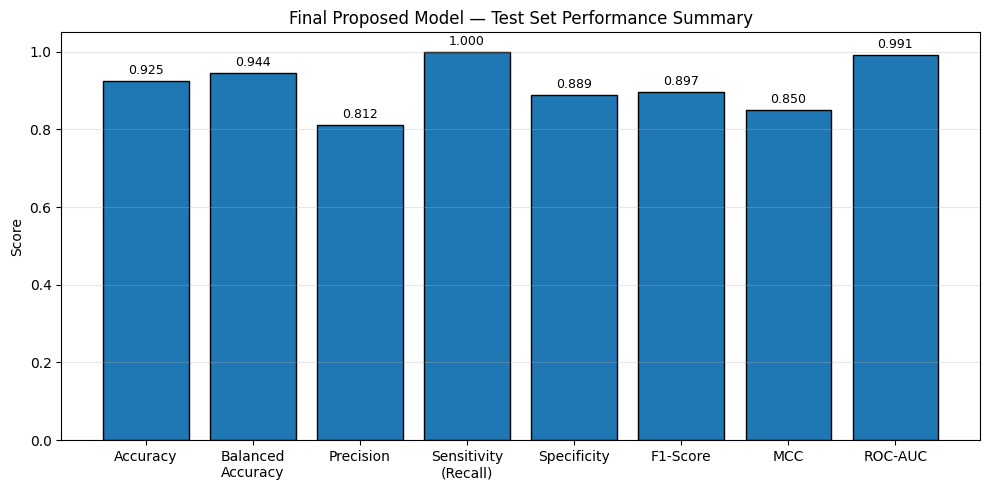

Saved figures/final_metrics_summary.png

Test Sensitivity : 1.0000
Test Specificity : 0.8889
Test MCC         : 0.8498
Saved figures/confusion_matrix.png
Saved figures/roc_curve.png
Saved figures/precision_recall_curve.png
Saved figures/loss_accuracy_curves.png

Running augmentation-effect sweep (quick models)...
  +   0 synthetic nodes -> Val BalAcc=90.38%, F1=0.857, AUC=0.935, Sens=0.923, Spec=0.885, MCC=0.783
  +   5 synthetic nodes -> Val BalAcc=90.38%, F1=0.857, AUC=0.944, Sens=0.923, Spec=0.885, MCC=0.783
  +  10 synthetic nodes -> Val BalAcc=90.38%, F1=0.857, AUC=0.944, Sens=0.923, Spec=0.885, MCC=0.783
  +  15 synthetic nodes -> Val BalAcc=92.31%, F1=0.889, AUC=0.967, Sens=0.923, Spec=0.923, MCC=0.832
  +  20 synthetic nodes -> Val BalAcc=90.38%, F1=0.857, AUC=0.941, Sens=0.923, Spec=0.885, MCC=0.783
  +  25 synthetic nodes -> Val BalAcc=92.31%, F1=0.889, AUC=0.967, Sens=0.923, Spec=0.923, MCC=0.832
  +  30 synthetic nodes -> Val BalAcc=90.38%, F1=0.857, AUC=0.938, Sens=0.923, 

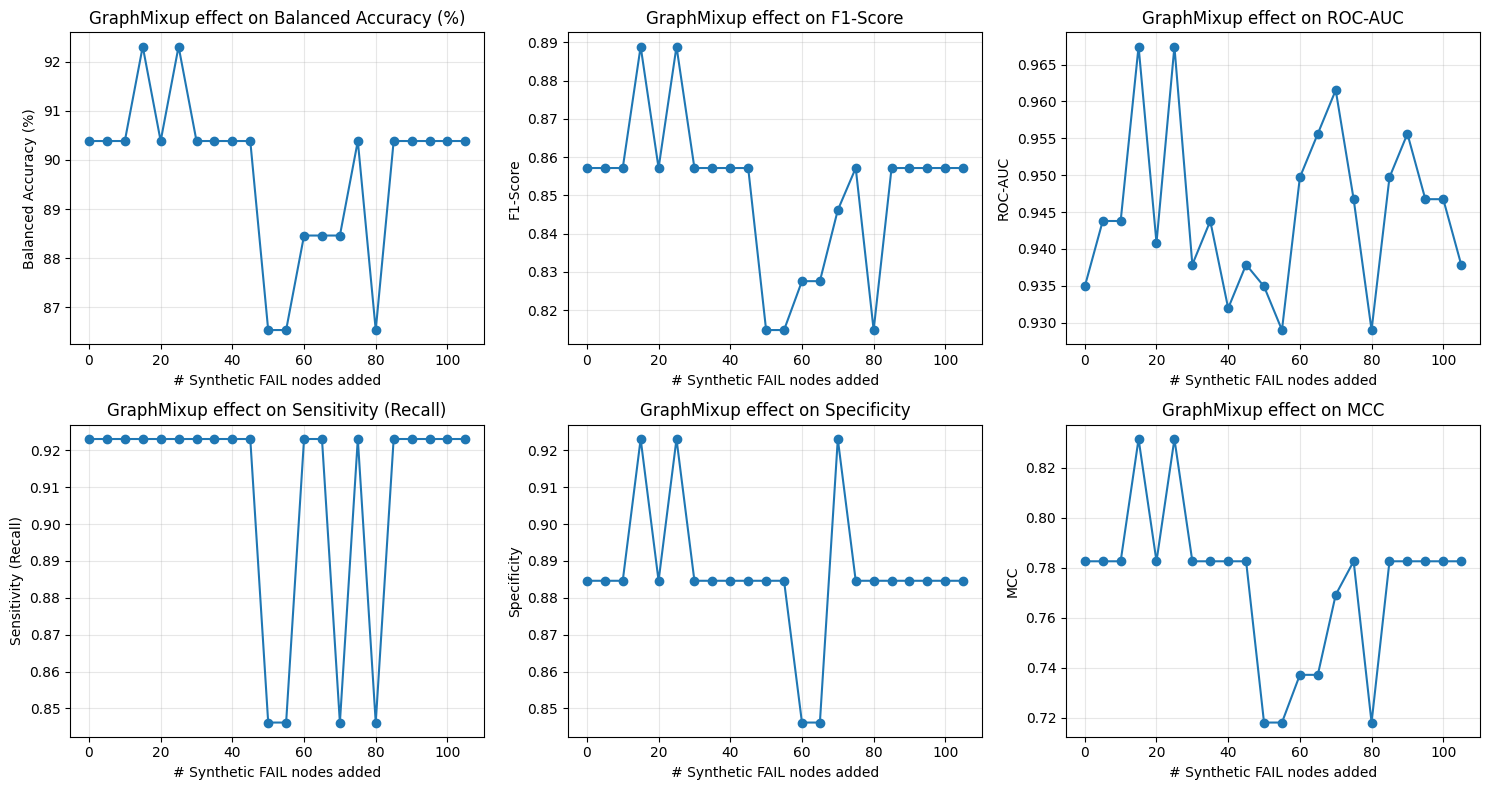

Saved figures/graphmixup_effect.png

Running ablation study...

Ablation results (Test set — all metrics):
Variant                             Acc%   BalAcc%    Sens    Spec      F1     MCC     AUC
------------------------------------------------------------------------------------------
Full Model (Adaptive-FDHGNN-APPNP+VIL)   92.50     94.44   1.000   0.889   0.897   0.850   0.991
w/o VIL                            92.50     92.45   0.923   0.926   0.889   0.834   0.980
w/o APPNP                          90.00     88.60   0.846   0.926   0.846   0.772   0.977
w/o AFA-DCP                        90.00     90.60   0.923   0.889   0.857   0.786   0.980
w/o GraphMixup                     85.00     86.89   0.923   0.815   0.800   0.699   0.980


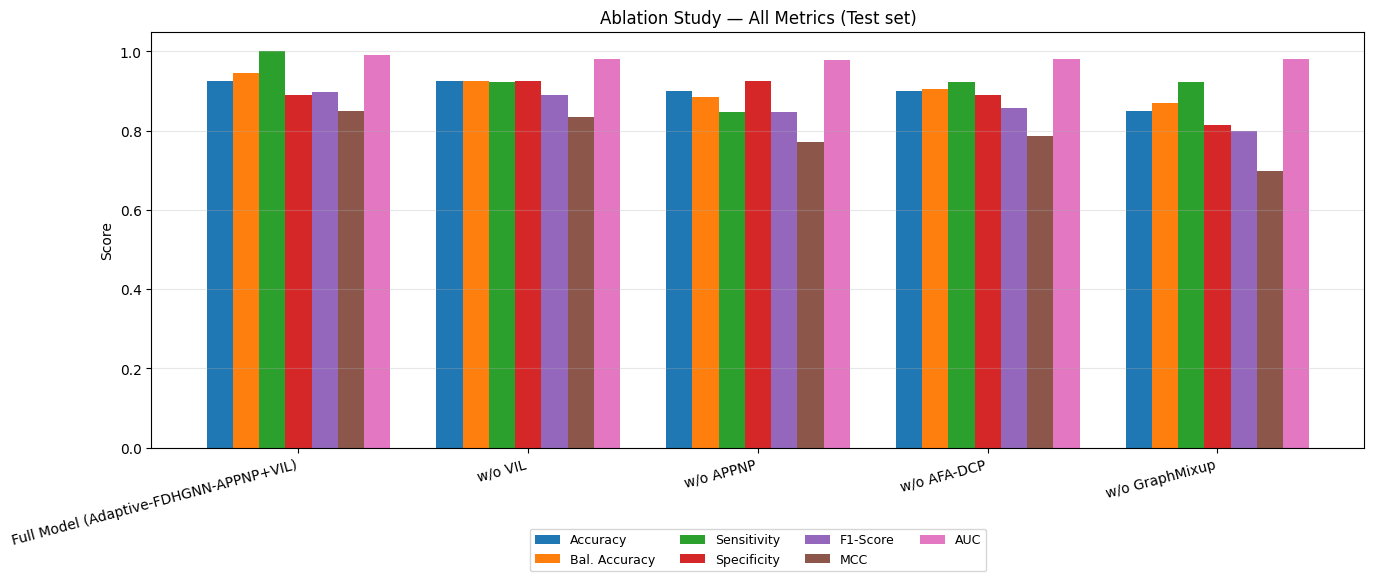

Saved figures/ablation_study.png
Saved figures/ablation_study_balacc.png


In [ ]:
# ============================================================
# STEP 12: Performance Visualization and Analysis & Ablation Study
# ============================================================
print("\n" + "=" * 70)
print("STEP 12: PERFORMANCE VISUALIZATION AND ANALYSIS")
print("=" * 70)

os.makedirs('figures', exist_ok=True)

# ---- 12.0 Final Test Metrics Summary (Bar Chart) — includes Sens/Spec/MCC ----
_metric_labels = ['Accuracy', 'Balanced\nAccuracy', 'Precision', 'Sensitivity\n(Recall)',
                   'Specificity', 'F1-Score', 'MCC', 'ROC-AUC']
_metric_vals = [test_metrics['acc'], test_metrics['bal_acc'], test_metrics['precision'],
                 test_metrics['recall'], test_metrics['specificity'], test_metrics['f1'],
                 test_metrics['mcc'], test_metrics['auc']]
plt.figure(figsize=(10, 5))
_bars = plt.bar(_metric_labels, _metric_vals, color='#1f77b4', edgecolor='black')
for _b, _v in zip(_bars, _metric_vals):
    plt.text(_b.get_x() + _b.get_width()/2, _v + 0.01, f'{_v:.3f}',
              ha='center', va='bottom', fontsize=9)
plt.ylim(min(0, min(_metric_vals) - 0.1), 1.05)
plt.ylabel('Score')
plt.title('Final Proposed Model — Test Set Performance Summary')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/final_metrics_summary.png', dpi=400)
plt.show()
print("Saved figures/final_metrics_summary.png")
print(f"\nTest Sensitivity : {test_metrics['recall']:.4f}")
print(f"Test Specificity : {test_metrics['specificity']:.4f}")
print(f"Test MCC         : {test_metrics['mcc']:.4f}")

# ---- 12.1 Confusion Matrix ----
cm = np.array([[test_metrics['tn'], test_metrics['fp']],
               [test_metrics['fn'], test_metrics['tp']]])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True,
            xticklabels=['Pred Pass', 'Pred Fail'], yticklabels=['True Pass', 'True Fail'])
plt.title('Confusion Matrix - Final Proposed Model (Test set)')
plt.tight_layout()
plt.savefig('figures/confusion_matrix.png', dpi=400)
plt.close()
print("Saved figures/confusion_matrix.png")

# ---- 12.2 ROC Curve ----
fpr, tpr, _ = roc_curve(test_metrics['y_true'], test_metrics['prob'])
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(5, 4.5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc_val:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Test set'); plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/roc_curve.png', dpi=400)
plt.close()
print("Saved figures/roc_curve.png")

# ---- 12.3 Precision-Recall Curve ----
prec_curve, rec_curve, _ = precision_recall_curve(test_metrics['y_true'], test_metrics['prob'])
pr_auc = auc(rec_curve, prec_curve)
plt.figure(figsize=(5, 4.5))
plt.plot(rec_curve, prec_curve, color='green', lw=2, label=f'PR (AUC = {pr_auc:.3f})')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Test set'); plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig('figures/precision_recall_curve.png', dpi=400)
plt.close()
print("Saved figures/precision_recall_curve.png")

# ---- 12.4 / 12.5 Training & Validation Loss / Accuracy Curves (best fold) ----
epochs_range = range(1, len(best_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(epochs_range, best_history['train_loss'], label='Train Loss')
axes[0].plot(epochs_range, best_history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss (best fold)'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, [a*100 for a in best_history['train_acc']], label='Train Acc')
axes[1].plot(epochs_range, [a*100 for a in best_history['val_acc']], label='Val Acc')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training vs Validation Accuracy (best fold)'); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/loss_accuracy_curves.png', dpi=400)
plt.close()
print("Saved figures/loss_accuracy_curves.png")

# ---- 12.6 GraphMixup Augmentation Effect Plot (best_params sweep) ----
print("\nRunning augmentation-effect sweep (quick models)...")
aug_levels = [0] + aug_sizes
if FAST_TEST:
    aug_levels = aug_levels[:: max(1, len(aug_levels) // 3)] or [0]
aug_effect = []
quick_epochs = 10 if FAST_TEST else 60

for n_total in aug_levels:
    if n_total == 0:
        X_aug_i, y_aug_i = X_train_raw.copy(), y_train.copy()
    else:
        X_aug_i, y_aug_i = graphmixup_augment_raw(X_train_raw, y_train, n_total, alpha=0.2, seed=SEED)

    scaler_i = StandardScaler().fit(X_aug_i)
    X_aug_i_scaled = scaler_i.transform(X_aug_i)
    X_val_i_scaled = scaler_i.transform(X_val_raw)
    A_i, B_i, H_i = split_channels(X_aug_i_scaled)
    A_v, B_v, H_v = split_channels(X_val_i_scaled)

    data_tr_i = make_tensors(H_i, A_i, B_i, y_aug_i)
    data_val_i = make_tensors(H_v, A_v, B_v, y_val)

    torch.manual_seed(SEED)
    model_i = FDHGNN_VIL(high_dim=H_i.shape[1], hid_dim=best_params['hidden_dim'], num_ch=len(data_tr_i[1]),
                          partA_dim=A_i.shape[1], partB_dim=B_i.shape[1], low_hid=32,
                          dropout=best_params['dropout'], alpha=best_params['appnp_alpha'],
                          K=best_params['appnp_k'], low_weight=best_params['low_weight'], vil_dim=16).to(device)
    model_i, _, _ = train_one_model(model_i, data_tr_i, data_val_i, lr=best_params['lr'],
                                     weight_decay=best_params['weight_decay'],
                                     max_epochs=quick_epochs, patience=quick_epochs)
    m_i = eval_metrics_full(model_i, data_val_i[0], data_val_i[1], data_val_i[2], data_val_i[3], data_val_i[4])
    aug_effect.append({
        'aug_size': n_total, 'bal_acc': m_i['bal_acc']*100, 'f1': m_i['f1'], 'auc': m_i['auc'],
        'sens': m_i['recall'], 'spec': m_i['specificity'], 'mcc': m_i['mcc'],
    })
    print(f"  +{n_total:4d} synthetic nodes -> Val BalAcc={m_i['bal_acc']*100:.2f}%, F1={m_i['f1']:.3f}, "
          f"AUC={m_i['auc']:.3f}, Sens={m_i['recall']:.3f}, Spec={m_i['specificity']:.3f}, MCC={m_i['mcc']:.3f}")

df_aug_effect = pd.DataFrame(aug_effect)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
_panels = [
    ('bal_acc', 'Balanced Accuracy (%)'),
    ('f1',      'F1-Score'),
    ('auc',     'ROC-AUC'),
    ('sens',    'Sensitivity (Recall)'),
    ('spec',    'Specificity'),
    ('mcc',     'MCC'),
]
for ax, (col, title) in zip(axes.flat, _panels):
    ax.plot(df_aug_effect['aug_size'], df_aug_effect[col], 'o-')
    ax.set_xlabel('# Synthetic FAIL nodes added'); ax.set_ylabel(title)
    ax.set_title(f'GraphMixup effect on {title}'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('figures/graphmixup_effect.png', dpi=400)
plt.show()
print("Saved figures/graphmixup_effect.png")



# ---- 12.7 Ablation Study ----
print("\nRunning ablation study...")
ablation_epochs = 15 if FAST_TEST else 100
ablation_results = {}

# (a) Full proposed model (already trained) -> evaluate on test
ablation_results['Full Model\n(Adaptive-FDHGNN-APPNP+VIL)'] = test_metrics

def run_variant(use_vil, use_appnp, use_afa_dcp,
                X_H_tr_, X_A_tr_, X_B_tr_, y_tr_,
                X_H_te_, X_A_te_, X_B_te_, y_te_):
    data_tr_v  = make_tensors(X_H_tr_, X_A_tr_, X_B_tr_, y_tr_)
    data_val_v = make_tensors(X_H_val, X_A_val, X_B_val, y_val)  # val for stopping
    data_te_v  = make_tensors(X_H_te_, X_A_te_, X_B_te_, y_te_)  # test only for eval

    torch.manual_seed(SEED)
    model_v = FDHGNN_VIL(
        high_dim=X_H_tr_.shape[1], hid_dim=best_params['hidden_dim'],
        num_ch=len(data_tr_v[1]),
        partA_dim=X_A_tr_.shape[1], partB_dim=X_B_tr_.shape[1],
        low_hid=32, dropout=best_params['dropout'],
        alpha=best_params['appnp_alpha'], K=best_params['appnp_k'],
        low_weight=best_params['low_weight'], vil_dim=16,
        use_vil=use_vil, use_appnp=use_appnp, use_afa_dcp=use_afa_dcp
    ).to(device)

    model_v, _, _ = train_one_model(
        model_v, data_tr_v, data_val_v,
        lr=best_params['lr'], weight_decay=best_params['weight_decay'],
        max_epochs=ablation_epochs, patience=ablation_epochs
    )
    m_v = eval_metrics_full(
        model_v, data_te_v[0], data_te_v[1], data_te_v[2], data_te_v[3], data_te_v[4]
    )
    return m_v


# (b) without VIL
ablation_results['w/o VIL'] = run_variant(False, True, True,
    X_H_train, X_A_train, X_B_train, y_train_aug, X_H_test, X_A_test, X_B_test, y_test)

# (c) without APPNP
ablation_results['w/o APPNP'] = run_variant(True, False, True,
    X_H_train, X_A_train, X_B_train, y_train_aug, X_H_test, X_A_test, X_B_test, y_test)

# (d) without AFA/DCP (uniform channel fusion, no pruning)
ablation_results['w/o AFA-DCP'] = run_variant(True, True, False,
    X_H_train, X_A_train, X_B_train, y_train_aug, X_H_test, X_A_test, X_B_test, y_test)

# (e) without GraphMixup augmentation
scaler_noaug = StandardScaler().fit(X_train_raw)
X_train_noaug_scaled = scaler_noaug.transform(X_train_raw)
X_test_noaug_scaled = scaler_noaug.transform(X_test_raw)
A_noaug_tr, B_noaug_tr, H_noaug_tr = split_channels(X_train_noaug_scaled)
A_noaug_te, B_noaug_te, H_noaug_te = split_channels(X_test_noaug_scaled)
ablation_results['w/o GraphMixup'] = run_variant(True, True, True,
    H_noaug_tr, A_noaug_tr, B_noaug_tr, y_train, H_noaug_te, A_noaug_te, B_noaug_te, y_test)

# ── Ablation results — সব metric (Acc, BalAcc, Sens, Spec, F1, MCC, AUC) ──
print("\nAblation results (Test set — all metrics):")
_ab_hdr = f"{'Variant':<32} {'Acc%':>7} {'BalAcc%':>9} {'Sens':>7} {'Spec':>7} {'F1':>7} {'MCC':>7} {'AUC':>7}"
print(_ab_hdr)
print("-" * len(_ab_hdr))
for k, m in ablation_results.items():
    _name = k.replace(chr(10), ' ')
    print(f"{_name:<32} {m['acc']*100:>7.2f} {m['bal_acc']*100:>9.2f} "
          f"{m['recall']:>7.3f} {m['specificity']:>7.3f} {m['f1']:>7.3f} "
          f"{m['mcc']:>7.3f} {m['auc']:>7.3f}")

# ── Plot: grouped bar chart, all 7 metrics per variant ──
_ab_metrics = [
    ('acc',         'Accuracy',     lambda m: m['acc']),
    ('bal_acc',     'Bal. Accuracy', lambda m: m['bal_acc']),
    ('recall',      'Sensitivity',  lambda m: m['recall']),
    ('specificity', 'Specificity',  lambda m: m['specificity']),
    ('f1',          'F1-Score',     lambda m: m['f1']),
    ('mcc',         'MCC',          lambda m: m['mcc']),
    ('auc',         'AUC',          lambda m: m['auc']),
]
_variant_names = [k.replace(chr(10), ' ') for k in ablation_results.keys()]
_n_var = len(_variant_names)
_n_met = len(_ab_metrics)
_x = np.arange(_n_var)
_bar_w = 0.8 / _n_met

plt.figure(figsize=(14, 6))
for _mi, (_key, _label, _fn) in enumerate(_ab_metrics):
    _vals = [_fn(ablation_results[k]) for k in ablation_results.keys()]
    plt.bar(_x + _mi * _bar_w - 0.4 + _bar_w/2, _vals, width=_bar_w, label=_label)
plt.xticks(_x, _variant_names, rotation=15, ha='right')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.title('Ablation Study — All Metrics (Test set)')
plt.legend(fontsize=9, ncol=4, loc='upper center', bbox_to_anchor=(0.5, -0.18))
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/ablation_study.png', dpi=400, bbox_inches='tight')
plt.show()
print("Saved figures/ablation_study.png")

# ── Bal.Acc-only bar chart
plt.figure(figsize=(8, 5))
_vals_balacc = [ablation_results[k]['bal_acc']*100 for k in ablation_results.keys()]
_colors_bar = ['#2ca02c'] + ['#d62728'] * (_n_var - 1)
plt.bar(_variant_names, _vals_balacc, color=_colors_bar)
plt.ylabel('Balanced Accuracy (%)')
plt.title('Ablation Study — Balanced Accuracy (Test set)')
plt.xticks(rotation=20, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/ablation_study_balacc.png', dpi=400)
plt.close()
print("Saved figures/ablation_study_balacc.png")

## Step 13: Final Result Reporting — Comparison with SVM, LR, SLFNN, GCN, MTGNN, FD-HGNN baselines + improvement analysis

In [ ]:
# ============================================================
# STEP 13: BASELINE COMPARISON
# ============================================================
import os, pickle
import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             precision_score, recall_score, f1_score,
                             matthews_corrcoef, roc_auc_score, confusion_matrix)
import warnings
warnings.filterwarnings('ignore')

print("\n" + "=" * 70)
print("STEP 13: BASELINE COMPARISON (Raw data, no augmentation, fair tuning)")
print("=" * 70)

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ---------- 1. Load raw data ----------
DATASET_FILE = 'student-mat.csv'
_search_roots = [
    '/kaggle/input/student-performance',
    '/kaggle/input',
    '/content',
    '.',
    '/mat/data',
]
_csv_path = None
for root in _search_roots:
    if not os.path.isdir(root):
        continue
    for dirpath, _, filenames in os.walk(root):
        for fn in filenames:
            if fn.lower() == DATASET_FILE.lower():
                _csv_path = os.path.join(dirpath, fn)
                break
        if _csv_path is not None:
            break
    if _csv_path is not None:
        break

if _csv_path is not None:
    print(f"Found {DATASET_FILE} at: {_csv_path}")
    df_raw = pd.read_csv(_csv_path, sep=';')
else:
    raise FileNotFoundError(f"Could not find {DATASET_FILE} under {_search_roots}")

print(f"Raw shape: {df_raw.shape}")

# ---------- 2. Clean and preprocess ----------
df_raw = df_raw.drop_duplicates().reset_index(drop=True)
print(f"After dropping duplicates: {len(df_raw)} rows")

if df_raw.isnull().sum().sum() > 0:
    for c in df_raw.select_dtypes(include=[np.number]).columns:
        if df_raw[c].isnull().any():
            df_raw[c] = df_raw[c].fillna(df_raw[c].median())
    for c in df_raw.select_dtypes(include=['object']).columns:
        if df_raw[c].isnull().any():
            df_raw[c] = df_raw[c].fillna(df_raw[c].mode().iloc[0])
    print("Missing values imputed.")

y_all = (df_raw['G3'] < 10).astype(int).values
X_all = df_raw.drop(columns=['G3'])

cat_cols = X_all.select_dtypes(include=['object']).columns.tolist()
X_enc = pd.get_dummies(X_all, columns=cat_cols, drop_first=False)
feature_names = X_enc.columns.tolist()
X_flat = X_enc.values.astype(np.float32)
print(f"Encoded feature matrix: {X_flat.shape}")

# ---------- 3. Train/Val/Test split (80/10/10) ----------
all_idx = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(all_idx, test_size=0.20,
                                       random_state=SEED, stratify=y_all)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50,
                                     random_state=SEED, stratify=y_all[temp_idx])

X_train_raw = X_flat[train_idx]
X_val_raw   = X_flat[val_idx]
X_test_raw  = X_flat[test_idx]
y_train = y_all[train_idx]
y_val   = y_all[val_idx]
y_test  = y_all[test_idx]

print(f"Train: {len(train_idx)}, Val: {len(val_idx)}, Test: {len(test_idx)}")
print(f"Train class distribution: PASS={np.sum(y_train==0)}, FAIL={np.sum(y_train==1)}")

# ---------- 4. Standard scaling ----------
scaler = StandardScaler().fit(X_train_raw)
X_train_scaled = scaler.transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)
X_test_scaled  = scaler.transform(X_test_raw)

in_dim = X_train_scaled.shape[1]

# ---------- 5. Helper: metrics ----------
def metrics_from_pred(y_true, pred, prob=None):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    out = {
        'acc': accuracy_score(y_true, pred),
        'bal_acc': balanced_accuracy_score(y_true, pred),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'specificity': tn / (tn + fp) if (tn + fp) > 0 else 0.0,
        'f1': f1_score(y_true, pred, zero_division=0),
        'mcc': matthews_corrcoef(y_true, pred),
    }
    out['auc'] = roc_auc_score(y_true, prob) if (prob is not None and len(np.unique(y_true)) > 1) else 0.0
    out['y_true'] = y_true
    out['prob'] = prob if prob is not None else pred.astype(float)
    out['pred'] = pred
    return out

# ---------- 6. Neural training helper (SAME for every NN model) ----------
def train_nn(model, forward_train, forward_val, y_tr, y_val,
             lr=0.001, wd=1e-5, max_epochs=150, patience=30):
    y_tr_t = torch.tensor(y_tr, dtype=torch.long, device=device)
    counts = np.bincount(y_tr)
    w = torch.tensor([1.0/max(counts[0],1), 1.0/max(counts[1],1)], dtype=torch.float32, device=device)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = Adam(model.parameters(), lr=lr, weight_decay=wd)

    best_bal, best_state, pat = -1.0, None, 0
    train_acc_hist = []
    val_acc_hist = []
    best_epoch = 0

    for epoch in range(1, max_epochs+1):
        model.train(); opt.zero_grad()
        logits = forward_train()
        loss = crit(logits, y_tr_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()

        model.eval()
        with torch.no_grad():
            train_pred = logits.argmax(dim=1).cpu().numpy()
            train_acc = accuracy_score(y_tr, train_pred) * 100
            train_acc_hist.append(train_acc)

            val_logits = forward_val()
            val_pred = val_logits.argmax(dim=1).cpu().numpy()
            val_acc = accuracy_score(y_val, val_pred) * 100
            val_acc_hist.append(val_acc)
            bal = balanced_accuracy_score(y_val, val_pred)

        if bal > best_bal:
            best_bal, pat = bal, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
            best_epoch = epoch
        else:
            pat += 1
            if pat >= patience:
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, best_bal, train_acc_hist, val_acc_hist, best_epoch

# Convert to tensors
Xtr_t = torch.tensor(X_train_scaled, dtype=torch.float32, device=device)
Xval_t = torch.tensor(X_val_scaled, dtype=torch.float32, device=device)
Xte_t = torch.tensor(X_test_scaled, dtype=torch.float32, device=device)

comparison = {}
train_histories = {}

# ============================================================
# 7. SVM
# ============================================================
print("\nTraining SVM ...")
svm = SVC(C=10, kernel='rbf', gamma='scale', class_weight='balanced', probability=True, random_state=SEED)
svm.fit(X_train_scaled, y_train)
pred = svm.predict(X_test_scaled)
prob = svm.predict_proba(X_test_scaled)[:, 1]
comparison['SVM'] = metrics_from_pred(y_test, pred, prob)

# ============================================================
# 8. Logistic Regression
# ============================================================
print("Tuning LR (grid search, selected on validation set)...")
lr_grid = [0.001, 0.01, 0.1, 1, 10, 100]
best_lr_val, best_lr_model, best_lr_C = -1.0, None, None
for C in lr_grid:
    m = LogisticRegression(C=C, penalty='l2', solver='liblinear',
                            fit_intercept=True, class_weight='balanced',
                            random_state=SEED, max_iter=1000)
    m.fit(X_train_scaled, y_train)
    val_pred = m.predict(X_val_scaled)
    bal = balanced_accuracy_score(y_val, val_pred)
    if bal > best_lr_val:
        best_lr_val, best_lr_model, best_lr_C = bal, m, C
print(f"Best LR C={best_lr_C} (val BalAcc={best_lr_val*100:.2f}%)")
pred = best_lr_model.predict(X_test_scaled)
prob = best_lr_model.predict_proba(X_test_scaled)[:, 1]
comparison['LR'] = metrics_from_pred(y_test, pred, prob)

# ============================================================
# 9. SLFNN
# ============================================================
class SLFNN(nn.Module):
    def __init__(self, in_dim, hidden=128, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 2)
        )
    def forward(self, x):
        return self.net(x)

print("Tuning SLFNN (grid search, selected on validation set)...")
slfnn_grid = [
    (hid, dp, wd)
    for hid in [32, 64, 128, 256]
    for dp in [0.3, 0.5, 0.6]
    for wd in [1e-5, 1e-4, 1e-3, 1e-2]
]
best_slfnn_val, best_slfnn_state, best_slfnn_cfg = -1.0, None, None
best_slfnn_hist = None
best_slfnn_val_hist = None
best_slfnn_epoch = None
for hid, dp, wd in slfnn_grid:
    torch.manual_seed(SEED)
    m = SLFNN(in_dim, hidden=hid, dropout=dp).to(device)
    m, bal, hist, val_hist, b_epoch = train_nn(m, lambda: m(Xtr_t), lambda: m(Xval_t),
                            y_train, y_val, wd=wd, max_epochs=200, patience=20)
    if bal > best_slfnn_val:
        best_slfnn_val = bal
        best_slfnn_state = {k: v.detach().clone() for k, v in m.state_dict().items()}
        best_slfnn_cfg = (hid, dp, wd)
        best_slfnn_hist = hist
        best_slfnn_val_hist = val_hist
        best_slfnn_epoch = b_epoch

print(f"Best SLFNN config: hidden={best_slfnn_cfg[0]}, dropout={best_slfnn_cfg[1]}, "
      f"weight_decay={best_slfnn_cfg[2]} (val BalAcc={best_slfnn_val*100:.2f}%)")

SLFNN_SEEDS = [42, 123, 2024]
_slfnn_test_probs = []
for _i, _sd in enumerate(SLFNN_SEEDS):
    torch.manual_seed(_sd)
    m = SLFNN(in_dim, hidden=best_slfnn_cfg[0], dropout=best_slfnn_cfg[1]).to(device)
    m, _bal, _hist, _val_hist, _b_epoch = train_nn(m, lambda: m(Xtr_t), lambda: m(Xval_t),
                            y_train, y_val, wd=best_slfnn_cfg[2], max_epochs=200, patience=20)
    m.eval()
    with torch.no_grad():
        logits = m(Xte_t)
        prob = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    _slfnn_test_probs.append(prob)
    if _i == 0:
        # keep the first seed's model/history for Step 13D/13E (overfitting check, curves)
        best_slfnn_state = {k: v.detach().clone() for k, v in m.state_dict().items()}
        train_histories['SLFNN'] = _hist
        best_slfnn_val_hist = _val_hist
        best_slfnn_epoch = _b_epoch

slfnn_ensemble_prob = np.mean(_slfnn_test_probs, axis=0)
slfnn_ensemble_pred = (slfnn_ensemble_prob >= 0.5).astype(int)
print(f"SLFNN seed ensemble ({len(SLFNN_SEEDS)} seeds) test predictions averaged.")
comparison['SLFNN'] = metrics_from_pred(y_test, slfnn_ensemble_pred, slfnn_ensemble_prob)

# ============================================================
# 10. GCN
# ============================================================
def build_knn_graph(X, k=15):
    n = X.shape[0]
    k = min(k, n-1)
    knn = NearestNeighbors(n_neighbors=k+1, metric='cosine').fit(X)
    _, idx = knn.kneighbors(X)
    A = np.zeros((n,n), dtype=np.float32)
    for i in range(n):
        for j in idx[i, 1:]:
            A[i,j] = 1.0
            A[j,i] = 1.0
    d = A.sum(axis=1, keepdims=True); d[d==0]=1.0
    A = A / d
    A = A + np.eye(n)
    d = A.sum(axis=1)
    d_inv_sqrt = np.power(d, -0.5); d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0
    D = np.diag(d_inv_sqrt)
    return (D @ A @ D).astype(np.float32)

def adaptive_k(n, k_max=15):
    return max(3, min(k_max, n // 4))

class SimpleGCN(nn.Module):
    def __init__(self, in_dim, hid=128, dropout=0.3):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hid)
        self.lin2 = nn.Linear(hid, 2)
        self.drop = nn.Dropout(dropout)
    def forward(self, x, A):
        h = F.relu(self.lin1(A @ x))
        h = self.drop(h)
        return self.lin2(A @ h)

print("Building default graph (raw-scaled, k=15) for MTGNN...")
k_tr = adaptive_k(X_train_scaled.shape[0])
k_val = adaptive_k(X_val_scaled.shape[0])
k_te = adaptive_k(X_test_scaled.shape[0])
A_tr = torch.tensor(build_knn_graph(X_train_scaled, k_tr), dtype=torch.float32, device=device)
A_val = torch.tensor(build_knn_graph(X_val_scaled, k_val), dtype=torch.float32, device=device)
A_te = torch.tensor(build_knn_graph(X_test_scaled, k_te), dtype=torch.float32, device=device)

print("Fitting PCA for GCN graph construction...")
GCN_PCA_DIM = min(30, X_train_scaled.shape[1])
pca_gcn = PCA(n_components=GCN_PCA_DIM, random_state=SEED).fit(X_train_scaled)
X_train_gcn = pca_gcn.transform(X_train_scaled)
X_val_gcn   = pca_gcn.transform(X_val_scaled)
X_test_gcn  = pca_gcn.transform(X_test_scaled)
in_dim_gcn = X_train_gcn.shape[1]
print(f"GCN feature dim reduced via PCA: {X_train_scaled.shape[1]} -> {in_dim_gcn} "
      f"(explained variance: {pca_gcn.explained_variance_ratio_.sum()*100:.1f}%)")

Xtr_t_gcn  = torch.tensor(X_train_gcn, dtype=torch.float32, device=device)
Xval_t_gcn = torch.tensor(X_val_gcn,   dtype=torch.float32, device=device)
Xte_t_gcn  = torch.tensor(X_test_gcn,  dtype=torch.float32, device=device)

print("Building GCN graphs for each candidate k...")
gcn_k_candidates = [5, 10, 15, 20]
graphs_by_k = {}
for kmax in gcn_k_candidates:
    _k_tr = adaptive_k(X_train_gcn.shape[0], kmax)
    _k_val = adaptive_k(X_val_gcn.shape[0], kmax)
    _k_te = adaptive_k(X_test_gcn.shape[0], kmax)
    graphs_by_k[kmax] = (
        torch.tensor(build_knn_graph(X_train_gcn, _k_tr), dtype=torch.float32, device=device),
        torch.tensor(build_knn_graph(X_val_gcn, _k_val), dtype=torch.float32, device=device),
        torch.tensor(build_knn_graph(X_test_gcn, _k_te), dtype=torch.float32, device=device),
    )

print("Tuning GCN (grid search incl. k, selected on validation set)...")
gcn_grid = [
    (hid, dp, wd, kmax)
    for hid in [32, 64, 128, 256]
    for dp in [0.3, 0.5, 0.6]
    for wd in [1e-5, 1e-4, 1e-3, 1e-2]
    for kmax in gcn_k_candidates
]
best_gcn_val, best_gcn_state, best_gcn_cfg = -1.0, None, None
best_gcn_hist = None
best_gcn_val_hist = None
best_gcn_epoch = None
for hid, dp, wd, kmax in gcn_grid:
    A_tr_k, A_val_k, A_te_k = graphs_by_k[kmax]
    torch.manual_seed(SEED)
    m = SimpleGCN(in_dim_gcn, hid=hid, dropout=dp).to(device)
    m, bal, hist, val_hist, b_epoch = train_nn(m, lambda: m(Xtr_t_gcn, A_tr_k), lambda: m(Xval_t_gcn, A_val_k),
                            y_train, y_val, wd=wd, max_epochs=200, patience=20)
    if bal > best_gcn_val:
        best_gcn_val = bal
        best_gcn_state = {k: v.detach().clone() for k, v in m.state_dict().items()}
        best_gcn_cfg = (hid, dp, wd, kmax)
        best_gcn_hist = hist
        best_gcn_val_hist = val_hist
        best_gcn_epoch = b_epoch

print(f"Best GCN config: hidden={best_gcn_cfg[0]}, dropout={best_gcn_cfg[1]}, "
      f"weight_decay={best_gcn_cfg[2]}, k_max={best_gcn_cfg[3]} (val BalAcc={best_gcn_val*100:.2f}%)")

A_tr_gcn, A_val_gcn, A_te_gcn = graphs_by_k[best_gcn_cfg[3]]

GCN_SEEDS = [42, 123, 2024]
_gcn_test_probs = []
for _i, _sd in enumerate(GCN_SEEDS):
    torch.manual_seed(_sd)
    m = SimpleGCN(in_dim_gcn, hid=best_gcn_cfg[0], dropout=best_gcn_cfg[1]).to(device)
    m, _bal, _hist, _val_hist, _b_epoch = train_nn(m, lambda: m(Xtr_t_gcn, A_tr_gcn), lambda: m(Xval_t_gcn, A_val_gcn),
                            y_train, y_val, wd=best_gcn_cfg[2], max_epochs=200, patience=20)
    m.eval()
    with torch.no_grad():
        logits = m(Xte_t_gcn, A_te_gcn)
        prob = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    _gcn_test_probs.append(prob)
    if _i == 0:
        best_gcn_state = {k: v.detach().clone() for k, v in m.state_dict().items()}
        train_histories['GCN'] = _hist
        best_gcn_val_hist = _val_hist
        best_gcn_epoch = _b_epoch

gcn_ensemble_prob = np.mean(_gcn_test_probs, axis=0)
gcn_ensemble_pred = (gcn_ensemble_prob >= 0.5).astype(int)
print(f"GCN seed ensemble ({len(GCN_SEEDS)} seeds) test predictions averaged.")
comparison['GCN'] = metrics_from_pred(y_test, gcn_ensemble_pred, gcn_ensemble_prob)

# ============================================================
# 11. MTGNN
# ============================================================
class ImprovedMTGNN(nn.Module):
    def __init__(self, in_dim, hid=256, dropout=0.3):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hid)
        self.bn1 = nn.BatchNorm1d(hid)
        self.lin2 = nn.Linear(hid, hid)
        self.bn2 = nn.BatchNorm1d(hid)
        self.cls = nn.Linear(hid, 2)
        self.reg = nn.Linear(hid, 1)
        self.drop = nn.Dropout(dropout)
        self.res_proj = nn.Linear(in_dim, hid) if in_dim != hid else None

    def forward(self, x, A):
        h = self.lin1(A @ x)
        h = self.bn1(h)
        h = F.relu(h)
        h = self.drop(h)
        h2 = self.lin2(A @ h)
        residual = self.res_proj(x) if self.res_proj is not None else x
        h2 = h2 + residual
        h2 = self.bn2(h2)
        h2 = F.relu(h2)
        h2 = self.drop(h2)
        cls_out = self.cls(h2)
        reg_out = self.reg(h2)
        return cls_out, reg_out

g2_col = feature_names.index('G2')
g2_train = torch.tensor(X_train_scaled[:, g2_col], dtype=torch.float32, device=device).unsqueeze(1)

print("Tuning MTGNN (grid search, selected on validation set)...")
mtgnn_grid = [
    (hid, dp, wd)
    for hid in [64, 128, 256]
    for dp in [0.3, 0.5, 0.6]
    for wd in [1e-5, 1e-4, 1e-3, 1e-2]
]
best_mtgnn_val, best_mtgnn_state, best_mtgnn_cfg = -1.0, None, None
best_mtgnn_hist = None
best_mtgnn_val_hist = None
best_mtgnn_epoch = None
for hid, dp, wd in mtgnn_grid:
    torch.manual_seed(SEED)
    m = ImprovedMTGNN(in_dim, hid=hid, dropout=dp).to(device)

    y_tr_t = torch.tensor(y_train, dtype=torch.long, device=device)
    counts = np.bincount(y_train)
    w = torch.tensor([1.0/max(counts[0],1), 1.0/max(counts[1],1)], dtype=torch.float32, device=device)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = Adam(m.parameters(), lr=0.001, weight_decay=wd)

    best_bal, best_state, pat = -1.0, None, 0
    train_acc_hist, val_acc_hist = [], []
    best_epoch = 0
    for epoch in range(1, 201):
        m.train(); opt.zero_grad()
        cls_logits, reg_out = m(Xtr_t, A_tr)
        loss = crit(cls_logits, y_tr_t) + 0.3 * F.mse_loss(reg_out, g2_train)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()

        m.eval()
        with torch.no_grad():
            train_pred = cls_logits.argmax(dim=1).cpu().numpy()
            train_acc_hist.append(accuracy_score(y_train, train_pred) * 100)

            val_cls, _ = m(Xval_t, A_val)
            val_pred = val_cls.argmax(dim=1).cpu().numpy()
            val_acc_hist.append(accuracy_score(y_val, val_pred) * 100)
            bal = balanced_accuracy_score(y_val, val_pred)

        if bal > best_bal:
            best_bal, pat = bal, 0
            best_state = {k: v.detach().clone() for k, v in m.state_dict().items()}
            best_epoch = epoch
        else:
            pat += 1
            if pat >= 20:
                break

    if best_state is not None:
        m.load_state_dict(best_state)

    if best_bal > best_mtgnn_val:
        best_mtgnn_val = best_bal
        best_mtgnn_state = {k: v.detach().clone() for k, v in m.state_dict().items()}
        best_mtgnn_cfg = (hid, dp, wd)
        best_mtgnn_hist = train_acc_hist
        best_mtgnn_val_hist = val_acc_hist
        best_mtgnn_epoch = best_epoch

print(f"Best MTGNN config: hidden={best_mtgnn_cfg[0]}, dropout={best_mtgnn_cfg[1]}, "
      f"weight_decay={best_mtgnn_cfg[2]} (val BalAcc={best_mtgnn_val*100:.2f}%)")
train_histories['MTGNN'] = best_mtgnn_hist

MTGNN_SEEDS = [42, 123, 2024]
_mtgnn_test_probs = []
for _i, _sd in enumerate(MTGNN_SEEDS):
    torch.manual_seed(_sd)
    m = ImprovedMTGNN(in_dim, hid=best_mtgnn_cfg[0], dropout=best_mtgnn_cfg[1]).to(device)

    y_tr_t = torch.tensor(y_train, dtype=torch.long, device=device)
    counts = np.bincount(y_train)
    w = torch.tensor([1.0/max(counts[0],1), 1.0/max(counts[1],1)], dtype=torch.float32, device=device)
    crit = nn.CrossEntropyLoss(weight=w)
    opt = Adam(m.parameters(), lr=0.001, weight_decay=best_mtgnn_cfg[2])

    _best_bal, _best_state, _pat = -1.0, None, 0
    for epoch in range(1, 201):
        m.train(); opt.zero_grad()
        cls_logits, reg_out = m(Xtr_t, A_tr)
        loss = crit(cls_logits, y_tr_t) + 0.3 * F.mse_loss(reg_out, g2_train)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), 1.0)
        opt.step()

        m.eval()
        with torch.no_grad():
            val_cls, _ = m(Xval_t, A_val)
            val_pred = val_cls.argmax(dim=1).cpu().numpy()
            bal = balanced_accuracy_score(y_val, val_pred)

        if bal > _best_bal:
            _best_bal, _pat = bal, 0
            _best_state = {k: v.detach().clone() for k, v in m.state_dict().items()}
        else:
            _pat += 1
            if _pat >= 20:
                break

    if _best_state is not None:
        m.load_state_dict(_best_state)
    m.eval()
    with torch.no_grad():
        cls_logits, _ = m(Xte_t, A_te)
        prob = F.softmax(cls_logits, dim=1)[:, 1].cpu().numpy()
    _mtgnn_test_probs.append(prob)
    if _i == 0:
        # keep the first seed's model for Step 13D/13E (overfitting check, curves)
        best_mtgnn_state = {k: v.detach().clone() for k, v in m.state_dict().items()}

mtgnn_ensemble_prob = np.mean(_mtgnn_test_probs, axis=0)
mtgnn_ensemble_pred = (mtgnn_ensemble_prob >= 0.5).astype(int)
print(f"MTGNN seed ensemble ({len(MTGNN_SEEDS)} seeds) test predictions averaged.")
comparison['MTGNN'] = metrics_from_pred(y_test, mtgnn_ensemble_pred, mtgnn_ensemble_prob)

# ============================================================
# 12. FD-HGNN
# ============================================================
def build_hyper_propagation(X, k=15, mutual=True, sim_threshold=0.0, y_labels=None, label_boost=0.0):
    n = X.shape[0]
    k_eff = min(k, n-1)
    nbrs = NearestNeighbors(n_neighbors=k_eff+1, metric='cosine').fit(X)
    dist, idx = nbrs.kneighbors(X)
    sim = 1.0 - dist
    W = np.zeros((n,n), dtype=np.float32)
    H = np.zeros((n,n), dtype=np.float32)
    for i in range(n):
        for j_pos in range(1, k_eff+1):
            j = idx[i, j_pos]
            s = sim[i, j_pos]
            if s < sim_threshold:
                continue
            H[i, j] = 1.0
            W[i, j] = s
    if mutual:
        mutual_mask = (H > 0) & (H.T > 0)
        H = H * mutual_mask
        W = W * mutual_mask
    if y_labels is not None and label_boost > 0:
        same = (y_labels[:, None] == y_labels[None, :]).astype(np.float32)
        W = W * (1.0 + label_boost * same)
        H = (W > 0).astype(np.float32)
    if W.sum() == 0:
        W = H.copy()
        if W.sum() == 0:
            W = np.eye(n, dtype=np.float32)
    Dv = W.sum(axis=1); De = W.sum(axis=0)
    Dv_is = np.zeros_like(Dv); Dv_is[Dv>0] = np.power(Dv[Dv>0], -0.5)
    De_i = np.zeros_like(De); De_i[De>0] = np.power(De[De>0], -1.0)
    P = np.diag(Dv_is) @ W @ np.diag(De_i) @ W.T @ np.diag(Dv_is)
    return P.astype(np.float32)

def build_framelet_ops(P, num_high=3):
    n = P.shape[0]
    I = np.eye(n, dtype=np.float32)
    ops = [P.copy()]
    B = I - P
    Bc = I.copy()
    for _ in range(num_high):
        Bc = Bc @ B
        ops.append(Bc.copy())
    return ops

def _t(a):
    return torch.tensor(a, dtype=torch.float32, device=device)

class HGNNFrameletConv(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
    def forward(self, X, S):
        return S @ self.lin(X)

class FDHGNNPaper(nn.Module):
    def __init__(self, in_dim, hid=64, num_high=3, dropout=0.3):
        super().__init__()
        self.num_channels = num_high + 1
        self.convs = nn.ModuleList([HGNNFrameletConv(in_dim, hid) for _ in range(self.num_channels)])
        self.fc1 = nn.Linear(hid * self.num_channels, hid)
        self.fc2 = nn.Linear(hid, 2)
        self.drop = nn.Dropout(dropout)
    def forward(self, X, ops):
        h_list = [F.relu(conv(X, S)) for conv, S in zip(self.convs, ops)]
        h = torch.cat(h_list, dim=-1)
        h = self.drop(h)
        h = F.relu(self.fc1(h))
        h = self.drop(h)
        return self.fc2(h)

print("Building FD-HGNN hypergraph propagation matrices (PCA-denoised, one per k)...")
fd_k_candidates = [5, 10, 15, 20]
fd_label_boosts = [0.0, 0.3]
P_by_fd_key = {}
for kmax in fd_k_candidates:
    _k_tr = adaptive_k(X_train_gcn.shape[0], kmax)
    _k_val = adaptive_k(X_val_gcn.shape[0], kmax)
    _k_te = adaptive_k(X_test_gcn.shape[0], kmax)
    P_val_k = build_hyper_propagation(X_val_gcn, _k_val, mutual=True, sim_threshold=0.0)
    P_te_k = build_hyper_propagation(X_test_gcn, _k_te, mutual=True, sim_threshold=0.0)
    for lb in fd_label_boosts:
        P_tr_k = build_hyper_propagation(X_train_gcn, _k_tr, mutual=True, sim_threshold=0.0,
                                         y_labels=y_train, label_boost=lb)
        P_by_fd_key[(kmax, lb)] = (P_tr_k, P_val_k, P_te_k)

print("Tuning FD-HGNN (grid search, selected on validation set)...")
fd_grid = [
    (hid, nh, kmax, dp, lb, wd)
    for hid in [64, 128]
    for nh in [2, 3]
    for kmax in fd_k_candidates
    for dp in [0.2, 0.3, 0.5]
    for lb in fd_label_boosts
    for wd in [1e-5, 1e-4, 1e-3]
]

best_fd_val, best_fd_state, best_fd_cfg = -1.0, None, None
best_fd_hist = None
best_fd_val_hist = None
best_fd_epoch = None
for hid, nh, kmax, dp, lb, wd in fd_grid:
    P_tr, P_val, _ = P_by_fd_key[(kmax, lb)]
    ops_tr = [_t(S) for S in build_framelet_ops(P_tr, nh)]
    ops_val = [_t(S) for S in build_framelet_ops(P_val, nh)]

    torch.manual_seed(SEED)
    m = FDHGNNPaper(in_dim_gcn, hid=hid, num_high=nh, dropout=dp).to(device)
    m, bal, hist, val_hist, b_epoch = train_nn(m,
                            lambda: m(Xtr_t_gcn, ops_tr),
                            lambda: m(Xval_t_gcn, ops_val),
                            y_train, y_val, wd=wd,
                            max_epochs=150, patience=20)
    if bal > best_fd_val:
        best_fd_val = bal
        best_fd_state = {k: v.detach().clone() for k, v in m.state_dict().items()}
        best_fd_cfg = (hid, nh, kmax, dp, lb, wd)
        best_fd_hist = hist
        best_fd_val_hist = val_hist
        best_fd_epoch = b_epoch

print(f"Best FD-HGNN config: hidden={best_fd_cfg[0]}, num_high={best_fd_cfg[1]}, "
      f"k_max={best_fd_cfg[2]}, dropout={best_fd_cfg[3]}, label_boost={best_fd_cfg[4]}, "
      f"weight_decay={best_fd_cfg[5]} (val BalAcc={best_fd_val*100:.2f}%)")

P_tr_fd, P_val_fd, P_te_fd = P_by_fd_key[(best_fd_cfg[2], best_fd_cfg[4])]
ops_tr_fd = [_t(S) for S in build_framelet_ops(P_tr_fd, best_fd_cfg[1])]
ops_val_fd = [_t(S) for S in build_framelet_ops(P_val_fd, best_fd_cfg[1])]
ops_te_fd = [_t(S) for S in build_framelet_ops(P_te_fd, best_fd_cfg[1])]

train_histories['FD-HGNN'] = best_fd_hist

FDHGNN_SEEDS = [42, 123, 2024]
_fd_test_probs = []
for _i, _sd in enumerate(FDHGNN_SEEDS):
    torch.manual_seed(_sd)
    m_fd = FDHGNNPaper(in_dim_gcn, hid=best_fd_cfg[0], num_high=best_fd_cfg[1], dropout=best_fd_cfg[3]).to(device)
    m_fd, _bal, _hist, _val_hist, _b_epoch = train_nn(m_fd,
                            lambda: m_fd(Xtr_t_gcn, ops_tr_fd),
                            lambda: m_fd(Xval_t_gcn, ops_val_fd),
                            y_train, y_val, wd=best_fd_cfg[5],
                            max_epochs=150, patience=20)
    m_fd.eval()
    with torch.no_grad():
        logits = m_fd(Xte_t_gcn, ops_te_fd)
        prob = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
    _fd_test_probs.append(prob)
    if _i == 0:
        # keep the first seed's model/history for Step 13D/13E (overfitting check, curves)
        best_fd_state = {k: v.detach().clone() for k, v in m_fd.state_dict().items()}
        train_histories['FD-HGNN'] = _hist

fd_ensemble_prob = np.mean(_fd_test_probs, axis=0)
fd_ensemble_pred = (fd_ensemble_prob >= 0.5).astype(int)
print(f"FD-HGNN seed ensemble ({len(FDHGNN_SEEDS)} seeds) test predictions averaged.")
comparison['FD-HGNN'] = metrics_from_pred(y_test, fd_ensemble_pred, fd_ensemble_prob)

os.makedirs('figures', exist_ok=True)
with open('figures/train_histories_raw.pkl', 'wb') as f:
    pickle.dump(train_histories, f)
print("Training histories saved to figures/train_histories_raw.pkl")

# ---------- 14. Print comparison table ----------
print("\n" + "=" * 70)
print("COMPARATIVE PERFORMANCE TABLE (All on raw data, no augmentation, fair tuning)")
print("=" * 70)
metric_keys = ['acc', 'bal_acc', 'precision', 'recall', 'specificity', 'f1', 'mcc', 'auc']
metric_labels = ['Accuracy', 'Balanced Acc.', 'Precision', 'Recall', 'Specificity', 'F1', 'MCC', 'ROC-AUC']
rows = []
for name, m in comparison.items():
    row = {'Model': name}
    for k, lab in zip(metric_keys, metric_labels):
        v = m[k]
        row[lab] = round(v * 100, 2) if k != 'mcc' else round(v, 4)
    rows.append(row)
df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))

df_compare.to_csv('figures/comparative_performance_table_baselines_raw_math.csv', index=False)
print("\nSaved figures/comparative_performance_table_baselines_raw_math.csv")
print(f"\nTraining histories available for: {list(train_histories.keys())}")
print("Step 13 complete (fair, validation-selected tuning for every baseline).")


STEP 13: BASELINE COMPARISON (Raw data, no augmentation, fair tuning)
Using device: cpu
Found student-mat.csv at: /kaggle/input/datasets/jannatmiftahul/student-performance/student/student-mat.csv
Raw shape: (395, 33)
After dropping duplicates: 395 rows
Encoded feature matrix: (395, 58)
Train: 316, Val: 39, Test: 40
Train class distribution: PASS=212, FAIL=104

Training SVM ...
Tuning LR (grid search, selected on validation set)...
Best LR C=0.001 (val BalAcc=86.54%)
Tuning SLFNN (grid search, selected on validation set)...
Best SLFNN config: hidden=256, dropout=0.3, weight_decay=1e-05 (val BalAcc=86.54%)
SLFNN seed ensemble (3 seeds) test predictions averaged.
Building default graph (raw-scaled, k=15) for MTGNN...
Fitting PCA for GCN graph construction...
GCN feature dim reduced via PCA: 58 -> 30 (explained variance: 91.4%)
Building GCN graphs for each candidate k...
Tuning GCN (grid search incl. k, selected on validation set)...
Best GCN config: hidden=64, dropout=0.3, weight_decay=1

In [ ]:
# ---- Comparative Performance Table ----

if 'Proposed Adaptive-FDHGNN-APPNP+VIL' not in comparison:
    if 'test_metrics' in globals():
        comparison['Proposed Adaptive-FDHGNN-APPNP+VIL'] = test_metrics
    else:
        raise NameError(
            "test_metrics paoa jayni. Age Step 10 (Final Testing) cell run koro, "
            "tarpor eita run koro."
        )

metric_keys   = ['acc', 'bal_acc', 'precision', 'recall', 'specificity', 'f1', 'mcc', 'auc']
metric_labels = ['Accuracy', 'Balanced Acc.', 'Precision', 'Recall', 'Specificity', 'F1', 'MCC', 'ROC-AUC']

rows = []
for name, m in comparison.items():
    row = {'Model': name}
    for k, lab in zip(metric_keys, metric_labels):
        v = m[k]
        row[lab] = round(v * 100, 2) if k != 'mcc' else round(v, 4)
    rows.append(row)
df_compare = pd.DataFrame(rows)
print("\nComparative Performance Table:")
print("(All models share the SAME 10% test set as the Proposed model. Baselines loaded raw from "
      "disk, no augmentation, no channel split, no preprocessing borrowed from the Proposed model.)")
print(df_compare.to_string(index=False))
os.makedirs('figures', exist_ok=True)
df_compare.to_csv('figures/comparative_performance_table_math.csv', index=False)
print("\nSaved figures/comparative_performance_table_math.csv")

print("\nImprovement of Proposed model over baselines (Balanced Accuracy, percentage points):")
proposed_bal = comparison['Proposed Adaptive-FDHGNN-APPNP+VIL']['bal_acc'] * 100
for name, m in comparison.items():
    if name == 'Proposed Adaptive-FDHGNN-APPNP+VIL':
        continue
    diff = proposed_bal - m['bal_acc'] * 100
    print(f"  vs {name:8s}: {'+' if diff >= 0 else ''}{diff:.2f} pp "
          f"({m['bal_acc']*100:.2f}% -> {proposed_bal:.2f}%)")

plt.figure(figsize=(10, 5))
names = list(comparison.keys())
bal_accs = [comparison[n]['bal_acc'] * 100 for n in names]
colors_cmp = ['#2ca02c'] + ['#1f77b4'] * (len(names) - 1)
plt.bar(names, bal_accs, color=colors_cmp)
plt.ylabel('Balanced Accuracy (%)')
plt.title('Proposed Model vs Baselines (same held-out Test set)')
plt.xticks(rotation=25, ha='right')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/comparative_bar_chart_math.png', dpi=400)
plt.close()
print("Saved figures/comparative_bar_chart_math.png")


Comparative Performance Table:
(All models share the SAME 10% test set as the Proposed model. Baselines loaded raw from disk, no augmentation, no channel split, no preprocessing borrowed from the Proposed model.)
                             Model  Accuracy  Balanced Acc.  Precision  Recall  Specificity    F1    MCC  ROC-AUC
                               SVM      82.5          79.06      75.00   69.23        88.89 72.00 0.5940    95.73
                                LR      85.0          88.89      68.42  100.00        77.78 81.25 0.7295    96.87
                             SLFNN      85.0          82.91      76.92   76.92        88.89 76.92 0.6581    91.17
                               GCN      90.0          86.61      90.91   76.92        96.30 83.33 0.7680    92.59
                             MTGNN      85.0          84.90      73.33   84.62        85.19 78.57 0.6753    94.87
                           FD-HGNN      87.5          88.75      75.00   92.31        85.19 82.76 0.74

In [ ]:
# ============================================================
# STEP 13D: Baseline Models Overfitting Check
# ============================================================
from sklearn.metrics import accuracy_score

print("\n" + "=" * 70)
print("STEP 13D: BASELINE MODELS — OVERFITTING CHECK (Train vs Val vs Test, Accuracy)")
print("=" * 70)

overfit_rows = []

# ---- SVM ---- (no val-tuning in this version; fixed hyperparams, direct fit)
_svm_train_pred = svm.predict(X_train_scaled)
_svm_train_acc = accuracy_score(y_train, _svm_train_pred)
_svm_val_acc = accuracy_score(y_val, svm.predict(X_val_scaled))
overfit_rows.append({
    'Model': 'SVM',
    'Train Accuracy': _svm_train_acc * 100,
    'Val Accuracy': _svm_val_acc * 100,
    'Test Accuracy': comparison['SVM']['acc'] * 100,
})

# ---- Logistic Regression ----
_lr_train_pred = best_lr_model.predict(X_train_scaled)
_lr_train_acc = accuracy_score(y_train, _lr_train_pred)
_lr_val_acc = accuracy_score(y_val, best_lr_model.predict(X_val_scaled))
overfit_rows.append({
    'Model': 'LR',
    'Train Accuracy': _lr_train_acc * 100,
    'Val Accuracy': _lr_val_acc * 100,
    'Test Accuracy': comparison['LR']['acc'] * 100,
})

# ---- SLFNN ---- (seed-0 model from the ensemble; full-dim features)
_slfnn_eval = SLFNN(in_dim, hidden=best_slfnn_cfg[0], dropout=best_slfnn_cfg[1]).to(device)
_slfnn_eval.load_state_dict(best_slfnn_state)
_slfnn_eval.eval()
with torch.no_grad():
    _slfnn_train_pred = _slfnn_eval(Xtr_t).argmax(dim=1).cpu().numpy()
    _slfnn_val_pred = _slfnn_eval(Xval_t).argmax(dim=1).cpu().numpy()
_slfnn_train_acc = accuracy_score(y_train, _slfnn_train_pred)
_slfnn_val_acc = accuracy_score(y_val, _slfnn_val_pred)
overfit_rows.append({
    'Model': 'SLFNN',
    'Train Accuracy': _slfnn_train_acc * 100,
    'Val Accuracy': _slfnn_val_acc * 100,
    'Test Accuracy': comparison['SLFNN']['acc'] * 100,
})

# ---- GCN ---- (seed-0 model from the ensemble; PCA-reduced features + winning-k graph)
_gcn_eval = SimpleGCN(in_dim_gcn, hid=best_gcn_cfg[0], dropout=best_gcn_cfg[1]).to(device)
_gcn_eval.load_state_dict(best_gcn_state)
_gcn_eval.eval()
with torch.no_grad():
    _gcn_train_pred = _gcn_eval(Xtr_t_gcn, A_tr_gcn).argmax(dim=1).cpu().numpy()
    _gcn_val_pred = _gcn_eval(Xval_t_gcn, A_val_gcn).argmax(dim=1).cpu().numpy()
_gcn_train_acc = accuracy_score(y_train, _gcn_train_pred)
_gcn_val_acc = accuracy_score(y_val, _gcn_val_pred)
overfit_rows.append({
    'Model': 'GCN',
    'Train Accuracy': _gcn_train_acc * 100,
    'Val Accuracy': _gcn_val_acc * 100,
    'Test Accuracy': comparison['GCN']['acc'] * 100,
})

# ---- MTGNN ---- (seed-0 model from the ensemble; full-dim features, default graph A_tr/A_val)
_mtgnn_eval = ImprovedMTGNN(in_dim, hid=best_mtgnn_cfg[0], dropout=best_mtgnn_cfg[1]).to(device)
_mtgnn_eval.load_state_dict(best_mtgnn_state)
_mtgnn_eval.eval()
with torch.no_grad():
    _mtgnn_train_logits, _ = _mtgnn_eval(Xtr_t, A_tr)
    _mtgnn_train_pred = _mtgnn_train_logits.argmax(dim=1).cpu().numpy()
    _mtgnn_val_logits, _ = _mtgnn_eval(Xval_t, A_val)
    _mtgnn_val_pred = _mtgnn_val_logits.argmax(dim=1).cpu().numpy()
_mtgnn_train_acc = accuracy_score(y_train, _mtgnn_train_pred)
_mtgnn_val_acc = accuracy_score(y_val, _mtgnn_val_pred)
overfit_rows.append({
    'Model': 'MTGNN',
    'Train Accuracy': _mtgnn_train_acc * 100,
    'Val Accuracy': _mtgnn_val_acc * 100,
    'Test Accuracy': comparison['MTGNN']['acc'] * 100,
})

_fd_eval = FDHGNNPaper(in_dim_gcn, hid=best_fd_cfg[0], num_high=best_fd_cfg[1], dropout=best_fd_cfg[3]).to(device)
_fd_eval.load_state_dict(best_fd_state)
_fd_eval.eval()
with torch.no_grad():
    _fdhgnn_train_pred = _fd_eval(Xtr_t_gcn, ops_tr_fd).argmax(dim=1).cpu().numpy()
    _fdhgnn_val_pred = _fd_eval(Xval_t_gcn, ops_val_fd).argmax(dim=1).cpu().numpy()
_fdhgnn_train_acc = accuracy_score(y_train, _fdhgnn_train_pred)
_fdhgnn_val_acc = accuracy_score(y_val, _fdhgnn_val_pred)
overfit_rows.append({
    'Model': 'FD-HGNN',
    'Train Accuracy': _fdhgnn_train_acc * 100,
    'Val Accuracy': _fdhgnn_val_acc * 100,
    'Test Accuracy': comparison['FD-HGNN']['acc'] * 100,
})

# ---- Overfitting gap + verdict ----
df_overfit = pd.DataFrame(overfit_rows)
df_overfit['Train-Test Gap (pp)'] = (df_overfit['Train Accuracy'] - df_overfit['Test Accuracy']).round(2)
df_overfit['Train-Val Gap (pp)'] = (df_overfit['Train Accuracy'] - df_overfit['Val Accuracy']).round(2)

def _verdict(gap):
    if gap > 10:
        return 'Overfitting Risk'
    elif gap > 5:
        return 'Mild Overfitting'
    else:
        return 'OK'

df_overfit['Verdict (Train-Test Gap)'] = df_overfit['Train-Test Gap (pp)'].apply(_verdict)
for c in ['Train Accuracy', 'Val Accuracy', 'Test Accuracy']:
    df_overfit[c] = df_overfit[c].round(2)

print("\nBaseline Train vs Val vs Test Accuracy:")
print(df_overfit.to_string(index=False))

os.makedirs('figures', exist_ok=True)
df_overfit.to_csv('figures/baseline_overfitting_check_math.csv', index=False)
print("\nSaved figures/baseline_overfitting_check_math.csv")

# ---- Visualization ----
_x = np.arange(len(df_overfit))
_width = 0.25
plt.figure(figsize=(10, 5))
plt.bar(_x - _width, df_overfit['Train Accuracy'], width=_width, label='Train', color='#d62728')
plt.bar(_x,           df_overfit['Val Accuracy'],   width=_width, label='Val',   color='#ff7f0e')
plt.bar(_x + _width,  df_overfit['Test Accuracy'],  width=_width, label='Test',  color='#1f77b4')
plt.xticks(_x, df_overfit['Model'], rotation=25, ha='right')
plt.ylabel('Accuracy (%)')
plt.title('Baseline Models: Train vs Val vs Test Accuracy (Overfitting Check)')
plt.legend()
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('figures/baseline_overfitting_check_math.png', dpi=400)
plt.close()
print("Saved figures/baseline_overfitting_check_math.png")


STEP 13D: BASELINE MODELS — OVERFITTING CHECK (Train vs Val vs Test, Accuracy)

Baseline Train vs Val vs Test Accuracy:
  Model  Train Accuracy  Val Accuracy  Test Accuracy  Train-Test Gap (pp)  Train-Val Gap (pp) Verdict (Train-Test Gap)
    SVM           99.68         79.49           82.5                17.18               20.20         Overfitting Risk
     LR           80.06         82.05           85.0                -4.94               -1.99                       OK
  SLFNN           83.54         82.05           85.0                -1.46                1.49                       OK
    GCN           80.70         79.49           90.0                -9.30                1.21                       OK
  MTGNN           87.66         82.05           85.0                 2.66                5.61                       OK
FD-HGNN           92.41         92.31           87.5                 4.91                0.10                       OK

Saved figures/baseline_overfitting_check_math


STEP 13E: PER-MODEL OVERFITTING CURVES (Train + Val trend + Test line)


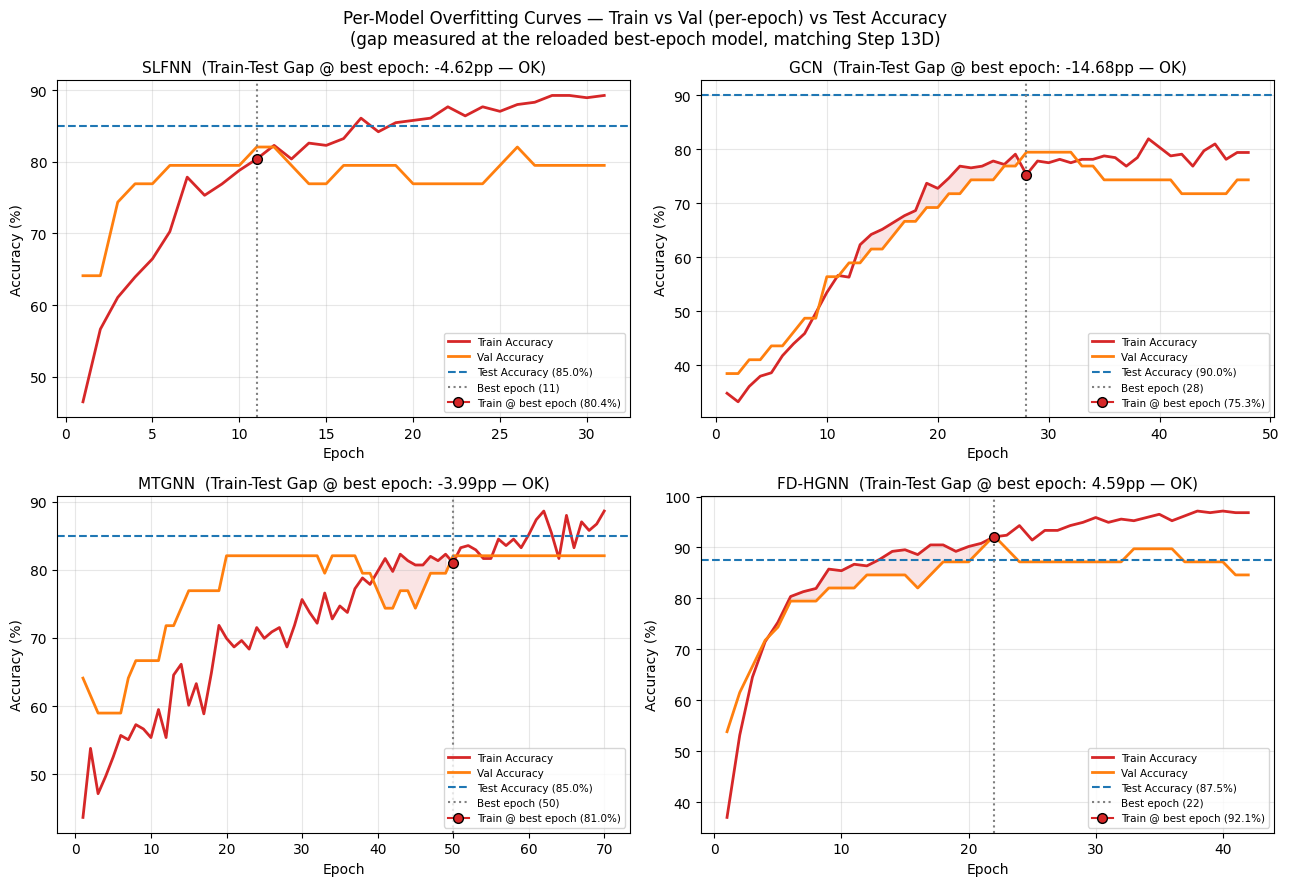

Saved figures/per_model_overfitting_curves_math.png


In [ ]:
# ============================================================
# STEP 13E (v3): Per-Model Overfitting Curves — Train vs Val vs Test
# ============================================================
print("\n" + "=" * 70)
print("STEP 13E: PER-MODEL OVERFITTING CURVES (Train + Val trend + Test line)")
print("=" * 70)

_curve_models = [
    ('SLFNN',   train_histories['SLFNN'],   best_slfnn_val_hist, best_slfnn_epoch, comparison['SLFNN']['acc'] * 100),
    ('GCN',     train_histories['GCN'],     best_gcn_val_hist,   best_gcn_epoch,   comparison['GCN']['acc'] * 100),
    ('MTGNN',   train_histories['MTGNN'],   best_mtgnn_val_hist, best_mtgnn_epoch, comparison['MTGNN']['acc'] * 100),
    ('FD-HGNN', train_histories['FD-HGNN'], best_fd_val_hist,    best_fd_epoch,    comparison['FD-HGNN']['acc'] * 100),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (name, train_hist, val_hist, best_epoch, test_acc) in zip(axes, _curve_models):
    epochs = np.arange(1, len(train_hist) + 1)
    train_curve = np.array(train_hist)
    val_curve = np.array(val_hist)

    train_acc_at_best = train_curve[best_epoch - 1]
    gap = train_acc_at_best - test_acc

    ax.plot(epochs, train_curve, color='#d62728', linewidth=2, label='Train Accuracy')
    ax.plot(epochs, val_curve, color='#ff7f0e', linewidth=2, label='Val Accuracy')
    ax.axhline(test_acc, color='#1f77b4', linestyle='--', linewidth=1.5, label=f'Test Accuracy ({test_acc:.1f}%)')
    ax.axvline(best_epoch, color='gray', linestyle=':', linewidth=1.5,
               label=f'Best epoch ({best_epoch})')
    ax.plot(best_epoch, train_acc_at_best, marker='o', color='#d62728',
             markersize=7, markeredgecolor='black', markeredgewidth=1, zorder=5,
             label=f'Train @ best epoch ({train_acc_at_best:.1f}%)')

    ax.fill_between(epochs[:best_epoch], train_curve[:best_epoch], val_curve[:best_epoch],
                     where=(train_curve[:best_epoch] > val_curve[:best_epoch]),
                     color='#d62728', alpha=0.12)

    verdict = 'Overfitting Risk' if gap > 10 else ('Mild Overfitting' if gap > 5 else 'OK')
    ax.set_title(f'{name}  (Train-Test Gap @ best epoch: {gap:.2f}pp — {verdict})', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend(fontsize=7.5, loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('Per-Model Overfitting Curves — Train vs Val (per-epoch) vs Test Accuracy\n(gap measured at the reloaded best-epoch model, matching Step 13D)', fontsize=12)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/per_model_overfitting_curves_math.png', dpi=400)
plt.show()
print("Saved figures/per_model_overfitting_curves_math.png")

## Step 14: All-Model ROC Curves & Training Accuracy Comparison

In [ ]:
# ============================================================
# STEP 14: All-Model ROC Curves & Training Accuracy Comparison
# ============================================================
print("\n" + "=" * 70)
print("STEP 14: ALL-MODEL ROC CURVES + TRAINING ACCURACY COMPARISON")
print("=" * 70)

os.makedirs('figures', exist_ok=True)

_COLORS = {
    'Proposed Adaptive-FDHGNN-APPNP+VIL': '#e6282b',
    'Proposed (FDHGNN-APPNP+VIL)':         '#e6282b',
    'SVM':     '#1f77b4',
    'LR':      '#ff7f0e',
    'SLFNN':   '#2ca02c',
    'GCN':     '#9467bd',
    'MTGNN':   '#8c564b',
    'FD-HGNN': '#17becf',
}

# ---- 14.1  All-model ROC Curves ----------------------------------------
fig, ax = plt.subplots(figsize=(7, 6))
for name, m in comparison.items():
    y_t  = m.get('y_true')
    prob = m.get('prob')
    if y_t is None or prob is None or len(np.unique(y_t)) < 2:
        continue
    fpr_, tpr_, _ = roc_curve(y_t, prob)
    auc_val = auc(fpr_, tpr_)
    short = 'Proposed (ours)' if 'Proposed' in name else name
    lw  = 2.5 if 'Proposed' in name else 1.8
    ls  = '-'  if 'Proposed' in name else '--'
    ax.plot(fpr_, tpr_, color=_COLORS.get(name), lw=lw, ls=ls,
            label=f'{short}  (AUC = {auc_val:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (Mathematics)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig('figures/all_models_roc_math.png', dpi=400)
plt.close()
print("Saved  figures/all_models_roc_math.png")

# ---- 14.2  Training Accuracy Curves (neural models only) ---------------
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Left panel: all models training accuracy ---
ax_left = axes[0]
for name, hist in train_histories.items():
    epochs = range(1, len(hist) + 1)
    lw = 2.5 if 'Proposed' in name else 1.6
    ls = '-'  if 'Proposed' in name else '--'
    ax_left.plot(epochs, hist, color=_COLORS.get(name), lw=lw, ls=ls, label=name)

ax_left.set_xlabel('Epoch', fontsize=12)
ax_left.set_ylabel('Training Accuracy (%)', fontsize=12)
ax_left.set_title('Training Accuracy — All Neural Models', fontsize=13, fontweight='bold')
ax_left.legend(fontsize=9)
ax_left.grid(alpha=0.25)
ax_left.set_ylim(25, 105)

# --- Right panel: proposed model train vs. val accuracy (best fold) ---
ax_right = axes[1]
epochs_best = range(1, len(best_history['train_acc']) + 1)

train_acc_pct = [a * 100 for a in best_history['train_acc']]
val_acc_pct   = [a * 100 for a in best_history['val_acc']]

ax_right.plot(epochs_best, train_acc_pct,
              color='#e6282b', lw=2.5, ls='-',  label='Train Accuracy')
ax_right.plot(epochs_best, val_acc_pct,
              color='#e6282b', lw=2.0, ls='--', label='Val Accuracy', alpha=0.8)

# Shade the train–val gap to make overfitting visible
ax_right.fill_between(epochs_best, val_acc_pct, train_acc_pct,
                       alpha=0.12, color='#e6282b', label='Train–Val Gap')

# Mark best val accuracy epoch
best_val_epoch = int(np.argmax(val_acc_pct)) + 1
best_val_value = max(val_acc_pct)
ax_right.axvline(x=best_val_epoch, color='gray', lw=1.2, ls=':', alpha=0.8)
ax_right.scatter([best_val_epoch], [best_val_value],
                  color='gold', edgecolors='black', s=80, zorder=5,
                  label=f'Best Val Acc ({best_val_value:.1f}% @ ep {best_val_epoch})')

# Annotate final gap
final_train = train_acc_pct[-1]
final_val   = val_acc_pct[-1]
gap = final_train - final_val
ax_right.annotate(
    f'Gap = {gap:.1f} pp',
    xy=(len(epochs_best), (final_train + final_val) / 2),
    xytext=(-60, 0), textcoords='offset points',
    fontsize=9, color='#c0392b',
    arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.0)
)

ax_right.set_xlabel('Epoch', fontsize=12)
ax_right.set_ylabel('Accuracy (%)', fontsize=12)
ax_right.set_title('Proposed Model: Train vs. Val Accuracy (Best Fold)',
                    fontsize=13, fontweight='bold')
ax_right.legend(fontsize=9, loc='lower right')
ax_right.grid(alpha=0.25)
ax_right.set_ylim(25, 105)

plt.tight_layout()
plt.savefig('figures/all_models_train_acc_math.png', dpi=400, bbox_inches='tight')
plt.close()
print("Saved  figures/all_models_train_acc_math.png")

# ---- 14.3  All-fold train vs. val summary (mean ± std band) ------------
fold_train_accs = [h['train_acc'] for h in fold_histories]
fold_val_accs   = [h['val_acc']   for h in fold_histories]

min_len = min(len(h) for h in fold_train_accs)
fold_train_arr = np.array([h[:min_len] for h in fold_train_accs]) * 100
fold_val_arr   = np.array([h[:min_len] for h in fold_val_accs])   * 100
ep_range = np.arange(1, min_len + 1)

mean_train = fold_train_arr.mean(axis=0)
std_train  = fold_train_arr.std(axis=0)
mean_val   = fold_val_arr.mean(axis=0)
std_val    = fold_val_arr.std(axis=0)

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(ep_range, mean_train, color='#e6282b', lw=2.0, ls='-',  label='Mean Train Acc')
ax.fill_between(ep_range, mean_train - std_train, mean_train + std_train,
                alpha=0.15, color='#e6282b')

ax.plot(ep_range, mean_val, color='#1f77b4', lw=2.0, ls='--', label='Mean Val Acc')
ax.fill_between(ep_range, mean_val - std_val, mean_val + std_val,
                alpha=0.15, color='#1f77b4')

# Best fold highlighted
best_fold_train = [a * 100 for a in fold_histories[best_fold]['train_acc']][:min_len]
best_fold_val   = [a * 100 for a in fold_histories[best_fold]['val_acc']][:min_len]
ax.plot(ep_range, best_fold_train, color='#e6282b', lw=1.0, ls='-',  alpha=0.4,
        label=f'Best Fold {best_fold+1} Train')
ax.plot(ep_range, best_fold_val,   color='#1f77b4', lw=1.0, ls='--', alpha=0.4,
        label=f'Best Fold {best_fold+1} Val')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Proposed Model: Mean ± Std Train & Val Accuracy (All 10 Folds)',
              fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
ax.set_ylim(25, 105)
plt.tight_layout()
plt.savefig('figures/fold_mean_train_val_acc_math.png', dpi=400, bbox_inches='tight')
plt.close()
print("Saved  figures/fold_mean_train_val_acc_math.png")

# ---- Console summary ---------------------------------------------------
final_mean_train = mean_train[-1]
final_mean_val   = mean_val[-1]
print(f"\nFinal epoch ({min_len}) summary across 10 folds:")
print(f"  Mean Train Acc : {final_mean_train:.2f}% ± {std_train[-1]:.2f}%")
print(f"  Mean Val   Acc : {final_mean_val:.2f}% ± {std_val[-1]:.2f}%")
print(f"  Mean Gap       : {final_mean_train - final_mean_val:.2f} pp")

print("\nStep 14 complete.")


STEP 14: ALL-MODEL ROC CURVES + TRAINING ACCURACY COMPARISON
Saved  figures/all_models_roc_math.png
Saved  figures/all_models_train_acc_math.png
Saved  figures/fold_mean_train_val_acc_math.png

Final epoch (25) summary across 10 folds:
  Mean Train Acc : 82.80% ± 7.40%
  Mean Val   Acc : 83.21% ± 10.90%
  Mean Gap       : -0.41 pp

Step 14 complete.



STEP 15: AUGMENTATION EFFECT — TEST SET CONFIRMATION

[15.1] Step 4B results (Validation set, default hyperparams):
 aug_size  total  pass_n  fail_n   bal_acc       f1      auc
        0    316     212     104 90.384615 0.857143 0.946746
        5    321     212     109 90.384615 0.857143 0.958580
       10    326     212     114 90.384615 0.857143 0.949704
       15    331     212     119 90.384615 0.857143 0.946746
       20    336     212     124 90.384615 0.857143 0.949704
       25    341     212     129 90.384615 0.857143 0.949704
       30    346     212     134 90.384615 0.857143 0.967456
       35    351     212     139 90.384615 0.857143 0.952663
       40    356     212     144 86.538462 0.814815 0.952663
       45    361     212     149 90.384615 0.857143 0.949704
       50    366     212     154 88.461538 0.846154 0.958580
       55    371     212     159 88.461538 0.846154 0.958580
       60    376     212     164 92.307692 0.888889 0.967456
       65    381     212     

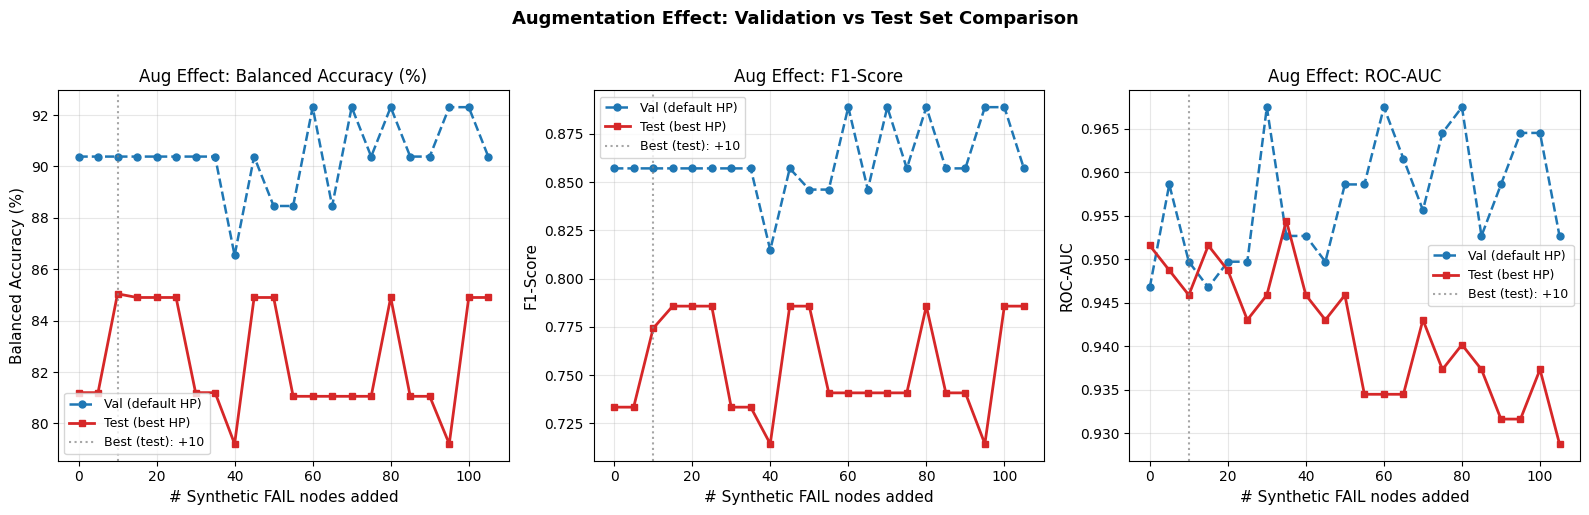


Saved figures/augmentation_val_vs_test_math.png


In [ ]:
# ============================================================
# STEP 15: Augmentation Effect — Final Test Set Confirmation
# ============================================================
print("\n" + "=" * 70)
print("STEP 15: AUGMENTATION EFFECT — TEST SET CONFIRMATION")
print("=" * 70)

# ── 15.1  Step 4B results (validation-based) পুনরায় দেখানো ──
print("\n[15.1] Step 4B results (Validation set, default hyperparams):")
_df_4b = pd.DataFrame(aug_per_step_results)
print(_df_4b[['aug_size','total','pass_n','fail_n','bal_acc','f1','auc']].to_string(index=False))

_best_4b = max(aug_per_step_results, key=lambda x: x['bal_acc'])
print(f"\n→ Best augmentation level (val): +{_best_4b['aug_size']} synthetic FAIL nodes "
      f"| BalAcc={_best_4b['bal_acc']:.2f}% | F1={_best_4b['f1']:.3f}")


# ── 15.2  Test set sweep (best_params) — paper-quality confirmation ──
print("\n[15.2] Test set augmentation sweep (best_params — for paper):")

_quick_ep_test = 10 if FAST_TEST else 60
_aug_test_results = []

_hdr = f"{'#Synth':>7} {'Total':>7} {'PASS':>6} {'FAIL':>6}  " \
       f"{'TestBalAcc%':>12} {'F1':>7} {'AUC':>7}"
print(_hdr)
print("-" * len(_hdr))

for _n in ([0] + aug_sizes):
    # ── Build augmented train at this level ──
    if _n == 0:
        _Xtr, _ytr = X_train_raw.copy(), y_train.copy()
    else:
        _Xtr, _ytr = graphmixup_augment_raw(X_train_raw, y_train, _n, alpha=0.2, seed=SEED)

    # ── Scale: fit on augmented train → apply to val AND test ──
    _sc = StandardScaler().fit(_Xtr)
    _Xtr_s = _sc.transform(_Xtr)
    _Xva_s = _sc.transform(X_val_raw)
    _Xte_s = _sc.transform(X_test_raw)

    _A_tr, _B_tr, _H_tr = split_channels(_Xtr_s)
    _A_va, _B_va, _H_va = split_channels(_Xva_s)
    _A_te, _B_te, _H_te = split_channels(_Xte_s)

    _d_tr = make_tensors(_H_tr, _A_tr, _B_tr, _ytr)
    _d_va = make_tensors(_H_va, _A_va, _B_va, y_val)
    _d_te = make_tensors(_H_te, _A_te, _B_te, y_test)

    torch.manual_seed(SEED)
    _m = FDHGNN_VIL(
        high_dim=_H_tr.shape[1],
        hid_dim=best_params['hidden_dim'],
        num_ch=len(_d_tr[1]),
        partA_dim=_A_tr.shape[1],
        partB_dim=_B_tr.shape[1],
        low_hid=32,
        dropout=best_params['dropout'],
        alpha=best_params['appnp_alpha'],
        K=best_params['appnp_k'],
        low_weight=best_params['low_weight'],
        vil_dim=16
    ).to(device)

    # ✅ val দিয়ে train (early stopping), test কে touch করা হচ্ছে না
    _m, _, _ = train_one_model(
        _m, _d_tr, _d_va,
        lr=best_params['lr'],
        weight_decay=best_params['weight_decay'],
        max_epochs=_quick_ep_test,
        patience=_quick_ep_test
    )

    _ev = eval_metrics_full(_m, _d_te[0], _d_te[1], _d_te[2], _d_te[3], _d_te[4])
    _aug_test_results.append({
        'aug_size': _n, 'total': len(_ytr),
        'pass_n': int(np.sum(_ytr == 0)), 'fail_n': int(np.sum(_ytr == 1)),
        'bal_acc': _ev['bal_acc'] * 100, 'f1': _ev['f1'], 'auc': _ev['auc']
    })
    print(f"{_n:>7} {len(_ytr):>7} {int(np.sum(_ytr==0)):>6} {int(np.sum(_ytr==1)):>6}  "
          f"{_ev['bal_acc']*100:>12.2f} {_ev['f1']:>7.3f} {_ev['auc']:>7.3f}")

_best_te = max(_aug_test_results, key=lambda x: x['bal_acc'])
print(f"\n→ Best augmentation level (test): +{_best_te['aug_size']} synthetic FAIL nodes "
      f"| BalAcc={_best_te['bal_acc']:.2f}% | F1={_best_te['f1']:.3f}")

# ── 15.3  Side-by-side plot: Val vs Test augmentation sweep ──
_df_te = pd.DataFrame(_aug_test_results)
_df_va = pd.DataFrame(aug_per_step_results)   # Step 4B results

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
_cols = [('bal_acc', 'Balanced Accuracy (%)'), ('f1', 'F1-Score'), ('auc', 'ROC-AUC')]

for ax, (col, ylabel) in zip(axes, _cols):
    ax.plot(_df_va['aug_size'], _df_va[col], 'o--', color='#1f77b4',
            linewidth=1.8, markersize=5, label='Val (default HP)')
    ax.plot(_df_te['aug_size'], _df_te[col], 's-',  color='#d62728',
            linewidth=2.0, markersize=5, label='Test (best HP)')
    ax.axvline(x=_best_te['aug_size'], color='gray', linestyle=':', alpha=0.7,
               label=f"Best (test): +{_best_te['aug_size']}")
    ax.set_xlabel('# Synthetic FAIL nodes added', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Aug Effect: {ylabel}', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('Augmentation Effect: Validation vs Test Set Comparison',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figures/augmentation_val_vs_test_math.png', dpi=400, bbox_inches='tight')
plt.show()
print("\nSaved figures/augmentation_val_vs_test_math.png")

In [ ]:
# ============================================================
# Augmentation Level Selection — Data Prep
# ============================================================
import numpy as np

_df_va = pd.DataFrame(aug_per_step_results)  # Step 4B val results

# Val-based best augmentation level
_best_idx = int(np.argmax(_df_va['bal_acc'].values))
_best_aug = _df_va['aug_size'].values[_best_idx]

# ── Test set: শুধু selected level এ ONCE evaluate ──
_Xtr_best, _ytr_best = graphmixup_augment_raw(
    X_train_raw, y_train, _best_aug, alpha=0.2, seed=SEED)
_sc_best = StandardScaler().fit(_Xtr_best)
_A_b, _B_b, _H_b = split_channels(_sc_best.transform(_Xtr_best))
_A_v, _B_v, _H_v = split_channels(_sc_best.transform(X_val_raw))
_A_t, _B_t, _H_t = split_channels(_sc_best.transform(X_test_raw))

_d_tr_b  = make_tensors(_H_b, _A_b, _B_b, _ytr_best)
_d_va_b  = make_tensors(_H_v, _A_v, _B_v, y_val)
_d_te_b  = make_tensors(_H_t, _A_t, _B_t, y_test)

torch.manual_seed(SEED)
_m_best = FDHGNN_VIL(
    high_dim=_H_b.shape[1], hid_dim=best_params['hidden_dim'],
    num_ch=len(_d_tr_b[1]), partA_dim=_A_b.shape[1],
    partB_dim=_B_b.shape[1], low_hid=32,
    dropout=best_params['dropout'], alpha=best_params['appnp_alpha'],
    K=best_params['appnp_k'], low_weight=best_params['low_weight'],
    vil_dim=16
).to(device)
_m_best, _, _ = train_one_model(
    _m_best, _d_tr_b, _d_va_b,
    lr=best_params['lr'], weight_decay=best_params['weight_decay'],
    max_epochs=100, patience=20
)
_ev_best = eval_metrics_full(
    _m_best, _d_te_b[0], _d_te_b[1], _d_te_b[2], _d_te_b[3], _d_te_b[4])

# ── Test at baseline (no augmentation) — comparison এর জন্য ──
_Xtr_base = X_train_raw.copy()
_sc_base  = StandardScaler().fit(_Xtr_base)
_A_0,_B_0,_H_0 = split_channels(_sc_base.transform(_Xtr_base))
_A_v0,_B_v0,_H_v0 = split_channels(_sc_base.transform(X_val_raw))
_A_t0,_B_t0,_H_t0 = split_channels(_sc_base.transform(X_test_raw))
_d_tr0 = make_tensors(_H_0,_A_0,_B_0,y_train)
_d_va0 = make_tensors(_H_v0,_A_v0,_B_v0,y_val)
_d_te0 = make_tensors(_H_t0,_A_t0,_B_t0,y_test)
torch.manual_seed(SEED)
_m0 = FDHGNN_VIL(
    high_dim=_H_0.shape[1], hid_dim=best_params['hidden_dim'],
    num_ch=len(_d_tr0[1]), partA_dim=_A_0.shape[1],
    partB_dim=_B_0.shape[1], low_hid=32,
    dropout=best_params['dropout'], alpha=best_params['appnp_alpha'],
    K=best_params['appnp_k'], low_weight=best_params['low_weight'],
    vil_dim=16
).to(device)
_m0, _, _ = train_one_model(_m0, _d_tr0, _d_va0,
    lr=best_params['lr'], weight_decay=best_params['weight_decay'],
    max_epochs=100, patience=20)
_ev0 = eval_metrics_full(
    _m0, _d_te0[0], _d_te0[1], _d_te0[2], _d_te0[3], _d_te0[4])

print(f"_best_aug (validation-selected) = +{_best_aug}")
print(f"_ev0['bal_acc']    (no aug, test)    = {_ev0['bal_acc']*100:.2f}%")
print(f"_ev_best['bal_acc'] (+{_best_aug}, test) = {_ev_best['bal_acc']*100:.2f}%")

_best_aug (validation-selected) = +60
_ev0['bal_acc']    (no aug, test)    = 81.20%
_ev_best['bal_acc'] (+60, test) = 81.05%


In [ ]:
def smooth(y, w=5):
    """Simple centered moving-average smoother (edge-safe)."""
    y = np.asarray(y, dtype=float)
    n = len(y)
    if n == 0 or w <= 1:
        return y.copy()
    half = w // 2
    out = np.empty(n)
    for i in range(n):
        lo, hi = max(0, i - half), min(n, i + half + 1)
        out[i] = y[lo:hi].mean()
    return out

Auto-computed metrics_cfg ranges:
  acc      (Accuracy (%)): 78.000 - 93.453
  f1       (F1-Score): 0.683 - 0.928
  auc      (ROC-AUC): 0.904 - 0.993
_df_va['acc'] range: 87.1795 – 92.3077
_ev0['acc']   = 0.8
_ev_best['acc'] = 0.825


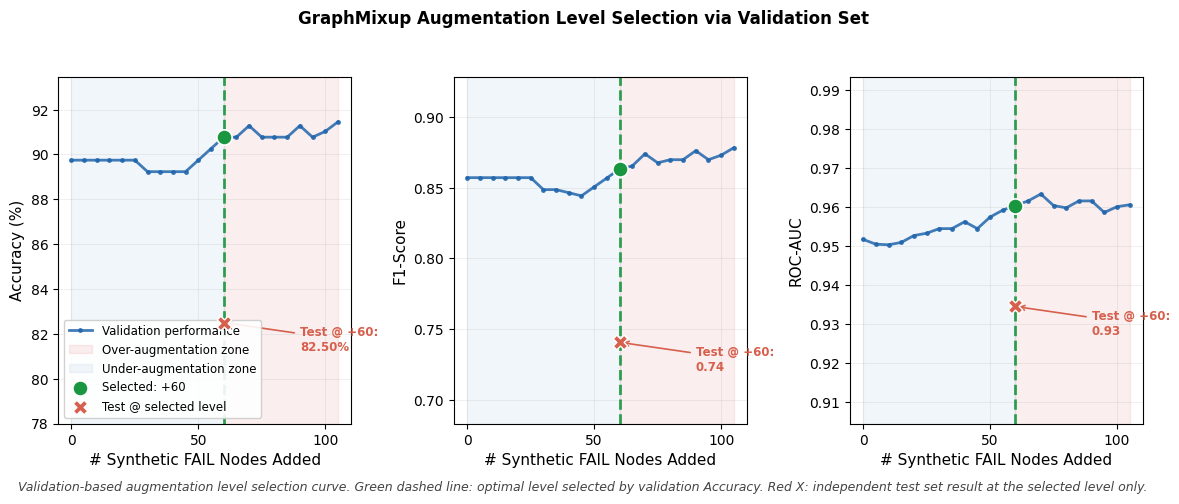

In [ ]:
# ── Auto-compute axis ranges from the data itself (no manual numbers) ──

import matplotlib.ticker as mticker

def _auto_range(col, pad_acc=2.0, pad_f1=0.05, pad_auc=0.03):

    raw_va = smooth(_df_va[col].values, w=5)
    raw_ev = np.array([_ev0[col], _ev_best[col]], dtype=float)

    if col == 'acc':
        # Auto-detect: if values are in 0-1 form, multiply by 100
        va_vals = raw_va * 100 if raw_va.max() <= 1.0 else raw_va.copy()
        ev_vals = raw_ev * 100 if raw_ev.max() <= 1.0 else raw_ev.copy()
        # Safety clip — accuracy must be 0-100
        va_vals = np.clip(va_vals, 0.0, 100.0)
        ev_vals = np.clip(ev_vals, 0.0, 100.0)
    else:
        va_vals = raw_va.copy()
        ev_vals = raw_ev.copy()

    all_vals = np.concatenate([va_vals, ev_vals])
    vmin, vmax = float(all_vals.min()), float(all_vals.max())

    if col == 'acc':
        lo, hi = vmin - pad_acc, vmax + pad_acc
    elif col == 'f1':
        lo, hi = max(0.0, vmin - pad_f1), min(1.0, vmax + pad_f1)
    else:
        lo, hi = max(0.0, vmin - pad_auc), min(1.0, vmax + pad_auc)

    return (lo, hi)

metrics_cfg = [
    ('acc', 'Accuracy (%)',   _auto_range('acc')),
    ('f1',  'F1-Score',       _auto_range('f1')),
    ('auc', 'ROC-AUC',        _auto_range('auc')),
]

print("Auto-computed metrics_cfg ranges:")
for col, lab, rng in metrics_cfg:
    print(f"  {col:8s} ({lab}): {rng[0]:.3f} - {rng[1]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
fig.subplots_adjust(wspace=0.35)

for ax, (col, ylabel, ylim) in zip(axes, metrics_cfg):
    x    = _df_va['aug_size'].values
    y_va = smooth(_df_va[col].values, w=5)
    scale = 100 if col == 'acc' else 1

    # Validation curve
    ax.plot(x, y_va, color='#2166ac', lw=2.0,
            marker='o', markersize=2.5, alpha=0.85,
            label='Validation performance')

    # Shade: rejected region (over-augmentation)
    ax.axvspan(_best_aug, x.max(),
               alpha=0.08, color='#d62728',
               label='Over-augmentation zone')

    # Shade: under-augmentation region
    ax.axvspan(0, _best_aug,
               alpha=0.06, color='#2166ac',
               label='Under-augmentation zone')

    # Best val line
    ax.axvline(x=_best_aug, color='#1a9641',
               lw=2.0, ls='--', alpha=0.9)
    ax.scatter([_best_aug],
               [y_va[_best_idx]],
               color='#1a9641', s=120, zorder=7,
               edgecolors='white', linewidths=1.2,
               label=f'Selected: +{_best_aug}')

    # Test result — actual value plotted as its own marker (not the val dot)
    if col == 'acc':
        t_val = _ev_best[col] * 100 if _ev_best[col] <= 1.0 else _ev_best[col]
    else:
        t_val = _ev_best[col]

    ax.scatter([_best_aug], [t_val],
               marker='X', color='#d6604d', s=110, zorder=8,
               edgecolors='white', linewidths=1.0,
               label='Test @ selected level' if col == 'acc' else None)

    ax.annotate(
        f'Test @ +{_best_aug}:\n{t_val:.2f}{"%" if col=="acc" else ""}',
        xy=(_best_aug, t_val),
        xytext=(_best_aug + 30, t_val - (ylim[1]-ylim[0])*0.08),
        fontsize=8.5, color='#d6604d', fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='#d6604d', lw=1.2)
    )

    ax.set_xlabel('# Synthetic FAIL Nodes Added', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_ylim(ylim)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(50))
    ax.grid(alpha=0.2, lw=0.7)
    if col == 'acc':
        ax.legend(fontsize=8.5, framealpha=0.9, loc='lower left')


print(f"_df_va['acc'] range: {_df_va['acc'].min():.4f} – {_df_va['acc'].max():.4f}")
print(f"_ev0['acc']   = {_ev0['acc']}")
print(f"_ev_best['acc'] = {_ev_best['acc']}")

fig.text(0.5, -0.04,
    'Validation-based augmentation level selection curve. '
    'Green dashed line: optimal level selected by validation Accuracy. '
    'Red X: independent test set result at the selected level only.',
    ha='center', fontsize=9, color='#444', style='italic')

plt.suptitle(
    'GraphMixup Augmentation Level Selection via Validation Set',
    fontsize=12, fontweight='bold', y=1.03)

plt.savefig('figures/aug_effect_simple_math.png', dpi=400, bbox_inches='tight')
plt.show()

## Computational Cost

In [ ]:
# ============================================================
# STEP 12.8: Computational Cost Analysis — Averaged over 10 CV Folds
# With vs Without Dynamic Channel Pruning (DCP)
# ============================================================
import time, copy, itertools

print("\n" + "=" * 70)
print("COMPUTATIONAL COST ANALYSIS — AVERAGED OVER CV FOLDS (With vs Without DCP)")
print("=" * 70)

h, low_hid, v, K = best_params['hidden_dim'], 32, 16, best_params['appnp_k']


def model_size_mb(model, active_only=False):
    mask = model.framelet.channel_mask
    total = 0
    for c, lin in enumerate(model.framelet.linears):
        if active_only and mask[c] < 0.5:
            continue
        total += sum(p.numel() for p in lin.parameters())
    other = sum(p.numel() for n, p in model.named_parameters() if 'framelet.linears' not in n)
    total += other
    return total * 4 / (1024 ** 2)


def estimate_macs(n_active, N, d_H, d_A, d_B, h, v, K, low_hid):
    macs = 0
    macs += n_active * (N * d_H * h)
    macs += n_active * (N * N * h)
    macs += n_active * (N * (h * (h // 2) + (h // 2) * 1))
    macs += n_active * (N * h)
    macs += N * h * 2
    macs += K * (N * N * 2)
    macs += N * (d_A * low_hid + low_hid * 2)
    macs += N * (d_B * low_hid + low_hid * 2)
    macs += N * (2 * v + h * v + (2 * v * v + v * v) + v * 2)
    return macs


def avg_inference_time(model, H_in, ops_in, A_in, B_in, n_repeats=30, n_warmup=5):
    model.eval()
    with torch.no_grad():
        for _ in range(n_warmup):
            _ = model(H_in, ops_in, A_in, B_in)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t0 = time.perf_counter()
        for _ in range(n_repeats):
            _ = model(H_in, ops_in, A_in, B_in)
        if device.type == 'cuda':
            torch.cuda.synchronize()
        t1 = time.perf_counter()
    return (t1 - t0) / n_repeats


# ── একই 10-fold split পুনর্গঠন (deterministic, same SEED) ──
skf_cost = StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED)
splits = list(skf_cost.split(X_H_train, y_train_aug))

per_fold_rows, state_ptr = [], 0
for fold, (cv_train_idx, cv_val_idx) in enumerate(splits):
    if len(np.unique(y_train_aug[cv_train_idx])) < 2 or len(np.unique(y_train_aug[cv_val_idx])) < 2:
        continue  # Step 7-এর skip-logic এর সাথে মিলিয়ে রাখা

    data_val = make_tensors(X_H_train[cv_val_idx], X_A_train[cv_val_idx],
                             X_B_train[cv_val_idx], y_train_aug[cv_val_idx])
    H_in, ops_in, A_in, B_in, y_in = data_val

    if len(ops_in) != n_ch_full:
        print(f"  [Fold {fold+1}] ops channel count mismatch: got {len(ops_in)}, "
              f"model expects {n_ch_full}. Rebuilding ops with matching num_hp...")
        adj_val = build_knn_hypergraph(H_in.cpu().numpy(), k=15)
        ops_in = to_ops_tensor(build_framelet_ops(adj_val, n_ch_full - 1))

    N_nodes = H_in.shape[0]
    d_H, d_A, d_B = H_in.shape[1], A_in.shape[1], B_in.shape[1]

    model_i = FDHGNN_VIL(
        high_dim=d_H, hid_dim=h, num_ch=n_ch_full,
        partA_dim=d_A, partB_dim=d_B, low_hid=low_hid,
        dropout=best_params['dropout'], alpha=best_params['appnp_alpha'],
        K=K, low_weight=best_params['low_weight'], vil_dim=v).to(device)
    model_i.load_state_dict({k_: v_.to(device) for k_, v_ in fold_states[state_ptr].items()})
    state_ptr += 1
    model_i.eval()

    # forced all-channels-active copy -> আসল forward pass cost "Without DCP"
    model_i_full = copy.deepcopy(model_i)
    with torch.no_grad():
        model_i_full.framelet.channel_mask.fill_(1.0)
    model_i_full.eval()

    n_active = int(model_i.framelet.channel_mask.sum().item())
    n_total = len(model_i.framelet.linears)

    size_w = model_size_mb(model_i, active_only=True)
    size_wo = model_size_mb(model_i, active_only=False)

    macs_w = estimate_macs(n_active, N_nodes, d_H, d_A, d_B, h, v, K, low_hid) / 1e6
    macs_wo = estimate_macs(n_total, N_nodes, d_H, d_A, d_B, h, v, K, low_hid) / 1e6
    flops_w, flops_wo = macs_w * 2, macs_wo * 2

    time_w = avg_inference_time(model_i, H_in, ops_in, A_in, B_in)
    time_wo = avg_inference_time(model_i_full, H_in, ops_in, A_in, B_in)

    per_fold_rows.append({
        'fold': fold + 1, 'N_nodes': N_nodes, 'd_H': d_H,
        'active_with': n_active, 'active_without': n_total,
        'size_with': size_w, 'size_without': size_wo,
        'macs_with': macs_w, 'macs_without': macs_wo,
        'flops_with': flops_w, 'flops_without': flops_wo,
        'time_with': time_w, 'time_without': time_wo,
    })

cost_df = pd.DataFrame(per_fold_rows)
print(f"\nPer-fold cost (n={len(cost_df)} folds):")
print(cost_df.to_string(index=False))

# ── Summary table (mean across folds) ──
try:
    n_configs = len(list(itertools.product(*param_grid.values())))
except NameError:
    n_configs = None

def _savings(w, wo):
    return (wo - w) / wo * 100 if wo > 0 else 0.0

rows = ['Model Size (MB)', 'MACs (Millions)', 'FLOPs (Millions)',
        'Inference Time (sec)', 'Active Framelet Channels',
        'Inference Batch Size (N nodes)', 'Feature Dimension (d)',
        'Cross-Validation Folds', 'Number of configurations']

with_col = [cost_df['size_with'].mean(), cost_df['macs_with'].mean(), cost_df['flops_with'].mean(),
            cost_df['time_with'].mean(), cost_df['active_with'].mean(),
            cost_df['N_nodes'].mean(), cost_df['d_H'].mean(), N_FOLDS, n_configs]
without_col = [cost_df['size_without'].mean(), cost_df['macs_without'].mean(), cost_df['flops_without'].mean(),
               cost_df['time_without'].mean(), cost_df['active_without'].mean(),
               cost_df['N_nodes'].mean(), cost_df['d_H'].mean(), N_FOLDS, n_configs]
savings_col = [_savings(with_col[i], without_col[i]) if i < 5 else '—' for i in range(len(rows))]

summary_table = pd.DataFrame({
    'Parameter': rows,
    'With DCP (avg)': with_col,
    'Without DCP (avg)': without_col,
    'Savings (%)': savings_col,
})

os.makedirs('figures', exist_ok=True)
print("\nComputational Cost — Averaged over CV Folds (With vs Without DCP):")
print(summary_table.to_string(index=False))
summary_table.to_csv('figures/computational_cost_avg_with_vs_without_dcp_math.csv', index=False)
cost_df.to_csv('figures/computational_cost_per_fold_math.csv', index=False)
print("\nSaved figures/computational_cost_avg_with_vs_without_dcp_math.csv")
print("Saved figures/computational_cost_per_fold_math.csv")


COMPUTATIONAL COST ANALYSIS — AVERAGED OVER CV FOLDS (With vs Without DCP)
  [Fold 1] ops channel count mismatch: got 4, model expects 7. Rebuilding ops with matching num_hp...
  [Fold 2] ops channel count mismatch: got 4, model expects 7. Rebuilding ops with matching num_hp...
  [Fold 3] ops channel count mismatch: got 4, model expects 7. Rebuilding ops with matching num_hp...
  [Fold 4] ops channel count mismatch: got 4, model expects 7. Rebuilding ops with matching num_hp...
  [Fold 5] ops channel count mismatch: got 4, model expects 7. Rebuilding ops with matching num_hp...
  [Fold 6] ops channel count mismatch: got 4, model expects 7. Rebuilding ops with matching num_hp...
  [Fold 7] ops channel count mismatch: got 4, model expects 7. Rebuilding ops with matching num_hp...
  [Fold 8] ops channel count mismatch: got 4, model expects 7. Rebuilding ops with matching num_hp...
  [Fold 9] ops channel count mismatch: got 4, model expects 7. Rebuilding ops with matching num_hp...
  [Fol

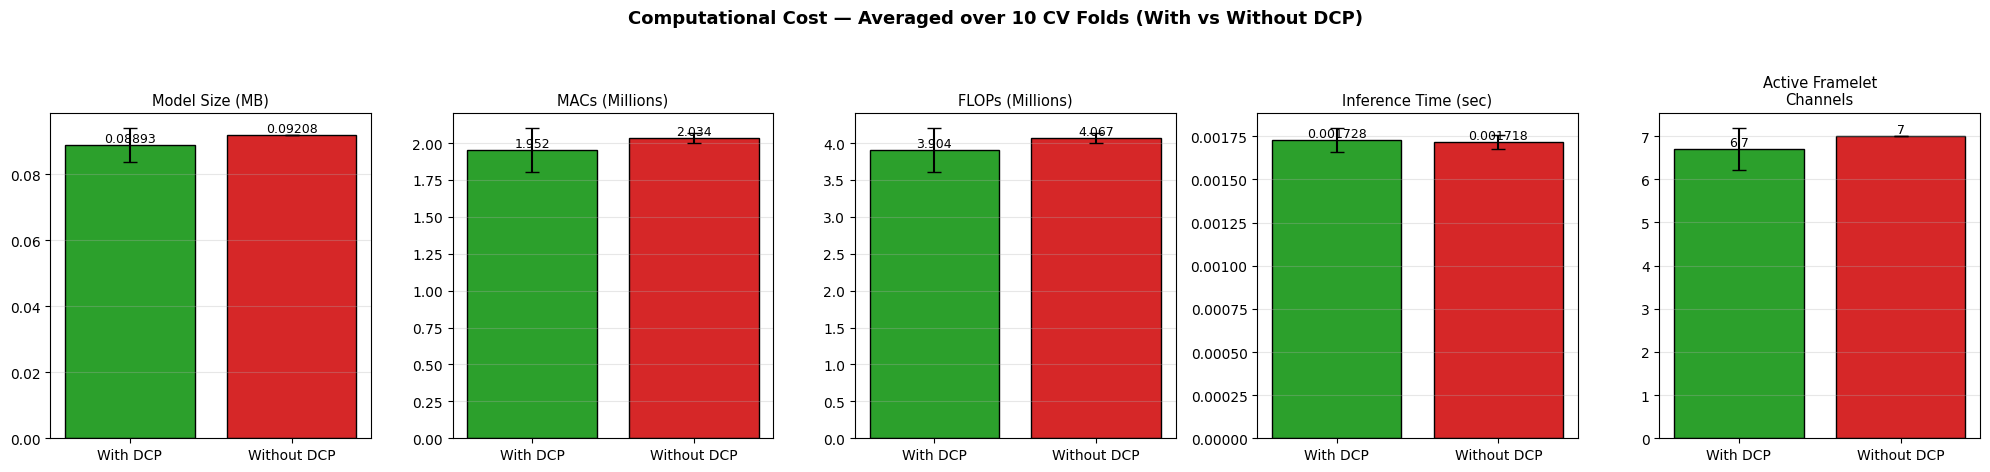

Saved figures/cost_avg_with_vs_without_dcp_math.png


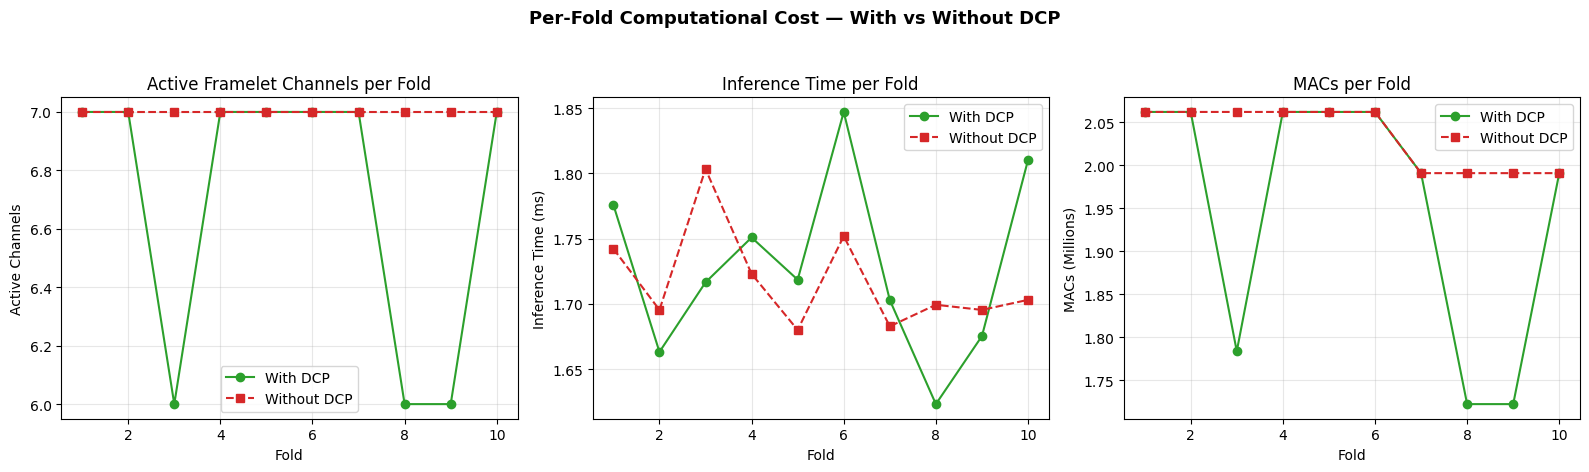

Saved figures/cost_per_fold_trend_math.png

Average savings from Dynamic Channel Pruning (With DCP vs Without):
  Model Size (MB)           : +3.42% saved
  MACs (Millions)           : +4.01% saved
  FLOPs (Millions)          : +4.01% saved
  Inference Time (sec)      : -0.62% saved
  Active Framelet Channels  : +4.29% saved


In [ ]:
# ============================================================
# STEP 12.9: Computational Cost Visualization (With vs Without DCP)
# ============================================================

_cost_metrics = [
    ('Model Size (MB)', 'size_with', 'size_without'),
    ('MACs (Millions)', 'macs_with', 'macs_without'),
    ('FLOPs (Millions)', 'flops_with', 'flops_without'),
    ('Inference Time (sec)', 'time_with', 'time_without'),
    ('Active Framelet\nChannels', 'active_with', 'active_without'),
]

# ---- Averaged bar comparison (mean ± std across folds) ----
fig, axes = plt.subplots(1, len(_cost_metrics), figsize=(4 * len(_cost_metrics), 4.5))
for ax, (label, col_w, col_wo) in zip(axes, _cost_metrics):
    mean_w, std_w = cost_df[col_w].mean(), cost_df[col_w].std()
    mean_wo, std_wo = cost_df[col_wo].mean(), cost_df[col_wo].std()
    bars = ax.bar(['With DCP', 'Without DCP'], [mean_w, mean_wo],
                   yerr=[std_w, std_wo], capsize=5,
                   color=['#2ca02c', '#d62728'], edgecolor='black')
    for b, val in zip(bars, [mean_w, mean_wo]):
        ax.text(b.get_x() + b.get_width() / 2, val, f'{val:.4g}',
                 ha='center', va='bottom', fontsize=9)
    ax.set_title(label, fontsize=10.5)
    ax.grid(alpha=0.3, axis='y')

plt.suptitle('Computational Cost — Averaged over 10 CV Folds (With vs Without DCP)',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('figures/cost_avg_with_vs_without_dcp_math.png', dpi=400, bbox_inches='tight')
plt.show()
print("Saved figures/cost_avg_with_vs_without_dcp_math.png")

# ---- Per-fold trend (DCP consistency across folds) ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ax = axes[0]
ax.plot(cost_df['fold'], cost_df['active_with'], marker='o', color='#2ca02c', label='With DCP')
ax.plot(cost_df['fold'], cost_df['active_without'], marker='s', ls='--', color='#d62728', label='Without DCP')
ax.set_xlabel('Fold'); ax.set_ylabel('Active Channels')
ax.set_title('Active Framelet Channels per Fold'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(cost_df['fold'], cost_df['time_with'] * 1000, marker='o', color='#2ca02c', label='With DCP')
ax.plot(cost_df['fold'], cost_df['time_without'] * 1000, marker='s', ls='--', color='#d62728', label='Without DCP')
ax.set_xlabel('Fold'); ax.set_ylabel('Inference Time (ms)')
ax.set_title('Inference Time per Fold'); ax.legend(); ax.grid(alpha=0.3)

ax = axes[2]
ax.plot(cost_df['fold'], cost_df['macs_with'], marker='o', color='#2ca02c', label='With DCP')
ax.plot(cost_df['fold'], cost_df['macs_without'], marker='s', ls='--', color='#d62728', label='Without DCP')
ax.set_xlabel('Fold'); ax.set_ylabel('MACs (Millions)')
ax.set_title('MACs per Fold'); ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Per-Fold Computational Cost — With vs Without DCP', fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('figures/cost_per_fold_trend_math.png', dpi=400, bbox_inches='tight')
plt.show()
print("Saved figures/cost_per_fold_trend_math.png")

# ---- Savings summary ----
print("\nAverage savings from Dynamic Channel Pruning (With DCP vs Without):")
for label, col_w, col_wo in _cost_metrics:
    w, wo = cost_df[col_w].mean(), cost_df[col_wo].mean()
    pct = (wo - w) / wo * 100 if wo > 0 else 0.0
    print(f"  {label.replace(chr(10), ' '):26s}: {pct:+.2f}% saved")

In [ ]:
# ============================================================
# Embedding Extraction — Raw 2-D Logit Space (Mathematics dataset)
# ============================================================
print("\n" + "=" * 70)
print("EMBEDDING EXTRACTION — Raw Logit Space (Mathematics dataset, held-out Test set)")
print("=" * 70)

data_test_emb = make_tensors(X_H_test, X_A_test, X_B_test, y_test)
XH_te, ops_te, XA_te, XB_te, y_te_t = data_test_emb

# ── channel-count mismatch guard (একই defensive fix আগের মতো) ──
_n_ch_model = final_model.framelet.num_channels
if len(ops_te) != _n_ch_model:
    print(f"  ops channel count mismatch: got {len(ops_te)}, "
          f"final_model expects {_n_ch_model}. Rebuilding ops with matching channel count...")
    _adj_te = build_knn_hypergraph(XH_te.cpu().numpy(), k=15)
    ops_te = to_ops_tensor(build_framelet_ops(_adj_te, _n_ch_model - 1))

final_model.eval()
with torch.no_grad():
    h_te, _ = final_model.framelet(XH_te, ops_te)
    Z0 = final_model.out_high(h_te)
    A_hat_te = ops_te[0]

    Z_no_appnp = appnp_propagate(Z0, A_hat_te, alpha=0.0, K=final_model.K)
    Z_with_appnp = appnp_propagate(Z0, A_hat_te, alpha=final_model.alpha, K=final_model.K)

Z_no_appnp_np = Z_no_appnp.cpu().numpy()
Z_with_appnp_np = Z_with_appnp.cpu().numpy()
y_true_np = y_te_t.cpu().numpy()

print(f"Test set size: {len(y_true_np)}")
print(f"APPNP alpha (trained): {final_model.alpha:.2f}, K={final_model.K}")


EMBEDDING EXTRACTION — Raw Logit Space (Mathematics dataset, held-out Test set)
  ops channel count mismatch: got 4, final_model expects 7. Rebuilding ops with matching channel count...
Test set size: 40
APPNP alpha (trained): 0.10, K=5



EMBEDDING VISUALIZATION — Raw Logit Space (independent axis scale)
w/o APPNP (α=0)  : x-range=0.000007, y-range=0.000018, std=(0.000002, 0.000005)
with APPNP (α>0)  : x-range=0.038795, y-range=0.022364, std=(0.009549, 0.004642)

Collapse ratio (x): 5586.9x larger spread with APPNP
Collapse ratio (y): 1255.9x larger spread with APPNP


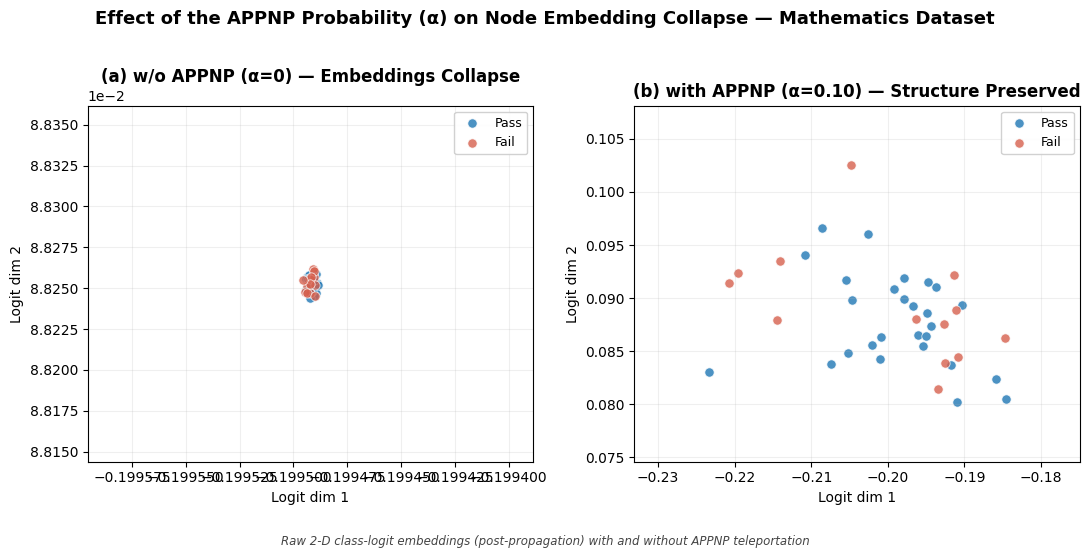

Saved figures/embedding_raw_math.png


In [ ]:
# ============================================================
# Embedding Visualization — Raw 2-D Logit Scatter (Math dataset)
# ============================================================
print("\n" + "=" * 70)
print("EMBEDDING VISUALIZATION — Raw Logit Space (independent axis scale)")
print("=" * 70)

def _spread_report(Z, name):
    rng_x = Z[:, 0].max() - Z[:, 0].min()
    rng_y = Z[:, 1].max() - Z[:, 1].min()
    print(f"{name}: x-range={rng_x:.6f}, y-range={rng_y:.6f}, "
          f"std=({Z[:,0].std():.6f}, {Z[:,1].std():.6f})")
    return rng_x, rng_y

rng_x_no, rng_y_no = _spread_report(Z_no_appnp_np, "w/o APPNP (α=0)  ")
rng_x_wi, rng_y_wi = _spread_report(Z_with_appnp_np, "with APPNP (α>0)  ")
print(f"\nCollapse ratio (x): {rng_x_wi / max(rng_x_no, 1e-12):.1f}x larger spread with APPNP")
print(f"Collapse ratio (y): {rng_y_wi / max(rng_y_no, 1e-12):.1f}x larger spread with APPNP")

COLOR_PASS, COLOR_FAIL = '#1f77b4', '#d6604d'

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, Z, title in zip(
        axes,
        [Z_no_appnp_np, Z_with_appnp_np],
        [f'(a) w/o APPNP (α=0) — Embeddings Collapse', f'(b) with APPNP (α={final_model.alpha:.2f}) — Structure Preserved']):
    for cls, color, label in [(0, COLOR_PASS, 'Pass'), (1, COLOR_FAIL, 'Fail')]:
        mask = y_true_np == cls
        ax.scatter(Z[mask, 0], Z[mask, 1], c=color, label=label,
                   s=45, alpha=0.8, edgecolors='white', linewidths=0.6)

    # ── Independent, relative (data-driven) padding per panel ──
    x_min, x_max = Z[:, 0].min(), Z[:, 0].max()
    y_min, y_max = Z[:, 1].min(), Z[:, 1].max()
    x_span = max(x_max - x_min, 1e-6)
    y_span = max(y_max - y_min, 1e-6)
    pad_x = max(x_span * 0.25, 1e-4)
    pad_y = max(y_span * 0.25, 1e-4)
    ax.set_xlim(x_min - pad_x, x_max + pad_x)
    ax.set_ylim(y_min - pad_y, y_max + pad_y)

    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Logit dim 1', fontsize=10)
    ax.set_ylabel('Logit dim 2', fontsize=10)
    ax.ticklabel_format(style='sci', axis='both', scilimits=(-2, 2))
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9, framealpha=0.9)

fig.text(0.5, -0.05,
    'Raw 2-D class-logit embeddings (post-propagation) with and without APPNP teleportation',
    ha='center', fontsize=8.5, color='#444', style='italic', wrap=True)

plt.suptitle('Effect of the APPNP Probability (α) on Node Embedding Collapse — Mathematics Dataset',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

os.makedirs('figures', exist_ok=True)
plt.savefig('figures/embedding_raw_math.png', dpi=400, bbox_inches='tight')
plt.show()
print("Saved figures/embedding_raw_math.png")